In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source
> `src/pipelines/02_fnd_eda_notebooks/06_ampds2_eda.py`.
> Edit the source and re-export; do not edit the exported notebook by hand.

# 06 - AMPds2: one house, two years, a perfect minute grid

    **What this notebook is.** An exploratory walk through the Almanac of Minutely Power dataset v2 (AMPds2) as staged in our fnd layer: one detached house in Burnaby, British Columbia, metered at every circuit for exactly two years (2012-04-01 to 2014-03-31) on a perfect one-minute grid - plus its gas, water and weather records.

    **Who this is for.** Someone who has not seen this dataset before and needs a working mental model of it: what was collected, how it behaves, what is trustworthy, and what it teaches us for our own NILM stack.

    **Conventions used throughout:**

    - **[collectable]** marks a finding or practice we could reproduce in our own Shelly-based deployment.

    - **[insight only]** marks context that shapes the problem but is not something we can collect.

    - Every number printed in prose is computed by the notebook (no hand-typed statistics); every figure is rendered and visually inspected.

    **Why this dataset matters to us.** AMPds2 is the anti-REFIT: where REFIT showed every way a fleet of deployed loggers can fail (gaps, plateaus, skew, 32-68% coverage), AMPds2 is a self-contained installation done right - one house, every circuit, no missing rows, no frozen meters. It is the closest proxy for a *degraded-cadence* version of our own deployment (60 s polling instead of 1 s), and the only release in our suite that records per-circuit voltage and current on a North American split-phase panel - REDD has the topology, but at 1 s with mains-only channels.

> How to read: every section below poses a question, answers it from the raw files, then interprets the answer. Read top-to-bottom without executing anything - charts are rendered, and no number is hard-coded.

In [ ]:
import sys, os
import numpy as np
import pandas as pd
import eda_fnd_lib as eda
eda.apply_style()
print("python:", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__)
print("repo:", eda.ROOT)

python: 3.13.7 | pandas 3.0.6 | numpy 2.5.3
repo: /root/longvdh/agent_space/projects/watt-wiser


## TL;DR

- **One house, 21 meters + 2 computed columns, 2 years, 1,051,200 one-minute rows - and the grid is perfect**: a single 60.0 s timestep, zero nulls, zero lost minutes. The only irregularities are 6 all-zero minutes - one at the register wipe, five inside the register meltdown (Q4, Q7): the logger wrote zeros exactly when its registers corrupted.

- **Coverage is closed by construction.** The labelled circuits tile the whole-house meter exactly - but the release *defines the remainder as a published column* (Unmetered, UNE - Q6), so a tiling check here cannot fail. A named residual is not submeter coverage; UK-DALE's 86-97% and REFIT's ~36% measure unexplained shares of a measured aggregate - a different object.

- **P is bookkeeping, not sampling.** Each P value is the *average* power over its minute (verified against the meter's own register: corr 0.96). Energy is exact; timing is quantized to 60 s. Nearly half of all ON-episodes are 3 min or shorter but carry only 3.6% of the energy - the cadence costs timing, not energy.

- **The register trap, quantified.** The cumulative meters (Pt/Qt/St) glitch: a one-minute register wipe and a 39-minute meltdown with single-sample jumps of up to 12.9 MWh. Naively summing positive register diffs yields 3.1x the true energy. Derive energy from P; treat registers as decoration.

- **The residual is 17.9% of all electricity - and it is the finding.** UNE is the release's computed Unmetered remainder (21 meters published; the 2 extra wide-file columns are arithmetic - UNE violates S >= P, physics no meter can break, on 99.3% of minutes). What lives in it: an always-on base plus ~7 bursts/day of 1.5-5.3 kW, co-firing with hot-water flow and the gas heater 1.4-1.5x after an hour-matched control (2.2x raw) - water heating. Meanwhile the circuit *labelled* "Instant Hot Water Unit" never exceeds 74 W. In our own deployment, this remainder is the live UNKNOWN class.

- **Signatures survive 60 s.** Fridge sawtooth (39 cycles/day, duty 36.6%), washer programmes, dryer mega-blocks, heat-pump runs, evening TV - every canonical shape stays recognisable at one-minute resolution.

- **Two households, one service.** The rental suite (RSE) is 22.5% of the energy with its own daily rhythm (peak 18:00 vs the main house 22:00). A "whole-home" meter may be metering more than one home.

- **The paper trail audits the meter - and shows its own limits.** The utility bills re-derive the WHE integral: 12 of 14 invoices within 2% (median +0.7%), arithmetic closing to the cent. But the derived tables are the weakest layer: 8 unfilled months in Electricity_Monthly, one month -7.6% off the meter, billing anchors that are invoice dates (ms, one duplicated pair), and Water_Billing's anchor reduced to ts_us = 2. The kept text columns are what make the audit possible at all (Q11).

## Q1 - What was collected, and in what shape?

AMPds2 was published by Simon Fraser University (Burnaby, BC, Canada) as a NILM benchmark: a single residential building instrumented at the circuit level, cross-checked against the utility bills (the release even ships the bills and the appliance manuals).

Our fnd layer stages 38 parquet files:

- **21 per-circuit electricity files** - one circuit each, with the full electrical record: average power P (W), current I, voltage V, frequency f, displacement/true power factor DPF/APF, reactive power Q, and cumulative energy registers Pt/Qt/St.

- **4 wide electricity files** (P, Q, S, I) - all circuits on one timestamp grid, as published. These carry two extra columns that have **no per-circuit file anywhere in the release**: MHE and UNE. The release's own record states **21 power meters** - matching the 21 per-circuit CSVs and the 21 HDF5 meters - so both extras are computed, not metered (proved in Q6).

- **Electricity_Monthly / Electricity_Billing** - the metered bills, now with every text column kept verbatim as nullable strings (recorded per file in the manifest as non_numeric_cols): From/To period strings, daily averages, the full charge breakdown, and a ts_us that anchors the invoice date (audited in Q11).

- **Climate_HourlyWeather + Climate_HistoricalNormals** - hourly temperature and conditions for the two years, plus the climate normals table (note: the weather file's ts_us column stores *milliseconds*, unlike the electricity files - see Q4). The hardened extractor now also keeps the Environment-Canada strings: sky-condition text, per-element quality flags, Data Quality, and the normals' record-extreme dates - all put to work in Q11.

- **NaturalGas_*** - billing (From/To strings and the full charge breakdown, kept verbatim), monthly, a heat-values table (the MJ/m^3 conversion key, audited in Q11), and two minute-level gas counters: the furnace (FRG) and the water heater (WHG).

- **Water_*** - billing plus three minute-level water series (whole home WHW, hot water HTW, drinking water DWW). They are overlapping views of one plumbing system - DWW is a strict subset of WHW, HTW overlaps it ~94% - consistent with the release record's "two water meters plus appliance annotations". The billing table keeps the "Sewer Pacel" typo verbatim and a garbage ts_us anchor (Q11).

[insight only] The gas, water and weather records shape the story (heating season, water-heating attribution) but are not collectable with our electric-only Shelly EM deployment.

The label metadata extracted into our gold map names 20 submeters plus the site meter (WHE). The two wide-only columns, MHE and UNE, are absent there - and Q6 shows that is because they are not meters at all.

In [ ]:
import glob
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from eda_fnd_lib import fmt_int
NAME = {'WHE': 'Whole house (WHE)', 'MHE': 'House aggregate (MHE)', 'UNE': 'Unmetered (UNE)', 'RSE': 'Rental suite (RSE)', 'HPE': 'Heat pump (HPE)', 'CDE': 'Clothes dryer (CDE)', 'CWE': 'Clothes washer (CWE)', 'DWE': 'Dishwasher (DWE)', 'WOE': 'Wall oven (WOE)', 'FGE': 'Fridge (FGE)', 'FRE': 'Furnace fan (FRE)', 'TVE': 'Entertainment (TVE)', 'B1E': 'N bedroom plugs (B1E)', 'B2E': 'S bedroom plugs (B2E)', 'BME': 'Basement plugs (BME)', 'DNE': 'Dining room plugs (DNE)', 'EBE': 'Workbench (EBE)', 'EQE': 'Security/network (EQE)', 'HTE': 'Instant hot water unit (HTE)', 'OFE': 'Home office (OFE)', 'OUE': 'Outside plugs (OUE)', 'UTE': 'Utility plug (UTE)', 'GRE': 'Garage sub-panel (GRE)'}
files = sorted(glob.glob(eda.fnd_file('ampds2', '*.parquet')))
groups = {}
for _f in files:
    b = os.path.basename(_f)[:-len('.parquet')]
    parts = b.split('_')
    if parts[0] != 'Electricity' or parts[1] in ('Monthly', 'Billing'):
        g = 'climate' if parts[0] == 'Climate' else 'gas' if parts[0] == 'NaturalGas' else 'water' if parts[0] == 'Water' else 'electricity monthly/billing'
    elif parts[1] in ('P', 'Q', 'S', 'I'):
        g = 'electricity wide'
    else:
        g = 'electricity per-circuit'
    groups.setdefault(g, []).append(b)
print('fnd files:', len(files))
for g in sorted(groups):
    print('  %-26s %2d  (e.g. %s)' % (g, len(groups[g]), groups[g][0]))
T = pq.read_table(eda.fnd_file('ampds2', 'Electricity_P.parquet'))
ts_us = T['ts_us'].to_numpy()
COLS = [c for c in T.column_names if c != 'ts_us']
P = {c: T[c].to_numpy().astype(np.float64) for c in COLS}
IDX = pd.to_datetime(ts_us, unit='us', utc=True).tz_convert('America/Vancouver').tz_localize(None)
HOD = IDX.hour.to_numpy()
DOW = IDX.dayofweek.to_numpy()
print()
print('wide P: rows %s, columns %d' % (fmt_int(len(ts_us)), len(COLS)))
print('span: %s -> %s (%.1f days = 730 x 1440 min)' % (IDX[0], IDX[-1], (ts_us[-1] - ts_us[0]) / 86400000000))
dts = np.unique(np.round(np.diff(ts_us) / 1000000.0, 3))
print('timestep: %d unique value(s): %s' % (len(dts), dts))
nn = sum((int((~np.isfinite(P[c])).sum()) for c in COLS))
print('non-finite values across all circuit columns: %d' % nn)
gmap = eda.appliance_map('ampds2')['ampds2']['building_1']['meters']
DESC = {}
for mid, es in gmap.items():
    for e in es:
        DESC[e['label']] = e['description']
kwh = {c: float((P[c] * 60 / 3600).sum() / 1000) for c in COLS}
_tot = kwh['WHE']
rows = []
for _c in sorted(COLS, key=lambda x: -kwh[x]):
    rows.append((NAME[_c], DESC.get(_c, '(no label in release)'), round(kwh[_c]), round(100 * kwh[_c] / _tot, 1), round(float(np.percentile(P[_c], 50))), round(float(P[_c].max())), round(100 * float((P[_c] > 1).mean()), 1)))
PASS = {'kwh': kwh, 'desc': DESC, 'total': _tot}
print('total WHE: %.0f kWh over 2 years' % _tot)
mo.md(eda.md_table(['circuit', 'description (gold map)', 'kWh(2yr)', 'share%', 'p50 W', 'max W', 'on%>1W'], rows))

fnd files: 38
  climate                     2  (e.g. Climate_HistoricalNormals)
  electricity monthly/billing  2  (e.g. Electricity_Billing)
  electricity per-circuit    21  (e.g. Electricity_B1E)
  electricity wide            4  (e.g. Electricity_I)
  gas                         5  (e.g. NaturalGas_Billing)
  water                       4  (e.g. Water_Billing)

wide P: rows 1,051,200, columns 23
span: 2012-04-01 00:00:00 -> 2014-03-31 23:59:00 (730.0 days = 730 x 1440 min)
timestep: 1 unique value(s): [60.]
non-finite values across all circuit columns: 0
total WHE: 19488 kWh over 2 years


| circuit | description (gold map) | kWh(2yr) | share% | p50 W | max W | on%>1W |
| --- | --- | --- | --- | --- | --- | --- |
| Whole house (WHE) | (no label in release) | 19488 | 100.0 | 758 | 12260 | 100.0 |
| House aggregate (MHE) | (no label in release) | 15072 | 77.3 | 544 | 11706 | 100.0 |
| Rental suite (RSE) | Sub-Panel, Basement, 1 Occupant | 4389 | 22.5 | 175 | 6920 | 100.0 |
| Unmetered (UNE) | (no label in release) | 3482 | 17.9 | 108 | 5258 | 99.4 |
| Heat pump (HPE) | Heat Pump | 2949 | 15.1 | 38 | 3701 | 95.5 |
| Furnace fan (FRE) | Forced Air Furnace Fan and Thermostat | 2023 | 10.4 | 110 | 581 | 100.0 |
| Clothes dryer (CDE) | Clothes Dryer | 930 | 4.8 | 0 | 5614 | 2.1 |
| Fridge (FGE) | Fridge | 884 | 4.5 | 0 | 1497 | 45.3 |
| Utility plug (UTE) | Utility Plug | 822 | 4.2 | 51 | 65 | 100.0 |
| Entertainment (TVE) | Entertainment:TV, PVR, AMP | 718 | 3.7 | 22 | 454 | 98.8 |
| Security/network (EQE) | Security/Network Equipment | 699 | 3.6 | 40 | 52 | 100.0 |
| Basement plugs (BME) | Partial Plugs and lights | 672 | 3.5 | 3 | 1571 | 60.6 |
| Home office (OFE) | Home Office | 621 | 3.2 | 27 | 1012 | 100.0 |
| S bedroom plugs (B2E) | Plugs and lights | 427 | 2.2 | 7 | 1000 | 97.8 |
| Dishwasher (DWE) | Dishwasher | 262 | 1.3 | 0 | 848 | 4.1 |
| Workbench (EBE) | Electronics Workbench | 212 | 1.1 | 0 | 1675 | 44.9 |
| Wall oven (WOE) | Wall Oven | 138 | 0.7 | 0 | 3896 | 1.1 |
| Instant hot water unit (HTE) | Instant Hot Water Unit | 128 | 0.7 | 5 | 74 | 99.9 |
| Clothes washer (CWE) | Clothes Washer | 77 | 0.4 | 0 | 1151 | 2.9 |
| Garage sub-panel (GRE) | Sub-Panel, Detached Building | 27 | 0.1 | 2 | 1053 | 60.0 |
| N bedroom plugs (B1E) | Plugs and lights | 18 | 0.1 | 0 | 623 | 4.8 |
| Dining room plugs (DNE) | Plugs | 12 | 0.1 | 0 | 54 | 8.4 |
| Outside plugs (OUE) | Plugs | 0 | 0.0 | 0 | 305 | 0.1 |

**Reading it.** The grid is *perfect*: every circuit is one continuous 60-second series with no nulls and no irregular timesteps - a genuinely rare object. UK-DALE needed per-channel repair and REFIT's houses lost 32-68% of their minutes; this logger simply did not fail in two years.

The panel is North American split-phase: 120 V branch circuits (fridge, plugs, electronics) and 240 V appliance circuits (dryer, oven, heat pump). REDD has the same topology; AMPds2 is the only release that also records per-circuit V and I on it - plus per-circuit apparent power S, which is what exposes a two-leg metering trap we inherit (Q8).

The energy table already tells a story: the heat pump (HPE) and the rental suite (RSE) dominate; nearly a fifth of the house's electricity flows through the release's computed Unmetered remainder (UNE - see Q6); several circuits are near-dead (OUE, DNE, B1E, GRE) or behaviourally puzzling (HTE); and a cluster of circuits never turn off (EQE security/network gear, UTE utility plug, FRE furnace fan, UNE's overnight base).

One flag to raise immediately: **MHE is not a meter**. The release presents it as the main-house take, and it checks out as a derived identity - WHE minus RSE (rental suite) minus GRE (garage sub-panel) reproduces MHE exactly, minute for minute (verified in Q5). It is a convenience column, not a measurement.

## Q2 - What does one minute of data actually mean?

The single most important semantic fact: **P is not a snapshot, it is an average.** Each row's P is the mean power over its 60-second interval - the meter's own energy register advances by exactly P x (1/60) Wh per minute, and the two agree with correlation 0.96 (the gap from 1.0 is the register's glitch minutes, dissected in Q7).

Three consequences:

1. **Energy is exact at any aggregation.** Summing P x 60 s over any window gives the true energy - no integration error, no aliasing of consumption.

2. **Timing is quantized to 60 s.** An event can be located only to its minute. A kettle boil (2.6 kW for ~100 s, the UK-DALE workhorse event) can appear as one 2.6 kW minute, be split across two, or bleed into its neighbours. Duration measurement carries a +/-60 s floor.

3. **Sub-minute needles are destroyed, not sampled.** UK-DALE's 1 s stream resolves a microwave pulse train; AMPds2 reports the minute's average. A 3 kW load running 20 s of a minute renders as 1 kW - the energy is conserved, the *shape* is not.

The cleanest way to feel this is to look at the highest-energy local day - a cold December day when the heat pump ran hard, the dryer tumbled, the suite did laundry and dinner cooked - and then zoom into a single two-hour block at full minute resolution.

semantics: corr(P, register-diff) over normal minutes = 0.961
register span: 19480 kWh | P-integral: 19488 kWh (agree to 0.04%)
highest-energy local day: 2012-12-03 (46.8 kWh)
   HPE  Heat pump (HPE)          11.7 kWh
   RSE  Rental suite (RSE)       8.4 kWh
   UNE  Unmetered (UNE)          7.6 kWh
   CDE  Clothes dryer (CDE)      7.4 kWh
   FRE  Furnace fan (FRE)        2.9 kWh
   DWE  Dishwasher (DWE)         1.3 kWh
   FGE  Fridge (FGE)             1.0 kWh
zoom window mean W: 5728 | peak minute: 8979 W


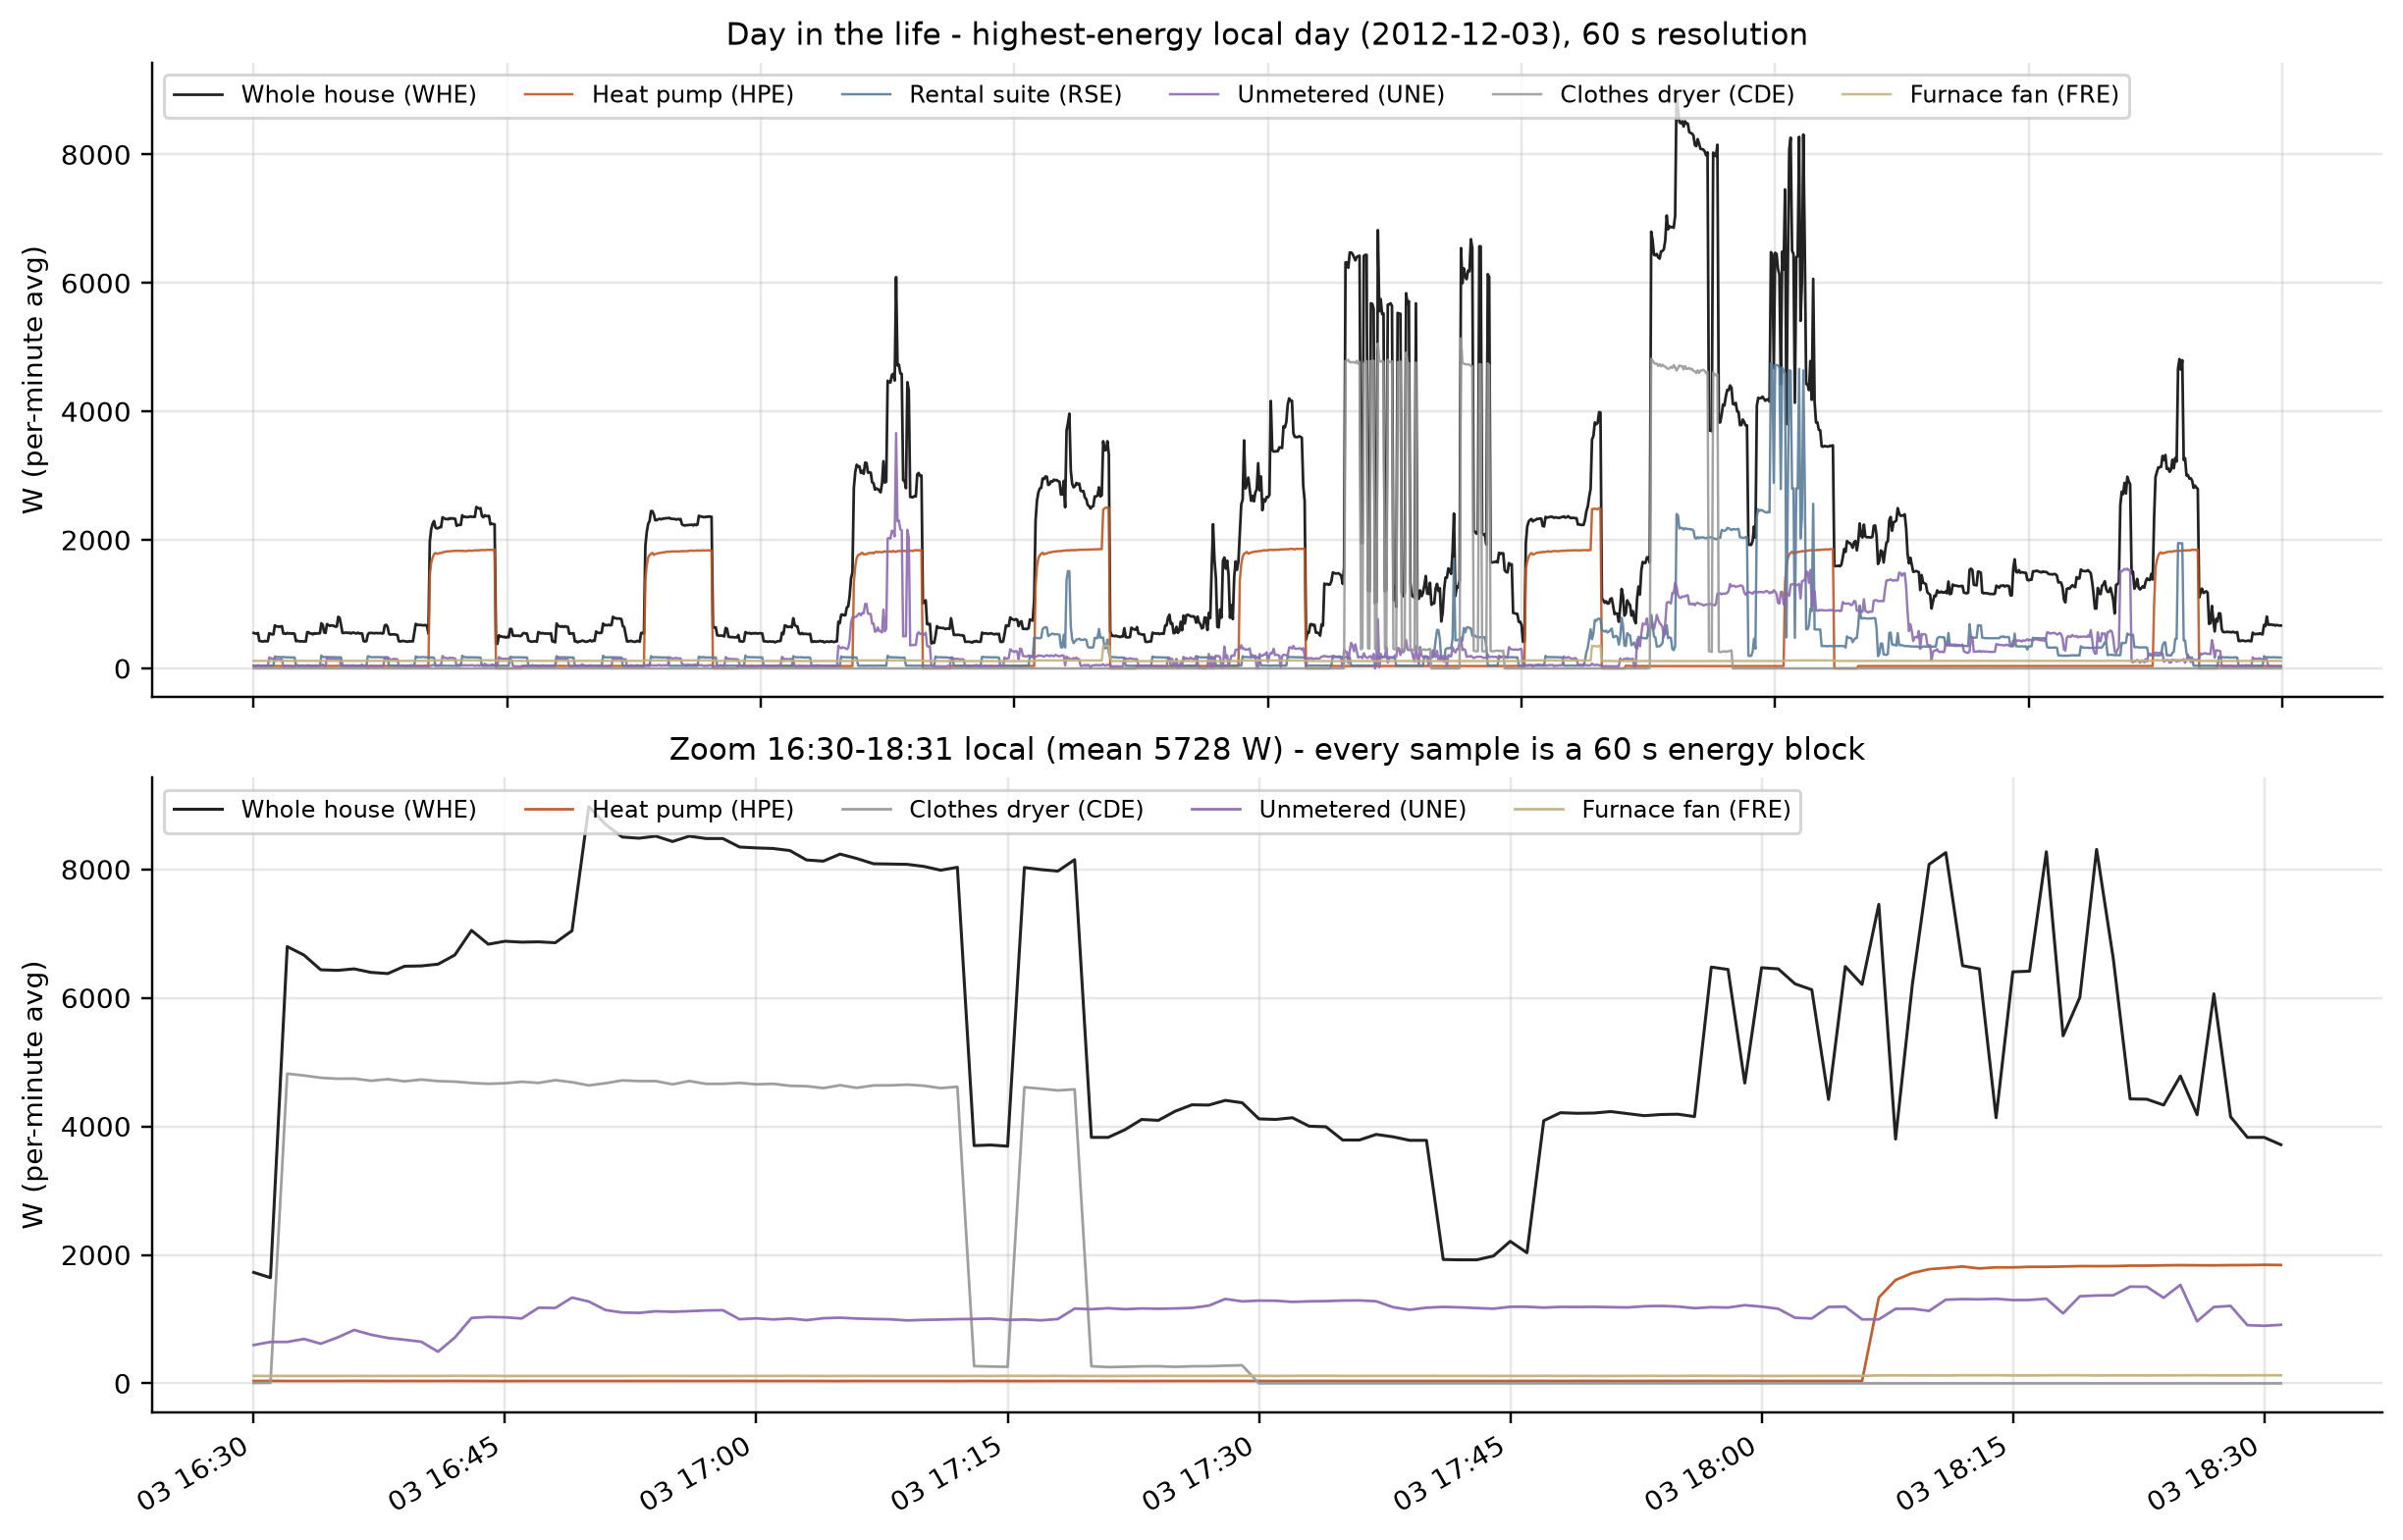

In [ ]:
whe_file = pq.read_table(eda.fnd_file('ampds2', 'Electricity_WHE.parquet'), columns=['P', 'Pt', 'V', 'f'])
Pw = whe_file['P'].to_numpy().astype(np.float64)
Pt = whe_file['Pt'].to_numpy().astype(np.float64)
d = np.diff(Pt)
_ok = np.abs(d) < 100000
print('semantics: corr(P, register-diff) over normal minutes = %.3f' % float(np.corrcoef(Pw[1:][_ok], d[_ok])[0, 1]))
print('register span: %.0f kWh | P-integral: %.0f kWh (agree to %.2f%%)' % ((Pt[-1] - Pt[0]) / 1000, (Pw * 60 / 3600).sum() / 1000, 100 * abs(Pt[-1] - Pt[0] - (Pw * 60 / 3600).sum()) / (Pw * 60 / 3600).sum()))
daykwh = pd.Series(P['WHE'] * 60 / 3600, index=IDX).groupby(IDX.normalize()).sum() / 1000
best_day = daykwh.idxmax()
sel = (IDX >= best_day) & (IDX < best_day + pd.Timedelta(days=1))
print('highest-energy local day: %s (%.1f kWh)' % (best_day.date(), daykwh.max()))
for _c in ['HPE', 'RSE', 'UNE', 'CDE', 'FRE', 'DWE', 'FGE']:
    print('   %-4s %-24s %.1f kWh' % (_c, NAME[_c], float((P[_c][sel] * 60 / 3600).sum() / 1000)))
_fig, _axes = plt.subplots(2, 1, figsize=(11.5, 7.2), height_ratios=[1, 1])
bd = pd.DataFrame({c: P[c][sel] for c in ['WHE', 'HPE', 'RSE', 'UNE', 'CDE', 'FRE']}, index=IDX[sel])
_ax = _axes[0]
_ax.plot(bd.index, bd['WHE'], color='#222222', lw=0.9, label=NAME['WHE'])
for _c, col in [('HPE', '#c05621'), ('RSE', '#5a7d9a'), ('UNE', '#8c6bb1'), ('CDE', '#999999'), ('FRE', '#c2b280')]:
    _ax.plot(bd.index, bd[_c], color=col, lw=0.8, alpha=0.9, label=NAME[_c])
_ax.set_title('Day in the life - highest-energy local day (%s), 60 s resolution' % best_day.date())
_ax.set_ylabel('W (per-minute avg)')
_ax.legend(ncol=6, fontsize=8, loc='upper left')
win = bd.between_time('16:30', '18:31')
_ax = _axes[1]
_ax.plot(win.index, win['WHE'], color='#222222', lw=1.0, label=NAME['WHE'])
for _c, col in [('HPE', '#c05621'), ('CDE', '#999999'), ('UNE', '#8c6bb1'), ('FRE', '#c2b280')]:
    _ax.plot(win.index, win[_c], color=col, lw=0.9, alpha=0.95, label=NAME[_c])
_ax.set_title('Zoom 16:30-18:31 local (mean %.0f W) - every sample is a 60 s energy block' % win['WHE'].mean())
_ax.set_ylabel('W (per-minute avg)')
_ax.legend(ncol=5, fontsize=8, loc='upper left')
_fig.autofmt_xdate()
_fig.tight_layout()
print('zoom window mean W: %.0f | peak minute: %.0f W' % (win['WHE'].mean(), win['WHE'].max()))
_fig  # render figure as cell output

**Reading it.** The day panel shows the two-year rhythm in miniature: a high morning plateau (heat pump recovering the overnight setback), mid-day activity, and a long evening block where the suite (RSE) and the main house (HPE, cooking, the UNE mystery load) stack to a sustained baseline with spikes toward 9 kW.

One honesty note: this is the two years' *highest-energy* local day, chosen deliberately - a median day is flatter (Q10's mean-day profiles). The lesson here is in the shapes, not the levels.

The zoom is the cadence lesson made visible. Every edge is a 60 s step. The dryer (CDE) switches on and simply *is on* for tens of minutes - its element cycles are far too short to resolve, so 60 s shows a block where 1 s would show element cycling. The heat pump (HPE) sits in long compressor runs. Nothing sub-minute survives; yet nothing energy-bearing is missing either: integrate any curve over the zoom and you get exactly the energy burned in those two hours.

This is precisely the trade our own deployment makes at 60 s polling: **we keep every Wh, we lose every needle.** [collectable]

## Q3 - What does 60 s cadence cost, exactly?

Let me quantify the needle loss with episode anatomy. Define an episode as a maximal run of minutes with whole-house draw above 1 kW, and ask: how long do episodes last, and where does the energy live?

Compare with what the high-rate datasets taught us: UK-DALE kettle boils are 20-100 s events; REFIT's shortest ON-detections were single 7 s samples. At 60 s, any event shorter than a minute can lift at most two samples - its duration is unrecoverable. The question is how much *energy* lives in that unrecoverable class.

WHE >1kW episodes: 24,159 in 2 years (33.1/day)
duration: p50 4 min, p90 39 min, max 537 min
episodes <=3 min: 11473 (47.5% of episodes) holding 3.6% of episode energy
FGE fridge: duty 36.6%, 39.3 cycles/day, ON p50 10 min, cycle p50 37 min, p50-ON 130 W, max 1497 W


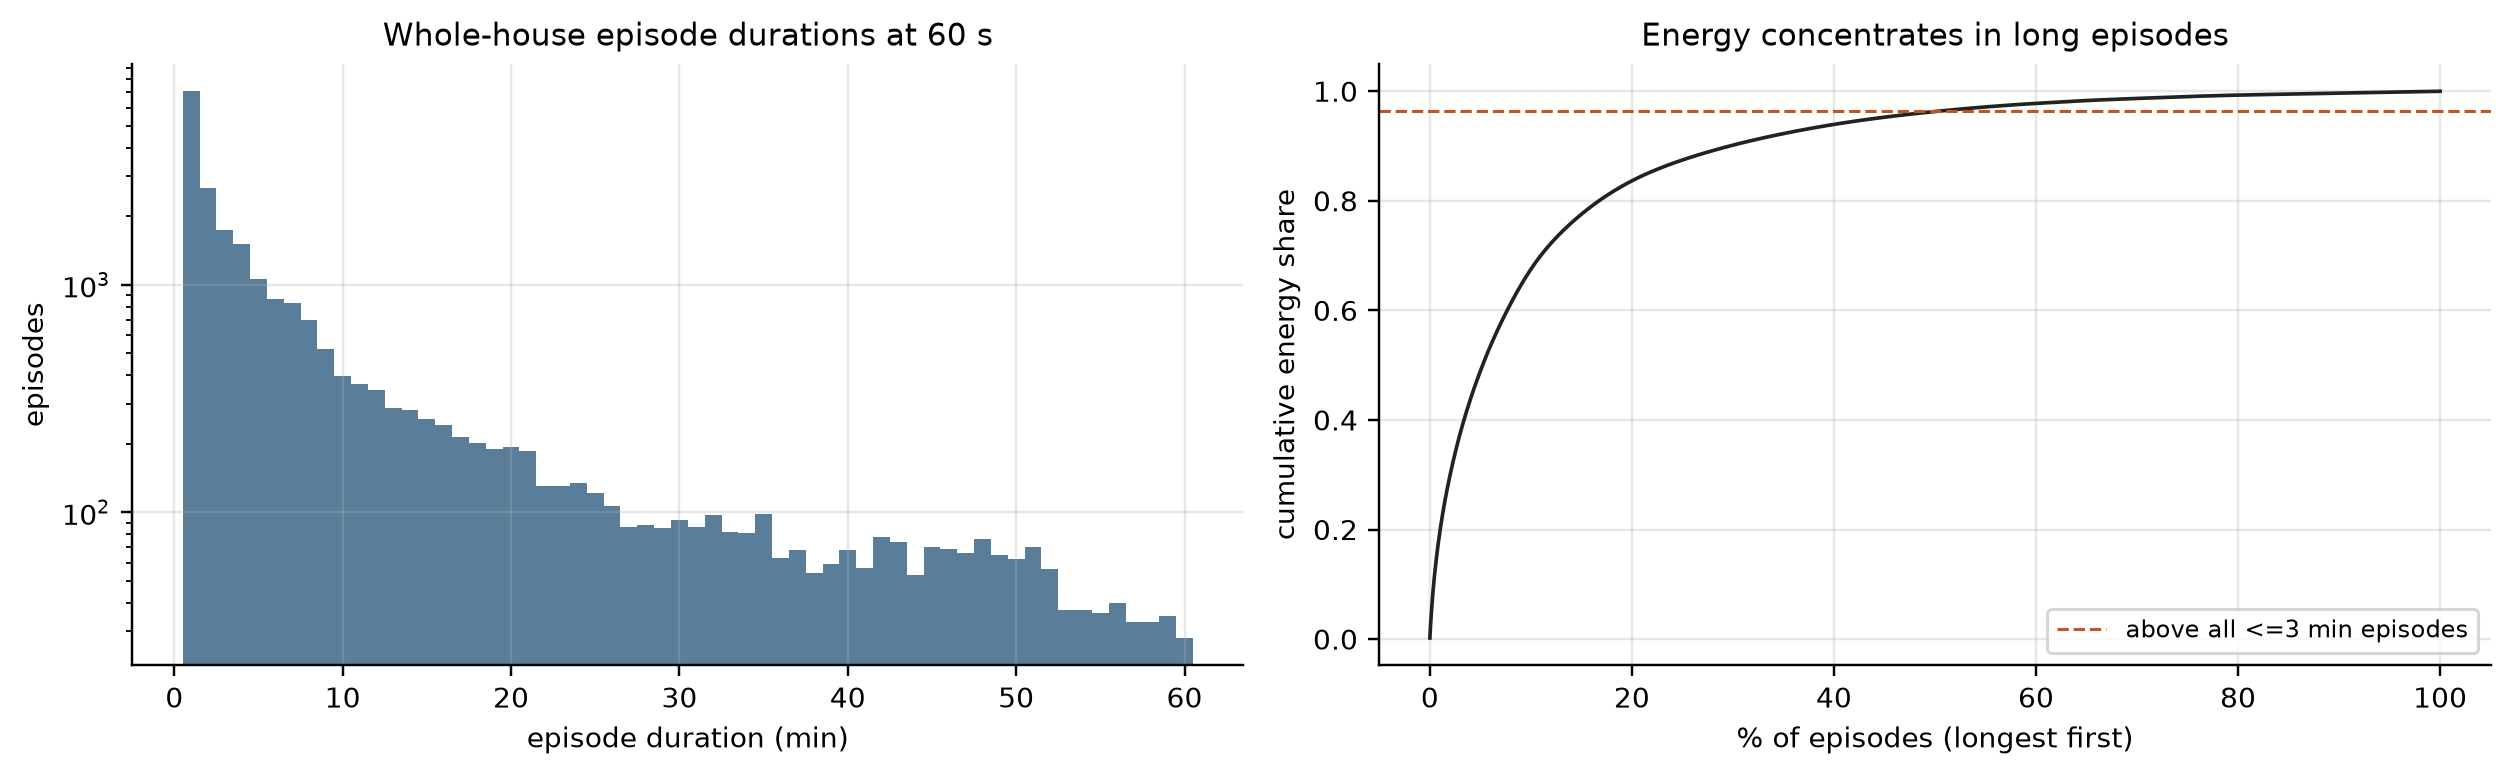

In [ ]:
_on = P['WHE'] > 1000
_edges = np.diff(np.concatenate([[0], _on.astype(np.int8), [0]]))
_st = np.where(_edges == 1)[0]
_en = np.where(_edges == -1)[0]
durs = (_en - _st).astype(float)
ener = np.array([float((P['WHE'][s:e] * 60 / 3600).sum()) for s, e in zip(_st, _en)])
short = durs <= 3
print('WHE >1kW episodes: %s in 2 years (%.1f/day)' % (fmt_int(len(durs)), len(durs) / 730.4))
print('duration: p50 %.0f min, p90 %.0f min, max %.0f min' % (np.percentile(durs, 50), np.percentile(durs, 90), durs.max()))
print('episodes <=3 min: %d (%.1f%% of episodes) holding %.1f%% of episode energy' % (short.sum(), 100 * short.mean(), 100 * ener[short].sum() / ener.sum()))
_f = P['FGE']
fon = _f > 90
fedges = np.diff(np.concatenate([[0], fon.astype(np.int8), [0]]))
fst = np.where(fedges == 1)[0]
fen = np.where(fedges == -1)[0]
fdur = fen - fst
print('FGE fridge: duty %.1f%%, %.1f cycles/day, ON p50 %.0f min, cycle p50 %.0f min, p50-ON %.0f W, max %.0f W' % (100 * fon.mean(), len(fst) / 730.4, np.percentile(fdur, 50), np.percentile(np.diff(fst), 50), np.percentile(_f[fon], 50), _f.max()))
_fig, _axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
_ax = _axes[0]
_ax.hist(durs, bins=np.arange(0.5, 61.5, 1), color='#5a7d9a')
_ax.set_yscale('log')
_ax.set_xlabel('episode duration (min)')
_ax.set_ylabel('episodes')
_ax.set_title('Whole-house episode durations at 60 s')
_ax = _axes[1]
o = np.argsort(-ener)
cum = np.cumsum(ener[o]) / ener.sum()
_ax.plot(np.arange(1, len(ener) + 1) / len(ener) * 100, cum, color='#222222', lw=1.2)
_ax.set_xlabel('% of episodes (longest first)')
_ax.set_ylabel('cumulative energy share')
_ax.set_title('Energy concentrates in long episodes')
_ax.axhline(1 - ener[short].sum() / ener.sum(), color='#c05621', ls='--', lw=1, label='above all <=3 min episodes')
_ax.legend(fontsize=8)
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** Nearly half of all ON-episodes (47.5%) are 3 minutes or shorter - exactly the class whose duration 60 s cannot measure - yet they hold just 3.6% of the energy. The energy story lives in the long tail: heat-pump runs, dryer cycles, oven sessions, episodes of 10-40+ minutes that 60 s captures essentially perfectly (a 2-minute boundary error against a 20+ minute length).

The fridge confirms that duty-cycle statistics *survive* the cadence: FGE cycles 39 times a day, runs ~10 minutes at ~130 W, and holds a 36.6% duty - squarely inside the 20-55% duty band we measured across UK-DALE and REFIT fridges at 1-7 s. For the gold layer: **at 60 s, trust duty, energy and long-block signatures; never trust event counts or durations for sub-3-minute loads.** [collectable]

A second, subtler cost: within a minute, loads superpose invisibly. When a kettle-class event fires while the fridge compressor runs, the minute reads as their sum - there is no residual shape left to unmix. At 1 s the fridge sawtooth under a boil is visible; at 60 s the minute is just a bigger block.

## Q4 - Two years, zero gaps - what does a healthy logger look like?

REFIT taught us the failure catalogue: lost hours, frozen meters, fleet-wide outages. AMPds2 is the control group - a logger that worked. Let me verify that claim rather than assert it, then spend the two-year horizon on what it uniquely buys: real seasonality against real weather.

all-circuit-zero minutes: 6
   zero row at 2012-05-04 10:34:00 local
   zero row at 2013-06-17 10:06:00 local
   zero row at 2013-06-17 10:34:00 local
   zero row at 2013-06-17 10:36:00 local
   zero row at 2013-06-17 10:37:00 local
   zero row at 2013-06-17 10:38:00 local
longest identical-WHE run: 11 min | runs >5 min: 678 (no frozen plateaus)
weather: 17520 hourly rows, 2012-03-31 17:00:00 -> 2014-03-31 16:00:00, mean temp 10.4 C
months kept: 24 full months
WHE winter mean 891 kWh/mo vs summer 696 (1.28x)
HPE winter mean 158 vs summer 53 kWh/mo (3.0x)
gas winter mean 7.2 vs summer 1.9 GJ/mo (3.9x)
corr(monthly WHE, monthly temp) = -0.65


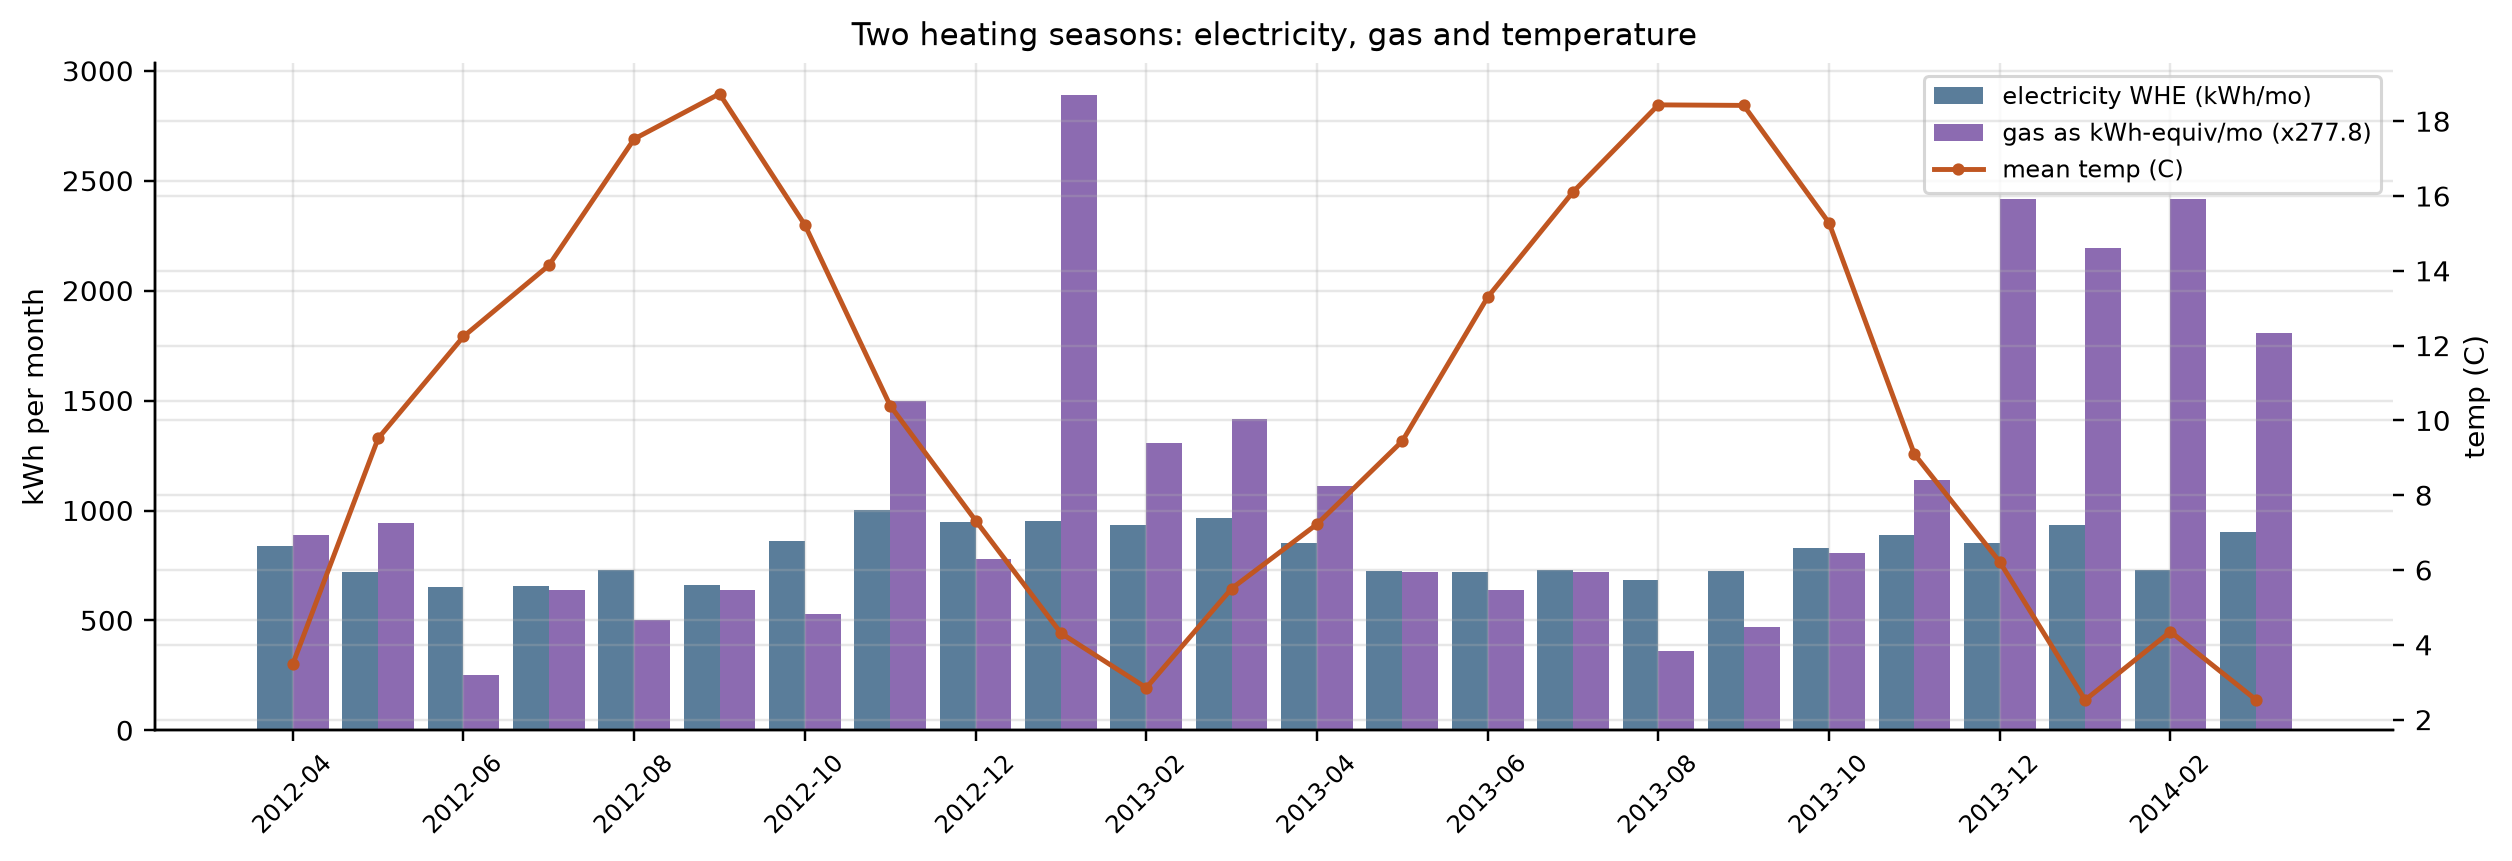

In [ ]:
allzero = np.all([P[c] == 0 for c in COLS], axis=0)
print('all-circuit-zero minutes: %d' % int(allzero.sum()))
for z in np.where(allzero)[0]:
    print('   zero row at %s local' % IDX[z])
ch = np.where(P['WHE'][1:] != P['WHE'][:-1])[0]
lens = np.diff(np.concatenate([[0], ch, [len(P['WHE']) - 1]]))
print('longest identical-WHE run: %d min | runs >5 min: %d (no frozen plateaus)' % (lens.max(), int((lens > 5).sum())))
wx = pq.read_table(eda.fnd_file('ampds2', 'Climate_HourlyWeather.parquet'), columns=['ts_us', 'Temp (C)'])
wts = wx['ts_us'].to_numpy().astype(np.int64) * 1000
wtemp = wx['Temp (C)'].to_numpy().astype(np.float64)
WIDX = pd.to_datetime(wts, unit='us', utc=True).tz_convert('America/Vancouver').tz_localize(None)
print('weather: %d hourly rows, %s -> %s, mean temp %.1f C' % (len(wts), WIDX[0], WIDX[-1], np.nanmean(wtemp)))
gas_m = pq.read_table(eda.fnd_file('ampds2', 'NaturalGas_Monthly.parquet'))
gvals = gas_m['Net Consumption (GJ)'].to_numpy().astype(float)
gu = 'us' if gas_m['ts_us'][0].as_py() > 1000000000000000.0 else 'ms'
gm_start = pd.to_datetime(int(gas_m['ts_us'][0].as_py()), unit=gu, utc=True).tz_localize(None)
gmon = pd.period_range(gm_start.to_period('M'), periods=len(gvals), freq='M').astype(str)
df = pd.DataFrame({'WHE': P['WHE'] * 60 / 3600 / 1000, 'HPE': P['HPE'] * 60 / 3600 / 1000}, index=IDX)
me = df['WHE'].resample('MS').sum()
mh = df['HPE'].resample('MS').sum()
mt = pd.Series(wtemp, index=WIDX).resample('MS').sum() / pd.Series(1, index=WIDX).resample('MS').size()
cnt = pd.Series(1, index=IDX).resample('MS').size()
keep = cnt.values > 40000
me, mh, mt = (me[keep], mh[keep], mt.values[:len(cnt)][keep])
mk = [str(k)[:7] for k in me.index]
gk = pd.Series(np.array(gvals) * 277.8, index=gmon).reindex(mk)
winter = np.array([m[5:] in ('12', '01', '02') for m in mk])
summer = np.array([m[5:] in ('06', '07', '08') for m in mk])
print('months kept: %d full months' % int(keep.sum()))
print('WHE winter mean %.0f kWh/mo vs summer %.0f (%.2fx)' % (me[winter].mean(), me[summer].mean(), me[winter].mean() / me[summer].mean()))
print('HPE winter mean %.0f vs summer %.0f kWh/mo (%.1fx)' % (mh[winter].mean(), mh[summer].mean(), mh[winter].mean() / mh[summer].mean()))
print('gas winter mean %.1f vs summer %.1f GJ/mo (%.1fx)' % (gk[winter].mean() / 277.8, gk[summer].mean() / 277.8, gk[winter].mean() / max(gk[summer].mean(), 1e-09)))
print('corr(monthly WHE, monthly temp) = %.2f' % float(np.corrcoef(me.values, mt)[0, 1]))
_fig, _ax = plt.subplots(figsize=(11.5, 4.0))
x = np.arange(len(mk))
_ax.bar(x - 0.21, me.values, width=0.42, color='#5a7d9a', label='electricity WHE (kWh/mo)')
_ax.bar(x + 0.21, gk.values, width=0.42, color='#8c6bb1', label='gas as kWh-equiv/mo (x277.8)')
_ax.set_ylabel('kWh per month')
_ax2 = _ax.twinx()
_ax2.plot(x, mt, color='#c05621', lw=1.6, marker='o', ms=3, label='mean temp (C)')
_ax2.set_ylabel('temp (C)')
_ax.set_xticks(x[::2])
_ax.set_xticklabels([mk[i] for i in range(0, len(mk), 2)], rotation=45, fontsize=8)
_ax.set_title('Two heating seasons: electricity, gas and temperature')
h1, l1 = _ax.get_legend_handles_labels()
h2, l2 = _ax2.get_legend_handles_labels()
_ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The integrity checks pass: the longest run of identical whole-house values is 11 minutes (a flat overnight stretch, not a frozen meter - REFIT's worst froze for 35.6 days), and the only structural holes are 6 all-zero minutes. Cross-referenced with Q7 they stop being mysterious: five sit inside the 2013-06-17 register-meltdown window and one is the 2012-05-04 register-wipe minute. The rows are never missing - but the logger writes zeros exactly when its cumulative registers corrupt. Reusable ingest rule: **a perfect row count is not proof of perfect data, and zeros adjacent to a register discontinuity are suspect, not merely empty.** [collectable]

The seasonality panel is what two uninterrupted years buy. Monthly electricity tracks temperature (corr -0.65), peaking at 1.28x the summer level, and the mechanism is visible in the components: the heat pump draws 3.0x more in winter, and the gas meter swings 3.9x between seasons. This is a **hybrid-heating home**: an electric heat pump carrying the shoulder seasons, a gas furnace for the deepest cold (with FRE as its electric fan), gas for hot water. [insight only] - we will have no gas meter - but the transferable lesson stands: **one winter is enough to see a heating signature; only a full year separates "always cold" from "heating season".** [collectable]

## Q5 - Who is in the panel? The 100%-tile label matrix

Now the question UK-DALE and REFIT could never answer cleanly: what share of the whole-house meter do the submeters *explain*? Here the answer is arithmetic, not statistics - the circuits tile the mains exactly. Let me verify the tiling three ways, then classify every circuit by behaviour.

tile check 1: WHE - MHE - RSE: max |residual| 1053.0 W
tile check 2: WHE - RSE - sum(20 house circuits): max |residual| 0.0 W
energy decomposition of WHE: named-18 59.5% + RSE 22.5% + GRE 0.14% + UNE 17.9%
(UNE is DEFINED as WHE - RSE - GRE - named-18: check 2 is an identity, not a discovery - Q6)
tile check 3: MHE == WHE - RSE - GRE? max |diff| 0.0 W (MHE is derived)
always-on circuits (>1W >99% of minutes): EQE, FRE, OFE, UTE, HTE, UNE
trace circuits (<50 kWh over 2y): OUE (0 kWh), DNE (12 kWh), B1E (18 kWh), GRE (27 kWh)
HTE: p50 5 W, max 74 W, total 128 kWh


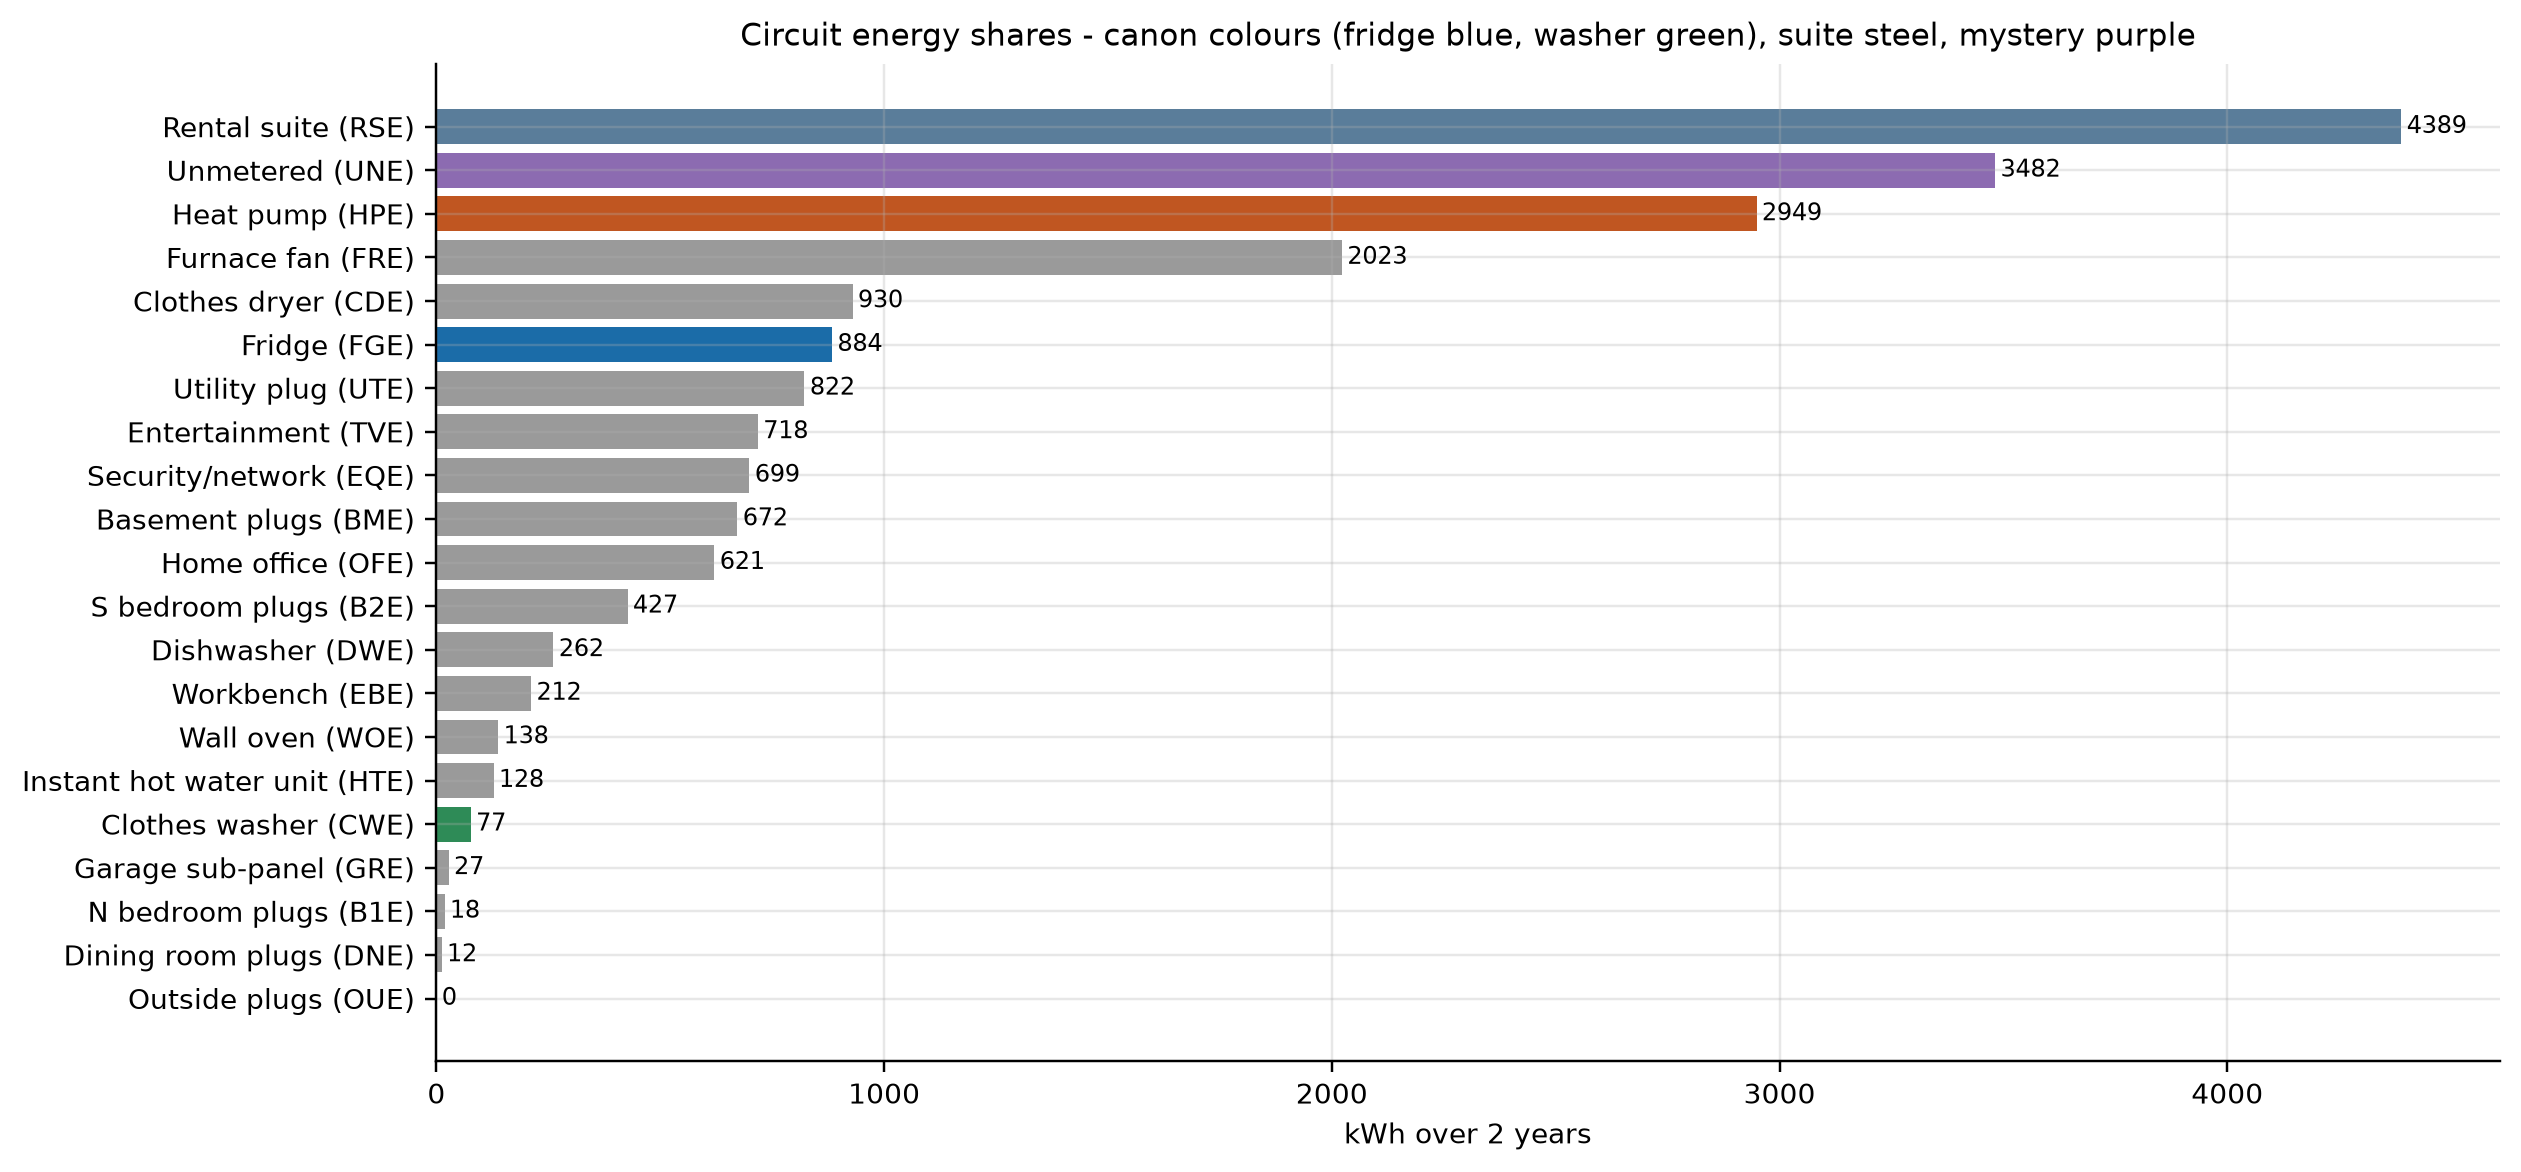

In [ ]:
resid = P['WHE'] - P['MHE'] - P['RSE']
print('tile check 1: WHE - MHE - RSE: max |residual| %.1f W' % np.abs(resid).max())
house = [c for c in COLS if c not in ('WHE', 'MHE', 'RSE')]
resid2 = P['WHE'] - P['RSE'] - np.sum([P[c] for c in house], axis=0)
print('tile check 2: WHE - RSE - sum(20 house circuits): max |residual| %.1f W' % np.abs(resid2).max())
_named18 = [c for c in house if c not in ('UNE', 'GRE')]
_tot = P['WHE'].sum() / 60 / 1000
print('energy decomposition of WHE: named-18 %.1f%% + RSE %.1f%% + GRE %.2f%% + UNE %.1f%%' % (100 * np.sum([P[c] for c in _named18], axis=0).sum() / 60 / 1000 / _tot, 100 * P['RSE'].sum() / 60 / 1000 / _tot, 100 * P['GRE'].sum() / 60 / 1000 / _tot, 100 * P['UNE'].sum() / 60 / 1000 / _tot))
print('(UNE is DEFINED as WHE - RSE - GRE - named-18: check 2 is an identity, not a discovery - Q6)')
PASS['named18_share_pct'] = round(100 * np.sum([P[c] for c in _named18], axis=0).sum() / 60 / 1000 / _tot, 1)
mhe_pred = P['WHE'] - P['RSE'] - P['GRE']
print('tile check 3: MHE == WHE - RSE - GRE? max |diff| %.1f W (MHE is derived)' % np.abs(P['MHE'] - mhe_pred).max())
always_on = [c for c in house if (P[c] > 1).mean() > 0.99]
trace = [c for c in house if PASS['kwh'][c] < 50]
print('always-on circuits (>1W >99%% of minutes): %s' % ', '.join(always_on))
print('trace circuits (<50 kWh over 2y): %s' % ', '.join(('%s (%.0f kWh)' % (c, PASS['kwh'][c]) for c in sorted(trace, key=lambda x: PASS['kwh'][x]))))
print('HTE: p50 %.0f W, max %.0f W, total %.0f kWh' % (np.percentile(P['HTE'], 50), P['HTE'].max(), PASS['kwh']['HTE']))
_fig, _ax = plt.subplots(figsize=(11.5, 5.4))
order = sorted(house + ['RSE'], key=lambda c: PASS['kwh'][c])
cols = ['#1b6ca8' if c == 'FGE' else '#2e8b57' if c == 'CWE' else '#c05621' if c == 'HPE' else '#8c6bb1' if c == 'UNE' else '#5a7d9a' if c == 'RSE' else '#9a9a9a' for c in order]
vals = [PASS['kwh'][c] for c in order]
_ax.barh([NAME[c] for c in order], vals, color=cols)
for i, v in enumerate(vals):
    _ax.text(v + 12, i, '%.0f' % v, va='center', fontsize=8)
_ax.set_xlabel('kWh over 2 years')
_ax.set_title('Circuit energy shares - canon colours (fridge blue, washer green), suite steel, mystery purple')
_fig.tight_layout()
_fig  # render figure as cell output

tiling week 2012-12-01 .. 2012-12-08: max |WHE - (22 stacked bands)| = 0.0000 W over the 10,080 minutes


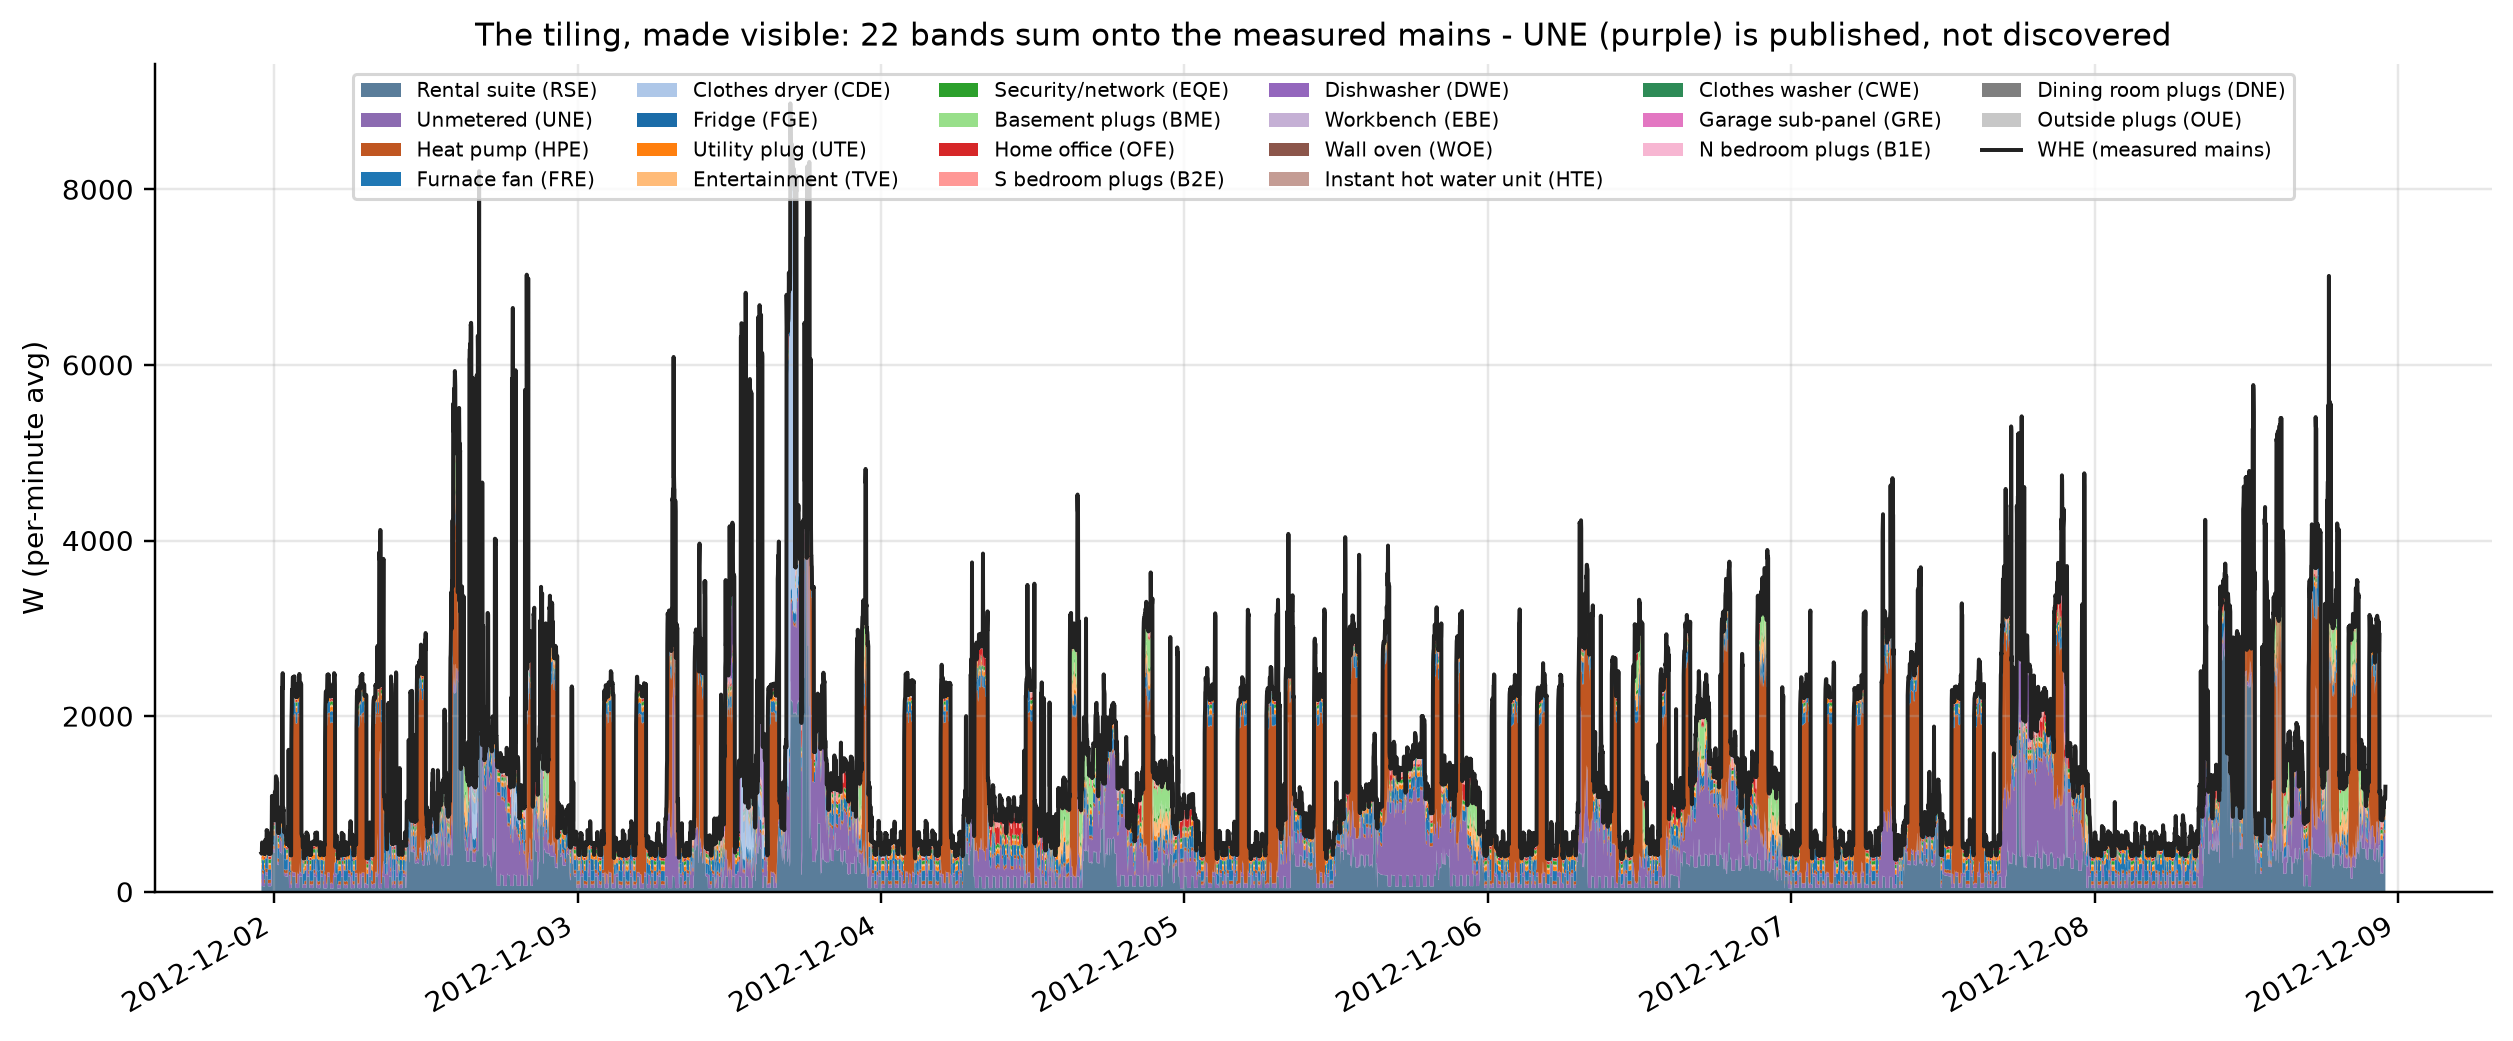

In [ ]:
# tiling made visible: one week, every circuit stacked, WHE on top - the
# stack closes onto the measured mains because UNE (purple) is part of the closure
_day = pd.Series(P['WHE'], index=IDX).resample('D').sum()
_wk0 = int(np.argmax(np.convolve(_day.to_numpy(), np.ones(7), mode='valid')))
_sl = slice(_wk0 * 1440, (_wk0 + 7) * 1440)
_torder = sorted((c for c in COLS if c not in ('WHE', 'MHE')), key=lambda c: -PASS['kwh'][c])
_feat = {'UNE': '#8c6bb1', 'RSE': '#5a7d9a', 'HPE': '#c05621', 'FGE': '#1b6ca8', 'CWE': '#2e8b57'}
_rest = [c for c in _torder if c not in _feat]
_cyc = [plt.cm.tab20(i % 20) for i in range(len(_rest))]
_tcols = [_feat[c] if c in _feat else _cyc[_rest.index(c)] for c in _torder]
_tstack = np.vstack([P[c][_sl] for c in _torder])
_tresid = float(np.abs(P['WHE'][_sl] - _tstack.sum(axis=0)).max())
print('tiling week %s .. %s: max |WHE - (22 stacked bands)| = %.4f W over the 10,080 minutes' % (IDX[_sl][0].date(), IDX[_sl][-1].date(), _tresid))
PASS['tile_resid_w'] = round(_tresid, 4)
_fig, _ax = plt.subplots(figsize=(11.5, 4.8))
_ax.stackplot(IDX[_sl], _tstack, labels=[NAME[c] for c in _torder], colors=_tcols, lw=0.0)
_ax.plot(IDX[_sl], P['WHE'][_sl], color='#222222', lw=1.3, label='WHE (measured mains)')
_ax.set_ylabel('W (per-minute avg)')
_ax.set_title('The tiling, made visible: 22 bands sum onto the measured mains - UNE (purple) is published, not discovered')
_ax.legend(ncol=6, fontsize=6.5, loc='upper center')
_fig.autofmt_xdate()
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** Two exact tilings and one near-miss that identifies itself - but read check 2 correctly: it is exact *by construction*. The release computes UNE as WHE minus every other channel, so "the 20 circuits plus the suite tile WHE exactly" is a definition, not a discovery; check 3's exactness (MHE = WHE - RSE - GRE to the watt, every minute) is the same arithmetic showing itself. Check 1's residual is exactly GRE (max 1053 W = the garage's max draw): the detached-garage sub-panel is inside WHE but outside MHE. The honest coverage statement: **the release closes its books by construction and publishes the closure as a column called Unmetered.** UK-DALE's 86-97% and REFIT's ~36% are not like-for-like - those residuals are unexplained shares of a *measured* aggregate; here the residual has simply been named. The stacked week above makes the same point graphically: twenty-two bands sum onto the measured WHE line to within the printed watt-level residual - the purple band (UNE) is part of that closure, published by the release rather than discovered by us.

This reframes the disaggregation problem: the "residual/unknown" class has not disappeared here - it has been **named and published** (17.9% of the whole service), and the open risks move into **label quality** (next question) and **residual composition** (Q6). With enough CT clamps the tiling becomes an identity; what does *not* come from clamps is knowing what the remainder contains. [collectable]

The behaviour classes fall straight out of the energy bar chart above:

- **Dead or trace:** OUE (outside plugs - 0 kWh, a dead port), DNE, B1E, GRE (the detached garage barely draws). No appliance model wasted on these.
- **Always-on service loads:** EQE (security/network gear, 40 W flat), UTE (utility plug, 51 W flat - 822 kWh, nearly as much as the dryer), OFE (home office, 27 W), FRE (furnace fan + thermostat, 110 W), HTE (5 W) and UNE's base - together a hard floor of roughly 340 W under the whole-house trace. Note ~108 W of that floor is the UNE remainder - "attributed" only in the arithmetic sense; REFIT's unexplained 170-548 W residuals are the same object without a name.
- **The big four:** HPE heat pump, RSE rental suite, the UNE remainder, FRE furnace fan - over half the house's energy in four channels.

## Q6 - The published remainder: what lives in UNE, and a label that lies

Two label-audit findings, one per direction of failure:

### (a) The published remainder: UNE is not a meter

UNE - 3,482 kWh, 17.9% of all electricity - is not a meter. The release's own record states **21 power meters**; there are 21 per-circuit CSVs and 21 HDF5 meters, but the wide matrices carry **23 columns**. The two extras are arithmetic, and the release's own bytes prove it twice over:

1. **The identity is exact by construction.** WHE - RSE - GRE - sum(18 named) - UNE = 0 for every one of the 1,051,200 rows - and the same identity holds to the watt in S as well. An identity that holds in two independently recorded quantities, every row, is a definition, not a coincidence - it is why Q5's check 2 could never fail.

2. **UNE violates physics the real meters obey.** Apparent power can never be less than active power. For every per-circuit channel the violation rate is a rounding-error trickle (WHE's 0.16% is exactly the register-corrupt minutes of Q7). UNE breaks S >= P on **99.3% of minutes**, its burst minutes post a median P/S of 1.16 (P *above* S - impossible for a measured channel), and its apparent-energy integral (1,457 kWh) is less than half its active integral (3,482 kWh). MHE shows the same signature at lower amplitude (26% of minutes) - consistent with Q5's finding that it is arithmetic.

So Q6's question is the transferable one: **in a fully-instrumented home, what lives in the publisher's remainder?** Its behaviour: never off (99.4% of minutes above 1 W, ~108 W median), busier through the working day (~170 W mean) than overnight (~85 W), with about seven bursts a day above 1 kW (median 4 minutes, up to 5.3 kW) - short heating bursts sitting on a permanent base, exactly a water-heating profile. And the release ships witnesses: a hot-water series (HTW), the whole-home water meter (WHW) and a gas water-heater counter (WHG). If the remainder is dominated by water heating, its bursts should co-fire with all three.

### (b) The lying label: the "Instant Hot Water Unit" that never heated anything

The circuit our gold map *does* name "Instant Hot Water Unit" - HTE - never exceeds 74 W. That is pump-sized, not element-sized: whatever this circuit feeds, it has never heated water. Meanwhile the *unlabelled* remainder behaves exactly like the water-heating circuit the label claims. Label and behaviour have swapped places.

identity WHE - RSE - GRE - 18 named - UNE: max |resid| in P = 0.0000 W, in S = 0.0000 VAR
minutes with S < P: UNE 99.34% | WHE 0.16% (register-corrupt) | UNE burst-median P/S = 1.16 (>1 impossible)
UNE active-energy integral 3482 kWh vs apparent-energy integral 1457 kWh (S < P integral - no meter can do this)
UNE: 3482 kWh (17.9% of WHE) | on%(>1W) 99.4 | bursts >1kW: 5020 (6.9/day)
burst duration p50 4 min | burst power p50 1525 W, max 5258 W
small-hours (00-06) mean 85 W vs working-day (09-17) mean 170 W
attribution test - P(hot-water flow | UNE>1kW) = 0.20 vs baseline P(flow) = 0.09 (2.2x)
same vs whole-home water: 0.31 vs 0.13 baseline (2.3x)
gas water-heater co-firing: P(WHG gas | UNE burst) = 0.17 vs baseline 0.09 (2.0x)
hour-of-day-matched control: HTW 1.42x | WHW 1.54x | WHG 1.45x  (raw: 2.2 / 2.3 / 2.0)


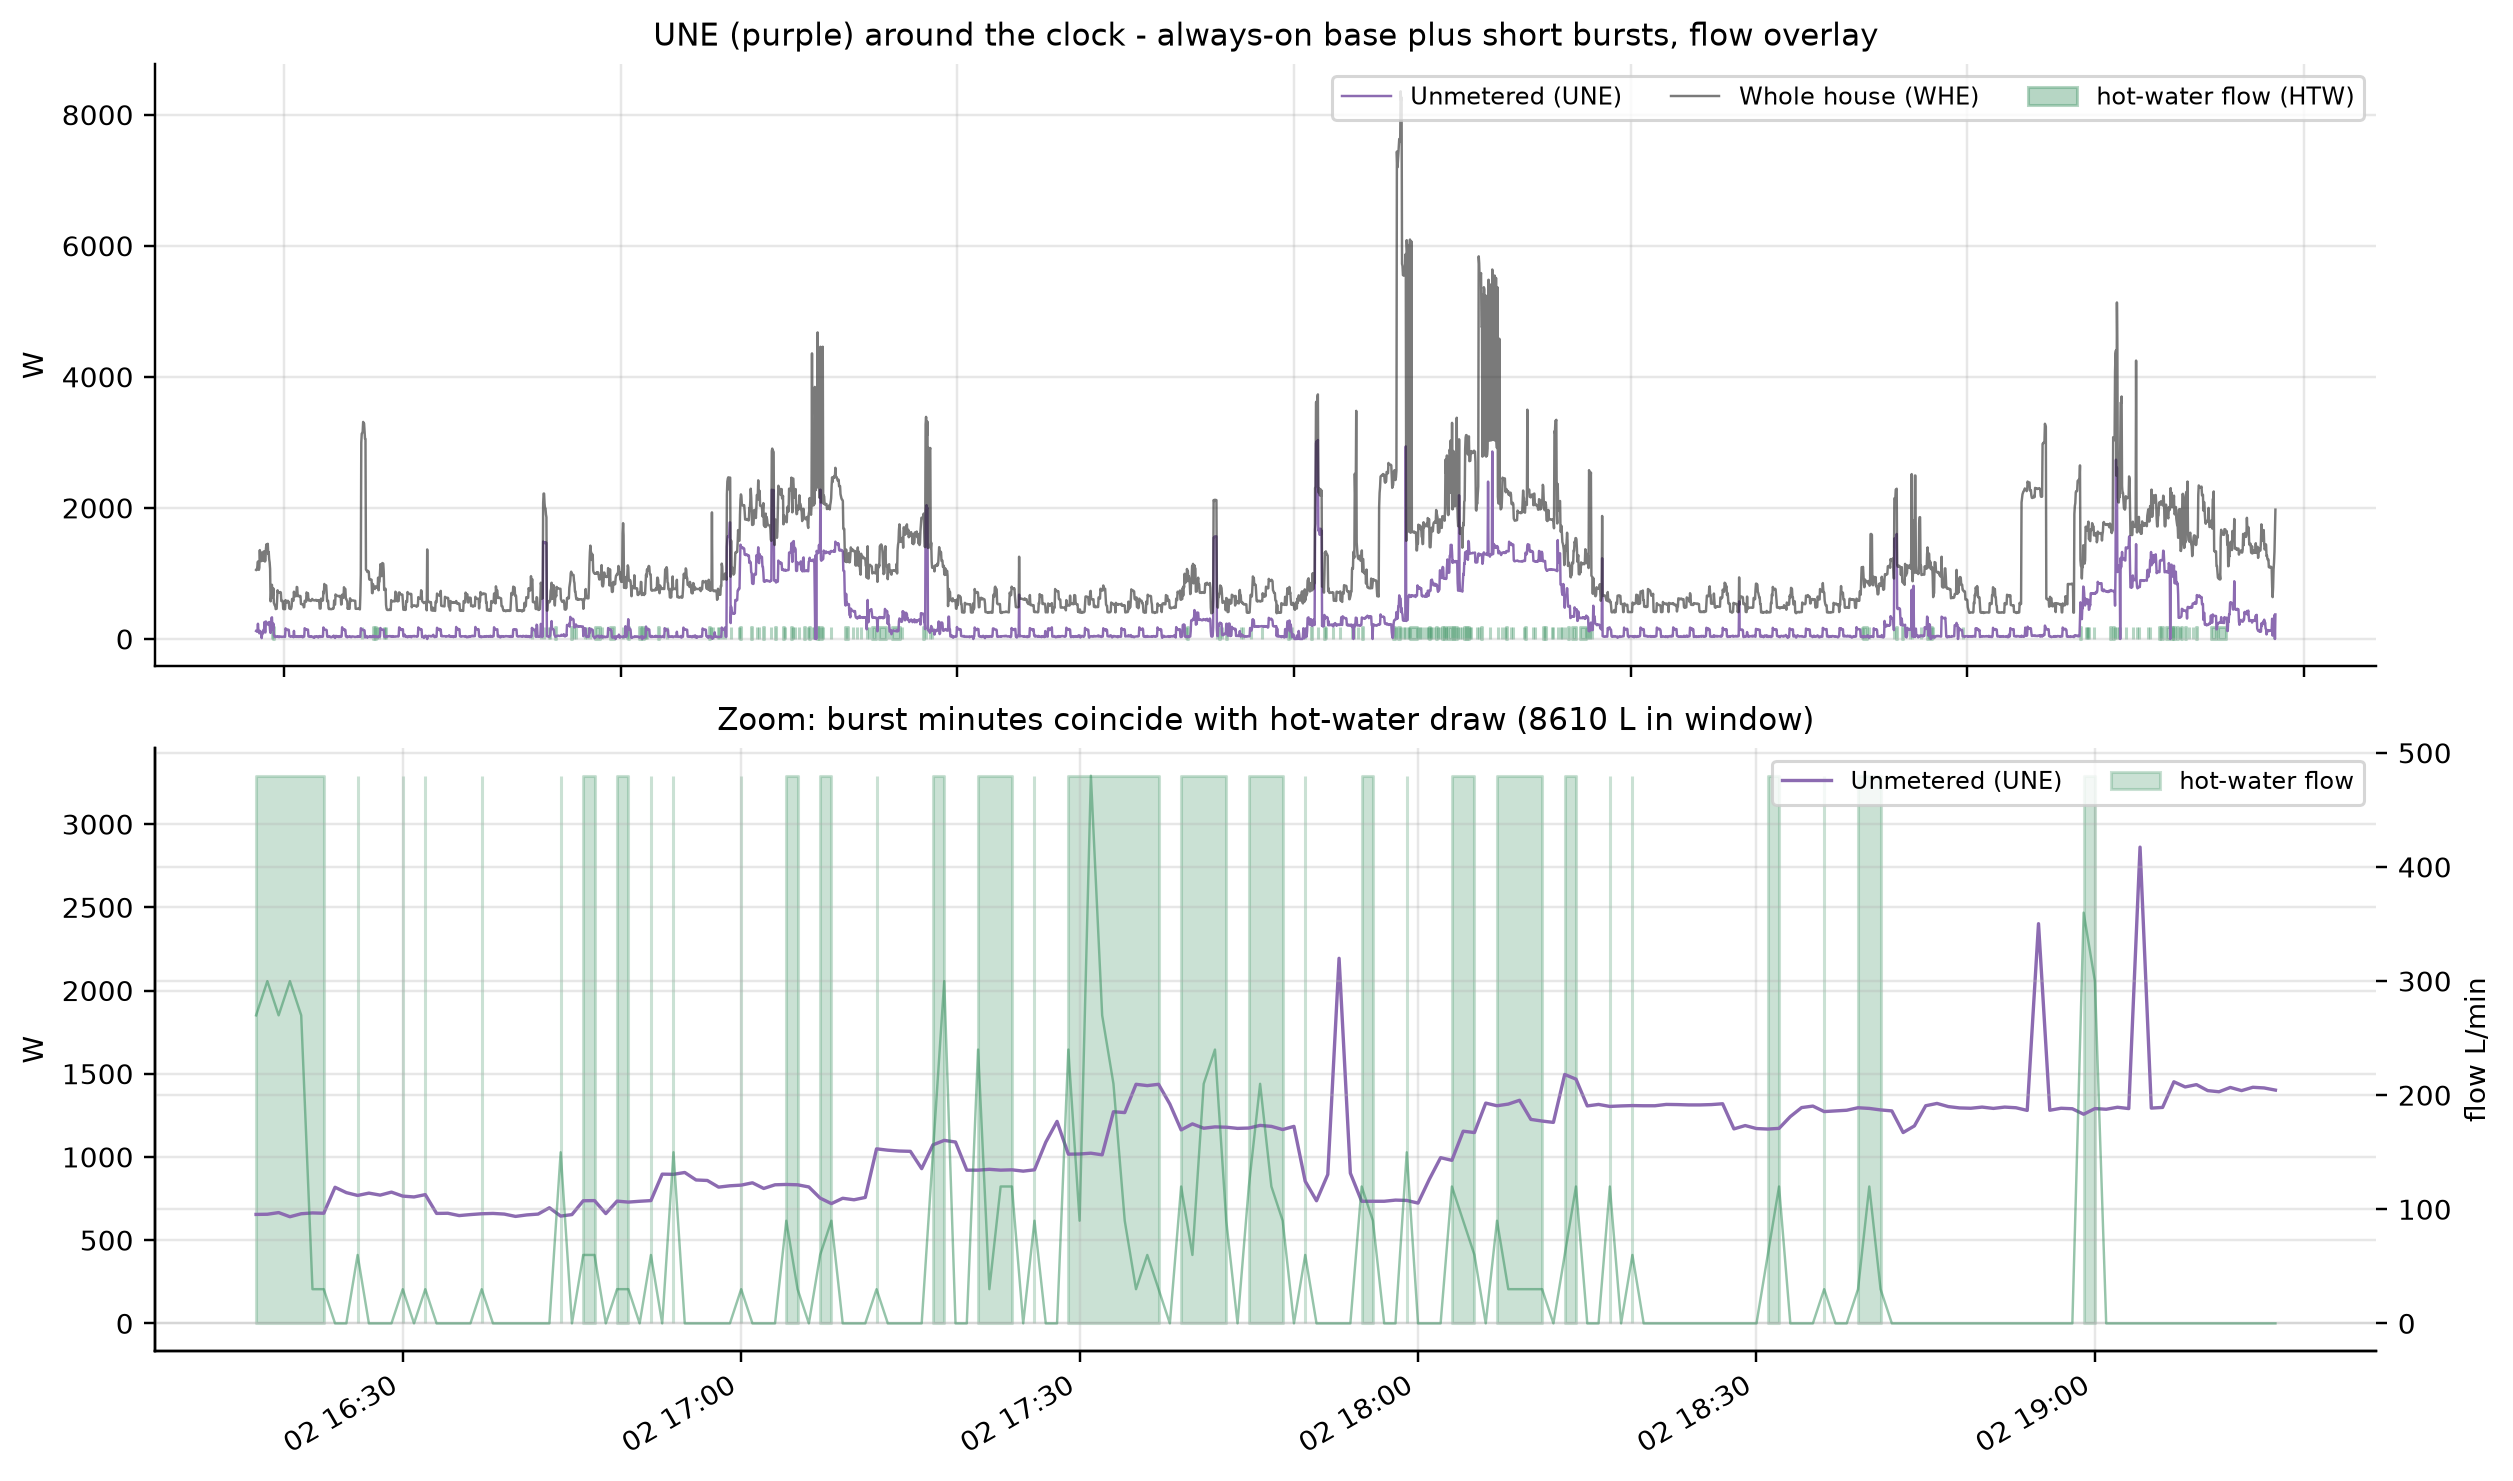

In [ ]:
# proof 1: the exact identity, in P and S
_named18 = [c for c in COLS if c not in ('WHE', 'MHE', 'RSE', 'UNE', 'GRE')]
r1 = P['WHE'] - P['RSE'] - P['GRE'] - np.sum([P[c] for c in _named18], axis=0) - P['UNE']
S_wide = pq.read_table(eda.fnd_file('ampds2', 'Electricity_S.parquet')).to_pandas()
r1s = S_wide['WHE'] - S_wide['RSE'] - S_wide['GRE'] - S_wide[_named18].sum(axis=1) - S_wide['UNE']
print('identity WHE - RSE - GRE - 18 named - UNE: max |resid| in P = %.4f W, in S = %.4f VAR' % (np.abs(r1).max(), np.abs(r1s).max()))
viol_une = 100 * (S_wide['UNE'] < P['UNE']).mean()
# proof 2: physics - apparent power below active power
viol_whe = 100 * (S_wide['WHE'] < P['WHE']).mean()
une_burst = P['UNE'] > 1000
ps_burst = P['UNE'][une_burst][S_wide['UNE'][une_burst] > 0] / S_wide['UNE'][une_burst][S_wide['UNE'][une_burst] > 0]
print('minutes with S < P: UNE %.2f%% | WHE %.2f%% (register-corrupt) | UNE burst-median P/S = %.2f (>1 impossible)' % (viol_une, viol_whe, ps_burst.median()))
une_p_kwh = P['UNE'].sum() / 60 / 1000
une_s_kwh = S_wide['UNE'].sum() / 60 / 1000
print('UNE active-energy integral %.0f kWh vs apparent-energy integral %.0f kWh (S < P integral - no meter can do this)' % (une_p_kwh, une_s_kwh))
PASS['une_s_lt_p_pct'] = round(float(viol_une), 2)
PASS['une_p_kwh'] = round(float(une_p_kwh))
PASS['une_s_kwh'] = round(float(une_s_kwh))
une = P['UNE']
_big = une > 1000
redges = np.diff(np.concatenate([[0], _big.astype(np.int8), [0]]))
rst = np.where(redges == 1)[0]
ren = np.where(redges == -1)[0]
print('UNE: %.0f kWh (%.1f%% of WHE) | on%%(>1W) %.1f | bursts >1kW: %d (%.1f/day)' % (PASS['kwh']['UNE'], 100 * PASS['kwh']['UNE'] / PASS['total'], 100 * (une > 1).mean(), len(rst), len(rst) / (len(ts_us) / 1440)))
print('burst duration p50 %.0f min | burst power p50 %.0f W, max %.0f W' % (np.percentile(ren - rst, 50), np.percentile(une[_big], 50), une.max()))
night = HOD < 7
print('small-hours (00-06) mean %.0f W vs working-day (09-17) mean %.0f W' % (une[night].mean(), une[(HOD >= 9) & (HOD < 17)].mean()))
htw = pq.read_table(eda.fnd_file('ampds2', 'Water_HTW.parquet'), columns=['avg_rate'])
flow = htw['avg_rate'].to_numpy().astype(np.float64) > 0
print('attribution test - P(hot-water flow | UNE>1kW) = %.2f vs baseline P(flow) = %.2f (%.1fx)' % (flow[_big].mean(), flow.mean(), flow[_big].mean() / flow.mean()))
whw = pq.read_table(eda.fnd_file('ampds2', 'Water_WHW.parquet'), columns=['avg_rate'])
flow2 = whw['avg_rate'].to_numpy().astype(np.float64) > 0
print('same vs whole-home water: %.2f vs %.2f baseline (%.1fx)' % (flow2[_big].mean(), flow2.mean(), flow2[_big].mean() / flow2.mean()))
whg = pq.read_table(eda.fnd_file('ampds2', 'NaturalGas_WHG.parquet'), columns=['avg_rate'])
gas_on = whg['avg_rate'].to_numpy().astype(np.float64) > 0
print('gas water-heater co-firing: P(WHG gas | UNE burst) = %.2f vs baseline %.2f (%.1fx)' % (gas_on[_big].mean(), gas_on.mean(), gas_on[_big].mean() / gas_on.mean()))
exp_flow = np.array([flow[(HOD == h) & ~_big].mean() for h in range(24)])
exp_flow2 = np.array([flow2[(HOD == h) & ~_big].mean() for h in range(24)])
exp_gas = np.array([gas_on[(HOD == h) & ~_big].mean() for h in range(24)])
print('hour-of-day-matched control: HTW %.2fx | WHW %.2fx | WHG %.2fx  (raw: %.1f / %.1f / %.1f)' % (flow[_big].mean() / exp_flow[HOD[_big]].mean(), flow2[_big].mean() / exp_flow2[HOD[_big]].mean(), gas_on[_big].mean() / exp_gas[HOD[_big]].mean(), flow[_big].mean() / flow.mean(), flow2[_big].mean() / flow2.mean(), gas_on[_big].mean() / gas_on.mean()))
PASS['une_flow_enr'] = float(flow[_big].mean() / flow.mean())
PASS['une_whg_enr'] = float(gas_on[_big].mean() / gas_on.mean())
PASS['une_htw_matched'] = round(float(flow[_big].mean() / exp_flow[HOD[_big]].mean()), 2)
PASS['une_whw_matched'] = round(float(flow2[_big].mean() / exp_flow2[HOD[_big]].mean()), 2)
PASS['une_whg_matched'] = round(float(gas_on[_big].mean() / exp_gas[HOD[_big]].mean()), 2)
score = _big.astype(np.int8) + flow.astype(np.int8)
cs = np.cumsum(np.concatenate([[0], score]))
# hour-matched control: bursts have a daily rhythm, so compare against non-burst minutes in the SAME hour
w = 180
wins = cs[w:] - cs[:-w]
k = int(np.argmax(wins))
z0 = max(0, (k // 1440 - 1) * 1440)
_fig, _axes = plt.subplots(2, 1, figsize=(11.5, 6.8))
sl = slice(z0, z0 + 4320)
_ax = _axes[0]
_ax.plot(IDX[sl], une[sl], color='#8c6bb1', lw=0.8, label=NAME['UNE'])
_ax.plot(IDX[sl], P['WHE'][sl], color='#222222', lw=0.8, alpha=0.6, label=NAME['WHE'])
_ax.fill_between(IDX[sl], 0, une[sl].max() * 0.06, where=flow[sl], color='#2e8b57', alpha=0.35, label='hot-water flow (HTW)')
_ax.set_ylabel('W')
_ax.set_title('UNE (purple) around the clock - always-on base plus short bursts, flow overlay')
_ax.legend(ncol=3, fontsize=8, loc='upper right')
sl = slice(k - 60, k + 120)
_ax = _axes[1]
# find the best 3 h window for the zoom: most UNE-burst + hot-water-flow minutes
_ax.plot(IDX[sl], une[sl], color='#8c6bb1', lw=1.1, label=NAME['UNE'])
_ax.fill_between(IDX[sl], 0, une[sl].max() * 1.15, where=flow[sl], color='#2e8b57', alpha=0.25, label='hot-water flow')
_ax2 = _ax.twinx()
_ax2.plot(IDX[sl], htw['avg_rate'].to_numpy().astype(np.float64)[sl] * 60, color='#2e8b57', lw=0.8, alpha=0.5)
_ax2.set_ylabel('flow L/min')
_ax.set_ylabel('W')
_ax.set_title('Zoom: burst minutes coincide with hot-water draw (%.0f L in window)' % (float(htw['avg_rate'].to_numpy().astype(np.float64)[sl][flow[sl]].sum() * 60) if flow[sl].any() else 0.0))
_ax.legend(ncol=2, fontsize=8, loc='upper right')
_fig.autofmt_xdate()
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The attribution test lands - with a control. Raw, hot-water flows during **2.2x** more UNE-burst minutes than baseline (0.20 vs 0.09), whole-home water 2.3x, the gas water-heater counter 2.0x. But bursts have a daily rhythm and so does hot water, so the honest test is hour-matched: compare each burst minute only against non-burst minutes from the same hour of day. The effect **survives the control and shrinks to 1.4-1.5x** - the raw headline was ~60% rhythm inflation, but what is left is still a real co-firing signal, not an artefact. One more honesty check: these are not three independent sensors - HTW and DWW are overlapping views of the same plumbing as WHW (DWW is a strict subset), so this is **one water schedule observed at three points**. Water heating - an element or circulator in a hybrid gas+electric system - remains the leading hypothesis for what the remainder contains. The zoom shows the co-firing directly: burst minutes light up under the flow bands.

We cannot confirm it beyond correlation - but for modelling purposes the *behaviour* matters more than the name: **a 4.8 kWh/day residual with a water-heating signature should be modelled as water heating, not ignored as "unknown".** This is the one dataset where the true composition of a remainder is knowable - our own deployment will ship a live "unaccounted" estimate built exactly this way (whole-meter minus sum of submeters), and AMPds2 shows what such a channel contains: a bursty, water-heating-dominated core plus a small always-on base. [insight only] - attribution used water/gas meters we will not deploy - but the *practice* transfers: **when an unexplained load dominates, hunt cross-sensor evidence, and add an hour-matched control before quoting the magnitude.** [collectable]

And the mirror finding: the release's own "Instant Hot Water Unit" (HTE) maxes at 74 W - the label is, at best, aspirational, while the *remainder* carries the water-heating behaviour. Gold-layer consequence: **keep HTE as a trace circuit; never let a NILM model treat it as the water heater.** The label map must be audited against behaviour, not trusted.

## Q7 - The register trap: when cumulative meters lie

The per-circuit files carry cumulative registers (Pt = active energy total, in Wh) - the NILM-standard way to store metered energy. REFIT also shipped registers, and we found the same disease there at smaller scale. AMPds2's registers fail in exactly two places in two years - and those two places are also where all six all-zero minutes of Q4 sit:

1. **A one-minute wipe.** On 2012-05-04 the register drops 1.92 MWh to zero and snaps back the next minute - accumulated history erased for one sample.

2. **The meltdown.** On 2013-06-17, over a 39-minute window, the register descends in seven steps of 1.84 MWh (to the printed precision; the underlying steps are 1,839,357-1,839,358 Wh), then oscillates by +/-12.88 MWh. The steps are multiples to that precision (12.876 MWh = 7 x 1.8394 MWh) - the signature of a counter wrap, not a measurement.

The trap: the standard "sum positive register diffs" recipe. Every meltdown drop is followed by a positive recovery diff that is *fake energy* - the register re-climbing to where it was. Let me quantify how badly the naive recipe fails.

negative register diffs: 10 in 2 years
first reset: minute 48153, register 1924472 -> 0, back to 1924453 next minute
meltdown drop sizes in Wh: [1839357, 1839358, 12876007, 12876031]
meltdown event: 12 diffs >1 MWh, 2013-06-17 10:00:00 -> 2013-06-17 10:39:00 (39 min)
meltdown drops: 9, sizes [np.float64(1.84), np.float64(12.88)] MWh (multiples to print precision - counter wrap)
naive positive-diff sum: 60032 kWh vs true span 19480 kWh = 3.08x too much
P-integral: 19488 kWh - matches span to 0.04%


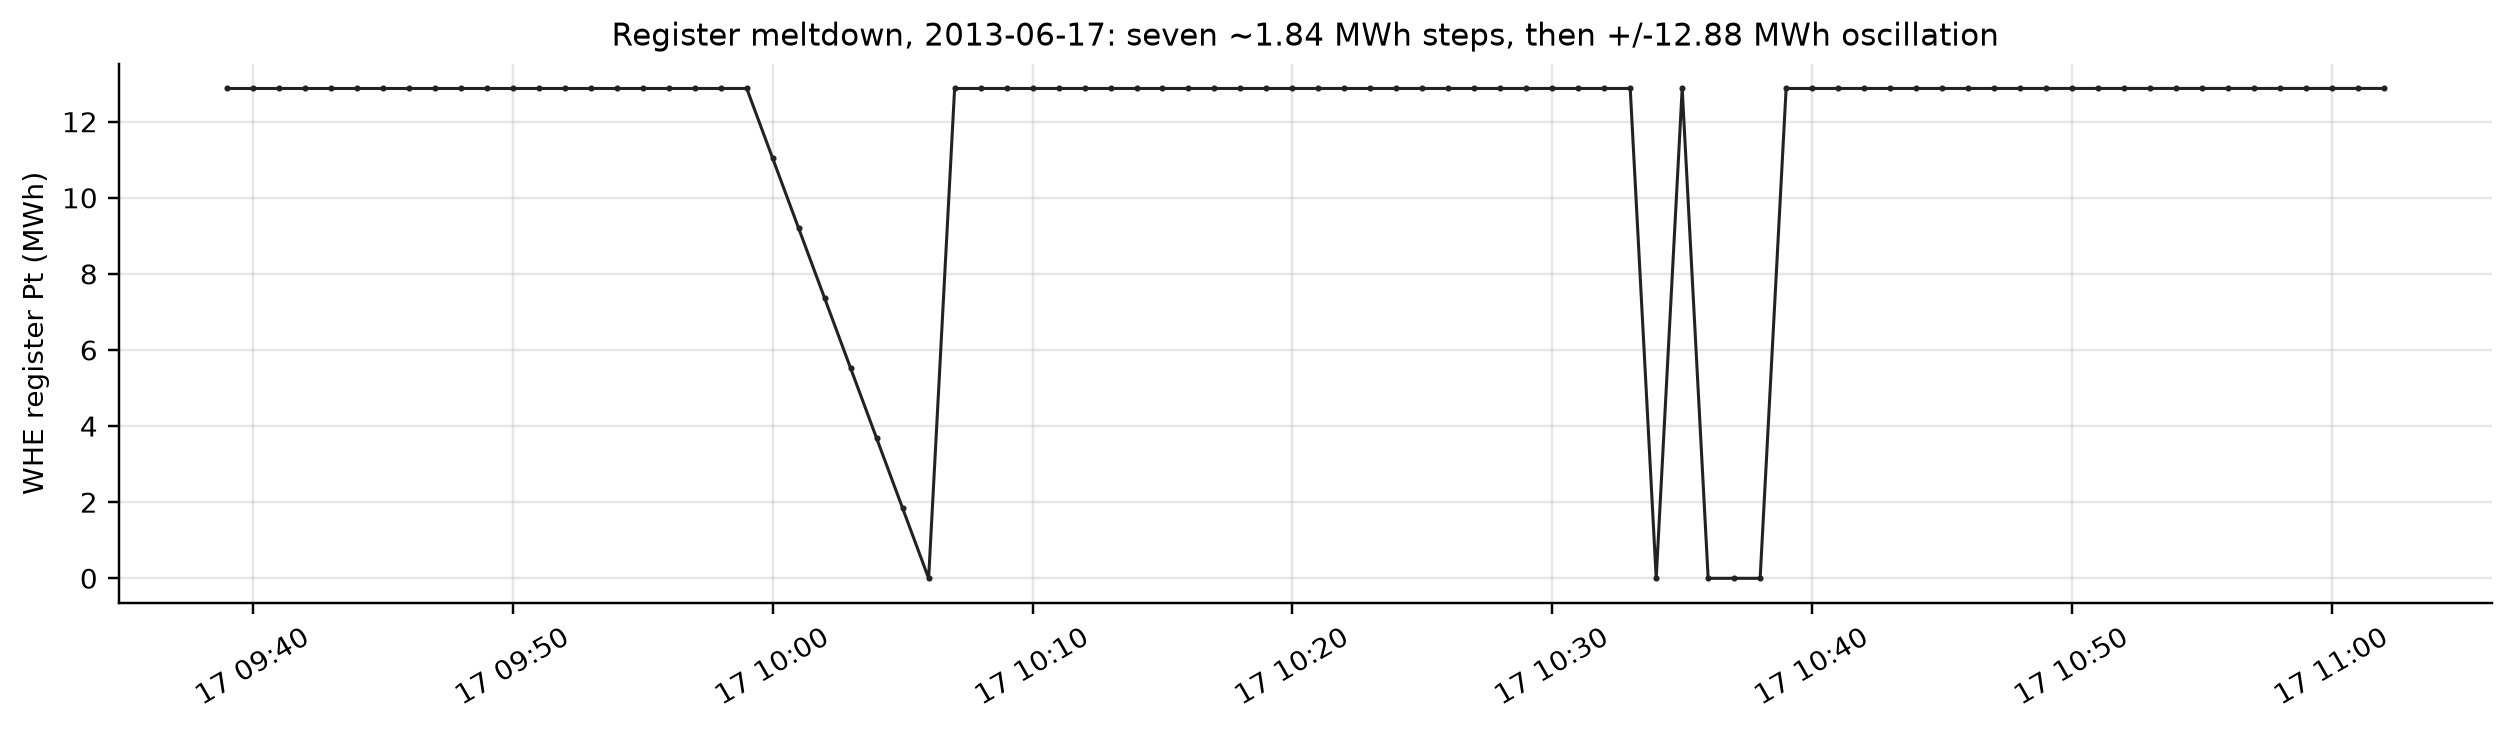

In [ ]:
neg = np.where(d < 0)[0]
print('negative register diffs: %d in 2 years' % len(neg))
n0 = neg[0]
print('first reset: minute %d, register %d -> %d, back to %d next minute' % (n0, Pt[n0], Pt[n0 + 1], Pt[n0 + 2]))
mel = np.where(np.abs(d) > 1000000.0)[0]
_big = mel[np.argmax(np.abs(d[mel]))]
grp = mel[np.abs(mel - _big) < 120]
m0, m1 = (grp.min(), grp.max())
drops = -d[grp][d[grp] < 0] / 1000000.0
print('meltdown drop sizes in Wh: %s' % sorted(set((int(-x) for x in d[grp][d[grp] < 0]))))
print('meltdown event: %d diffs >1 MWh, %s -> %s (%d min)' % (len(grp), IDX[m0 + 1], IDX[m1 + 1], m1 - m0))
print('meltdown drops: %d, sizes %s MWh (multiples to print precision - counter wrap)' % (len(drops), sorted(set(np.round(drops, 2)))))
naive_pos = float(d[d > 0].sum() / 1000)
span = float((Pt[-1] - Pt[0]) / 1000)
print('naive positive-diff sum: %.0f kWh vs true span %.0f kWh = %.2fx too much' % (naive_pos, span, naive_pos / span))
print('P-integral: %.0f kWh - matches span to %.2f%%' % ((Pw * 60 / 3600).sum() / 1000, 100 * abs(span - (Pw * 60 / 3600).sum() / 1000) / span))
_fig, _ax = plt.subplots(figsize=(11.5, 3.4))
m = m0 - 20
_ax.plot(IDX[m:m + (m1 - m0) + 45], Pt[m:m + (m1 - m0) + 45] / 1000000.0, color='#222222', lw=1.0, marker='.', ms=2)
_ax.set_ylabel('WHE register Pt (MWh)')
_ax.set_title('Register meltdown, %s: seven ~1.84 MWh steps, then +/-12.88 MWh oscillation' % IDX[m0 + 1].strftime('%Y-%m-%d'))
_ax.tick_params(axis='x', rotation=30)
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The meltdown panel is unambiguous: a register stepping down in seven ~1.84 MWh bites (1,839,357-1,839,358 Wh each), then oscillating between two states - every down-step a phantom loss, every snap-back fake energy. Read naively as consumption, the positive diffs add 60,032 kWh - **3.1x the true 19,480 kWh** of the whole two-year period. (The span still agrees with the P-integral to 0.04% because the register's *endpoints* are honest; it is the diffs that lie.)

This is the sharpest warning in the dataset: **cumulative registers are not a safer ground truth than power - they are a different failure surface.** Our gold layer must derive energy from P x dt and validate any register against it, never the reverse. [collectable] The failure mode itself (writes that tear mid-record under load) is [insight only] for our hardware, but Shelly's own energy counters deserve the same diff-audit before we ever trust their deltas.

## Q8 - Power quality for free: voltage, frequency, power factor

The per-circuit files carry V, f, DPF/APF on top of P. Three questions: how clean is the supply, what do the power factors tell us about load types, and - the one that pays for itself - **do the electrical identities hold per circuit?** Apparent power S should equal V x I on a single-leg metered circuit; on a two-leg 240 V circuit whose current column sums both legs, V x I double-counts. Our own pipeline derives per-circuit apparent power and PF exactly as V x I, so this check audits *our* feature, not just the release's.

In [ ]:
V = whe_file['V'].to_numpy().astype(np.float64)
fq = whe_file['f'].to_numpy().astype(np.float64)
print('WHE V: mean %.1f | p20 %.1f (heavy draw) | p99 %.1f (light load) | spread %.1f V' % (V.mean(), np.percentile(V, 20), np.percentile(V, 99), np.percentile(V, 99) - np.percentile(V, 20)))
fzero = int((fq == 0).sum())
print('WHE f: mean %.3f Hz | min %.1f Hz - %d zero-sentinel rows (excluded from the mean)' % (fq[fq > 0].mean(), fq.min(), fzero))
PASS['f_zero_rows'] = fzero
cd = pq.read_table(eda.fnd_file('ampds2', 'Electricity_CDE.parquet'))
cv = cd['V'].to_numpy().astype(np.float64)
cp = cd['P'].to_numpy().astype(np.float64)
_on = cp > 1000
_edges = np.diff(np.concatenate([[0], _on.astype(np.int8), [0]]))
st_onsets = np.where(_edges == 1)[0]
_en = np.where(_edges == -1)[0]
dvs = np.array([cv[e] - cv[e - 1] if e > 0 else 0.0 for e in st_onsets])
o_1 = np.argsort(dvs)
print('dryer onsets: %d | V-drop at onset p50 %.1f V, worst %.1f V' % (len(st_onsets), np.percentile(dvs, 50), dvs[o_1[0]]))
pfrows = []
for _c in ['FGE', 'CDE', 'CWE', 'DWE', 'WOE', 'HPE', 'FRE', 'TVE']:
    f2 = pq.read_table(eda.fnd_file('ampds2', 'Electricity_%s.parquet' % _c), columns=['P', 'APF', 'V'])
    p2 = f2['P'].to_numpy().astype(np.float64)
    a2 = f2['APF'].to_numpy().astype(np.float64)
    v2 = f2['V'].to_numpy().astype(np.float64)
    m2 = p2 > 0.2 * p2.max()
    pfrows.append((NAME[_c], round(float(a2[m2].mean()), 2), round(float(v2[v2 > 0].mean()), 1)))
idrows = []
for _c in ['RSE', 'WOE', 'CDE', 'GRE', 'HPE', 'EQE', 'HTE', 'UTE', 'FGE', 'FRE', 'DWE', 'BME', 'CWE', 'TVE', 'B2E', 'EBE', 'OFE', 'B1E']:
    f3 = pq.read_table(eda.fnd_file('ampds2', 'Electricity_%s.parquet' % _c), columns=['P', 'V', 'I', 'S', 'Q']).to_pandas()
    _on = f3['P'] > 50
    vi = f3['V'][_on] * f3['I'][_on]
    s = f3['S'][_on]
    _ok = s > 0
    dist = (f3['S'][_on] - np.sqrt(f3['P'][_on] ** 2 + f3['Q'][_on] ** 2)).abs() / s[_ok]
    idrows.append((NAME[_c], round(float(f3['V'][_on].median())), round(float((vi[_ok] / s[_ok]).median()), 2), round(float(((vi - s).abs()[_ok] / s[_ok]).median()), 3), round(float(dist.median()), 3)))
vi240 = [r[2] for r in idrows if r[1] > 200]
vi120 = [r[2] for r in idrows if r[1] < 200]
print('V*I / S on ~240 V circuits: %s (median %.2f - two-leg current double-counts)' % ([round(x, 2) for x in vi240], float(np.median(vi240))))
print('V*I / S on ~120 V circuits: median %.2f (identity holds)' % float(np.median(vi120)))
print('APF == P/S by definition (it cannot disagree with its inputs); DPF is a separate displacement-only')
print('column, constant 1.000 on most circuits and 0.00 on EQE/UTE/OUE - derived or default-filled, use with care.')
PASS['vi_ratio_240'] = round(float(np.median(vi240)), 2)
PASS['vi_ratio_120'] = round(float(np.median(vi120)), 2)
mo.md(eda.md_table(['circuit', 'APF at ON (mean)', 'V when drawing'], pfrows) + "\n\n" + eda.md_table(['circuit', 'V med', 'med(V*I/S)', 'med|V*I-S|/S', 'med|S-sqrt(P2+Q2)|/S'], idrows))

WHE V: mean 240.3 | p20 238.1 (heavy draw) | p99 246.6 (light load) | spread 8.5 V
WHE f: mean 60.005 Hz | min 0.0 Hz - 6 zero-sentinel rows (excluded from the mean)
dryer onsets: 1498 | V-drop at onset p50 -1.6 V, worst -4.5 V
V*I / S on ~240 V circuits: [1.96, 2.08, 1.99, 1.91, 1.99] (median 1.99 - two-leg current double-counts)
V*I / S on ~120 V circuits: median 0.96 (identity holds)
APF == P/S by definition (it cannot disagree with its inputs); DPF is a separate displacement-only
column, constant 1.000 on most circuits and 0.00 on EQE/UTE/OUE - derived or default-filled, use with care.


| circuit | APF at ON (mean) | V when drawing |
| --- | --- | --- |
| Fridge (FGE) | 0.98 | 120.5 |
| Clothes dryer (CDE) | 0.99 | 241.9 |
| Clothes washer (CWE) | 0.7 | 120.5 |
| Dishwasher (DWE) | 1.0 | 120.9 |
| Wall oven (WOE) | 1.0 | 240.9 |
| Heat pump (HPE) | 0.97 | 239.6 |
| Furnace fan (FRE) | 0.69 | 120.3 |
| Entertainment (TVE) | 0.93 | 120.2 |

| circuit | V med | med(V*I/S) | med\|V*I-S\|/S | med\|S-sqrt(P2+Q2)\|/S |
| --- | --- | --- | --- | --- |
| Rental suite (RSE) | 242 | 1.96 | 0.964 | 0.112 |
| Wall oven (WOE) | 240 | 2.08 | 1.08 | 0.008 |
| Clothes dryer (CDE) | 240 | 1.99 | 0.992 | 0.003 |
| Garage sub-panel (GRE) | 239 | 1.91 | 0.912 | 0.242 |
| Heat pump (HPE) | 238 | 1.99 | 0.99 | 0.007 |
| Security/network (EQE) | 122 | 0.91 | 0.086 | 0.227 |
| Instant hot water unit (HTE) | 121 | 0.91 | 0.1 | 0.21 |
| Utility plug (UTE) | 120 | 0.95 | 0.053 | 0.288 |
| Fridge (FGE) | 120 | 0.96 | 0.043 | 0.013 |
| Furnace fan (FRE) | 120 | 0.97 | 0.035 | 0.306 |
| Dishwasher (DWE) | 120 | 0.99 | 0.008 | 0.005 |
| Basement plugs (BME) | 120 | 0.98 | 0.017 | 0.018 |
| Clothes washer (CWE) | 120 | 0.99 | 0.053 | 0.303 |
| Entertainment (TVE) | 120 | 0.97 | 0.028 | 0.067 |
| S bedroom plugs (B2E) | 120 | 0.93 | 0.071 | 0.014 |
| Workbench (EBE) | 120 | 0.93 | 0.072 | 0.064 |
| Home office (OFE) | 120 | 0.95 | 0.053 | 0.074 |
| N bedroom plugs (B1E) | 119 | 0.98 | 0.019 | 0.003 |

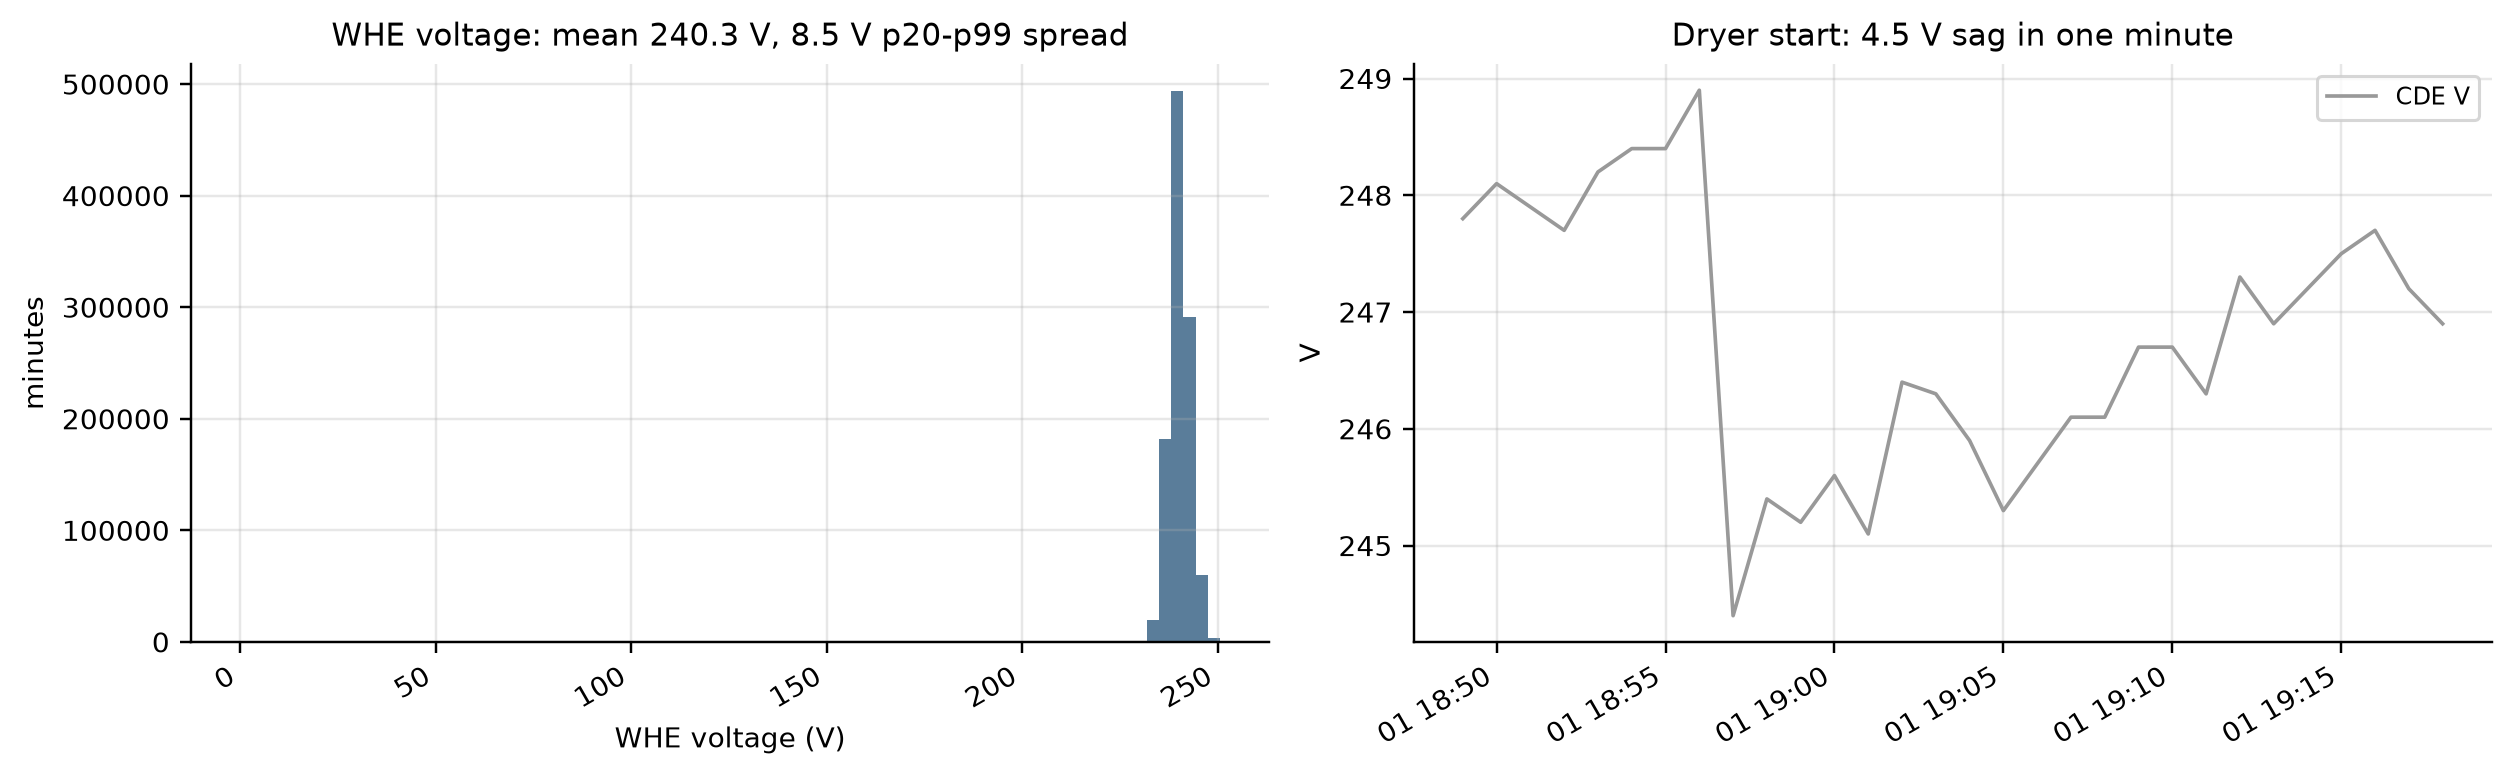

In [ ]:
_fig, _axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
_ax = _axes[0]
_ax.hist(V, bins=80, color='#5a7d9a')
_ax.set_xlabel('WHE voltage (V)')
_ax.set_ylabel('minutes')
_ax.set_title('WHE voltage: mean %.1f V, %.1f V p20-p99 spread' % (V.mean(), np.percentile(V, 99) - np.percentile(V, 20)))
_ax = _axes[1]
zs = st_onsets[o_1[0]] - 8
_ax.plot(IDX[zs:zs + 30], cv[zs:zs + 30], color='#999999', lw=1.2, label='CDE V')
_ax.set_ylabel('V')
_ax.set_title('Dryer start: %.1f V sag in one minute' % -dvs[o_1[0]])
_ax.legend(fontsize=8)
_fig.autofmt_xdate()
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** Three findings:

- **The service is healthy and North American.** 240 V nominal, mean 240.3 V at the whole-house meter, with an 8.5 V spread: it sags to ~238 V under heavy draw (p20) and rises toward ~247 V on light-load nights (p99) - the classic residential voltage-load dance, and exactly what a voltage-sensing CT set will see. Frequency pins 60.005 Hz once the zero-sentinel rows are excluded: the grid, not the house, sets it. (V/f/PF columns are zero-padded when a circuit idles - valid only during draw.)

- **Power factor splits the panel into motors and heaters.** The resistive 240 V appliances sit at unity (dryer 0.99, oven 1.00, dishwasher heater 1.00); the motors sag: washer 0.70, furnace fan 0.69, heat pump 0.97 (inverter-assisted), fridge 0.98. (APF here is P/S by definition - it cannot disagree with its inputs; the independent check is the identities table below.) The load-type split (motor vs resistive) is exactly what the gold layer's appliance taxonomy should encode. [collectable]

- **The pipeline-relevant finding: V x I is ~2.0x S on every ~240 V circuit.** The release's current column sums both legs, so V x I double-counts apparent power, while on the ~120 V circuits it sits at ~0.95-1.0. Our pipeline derives per-circuit apparent power and PF as V x I - correct on 120 V single-leg channels, **silently wrong by ~2x on any two-leg 240 V circuit**. AMPds2 is the test fixture for that bug: audit calculated_apparent_power_VA / calculated_power_factor on a 240 V circuit before trusting them.

- **Voltage sags with every big start.** The median dryer onset costs 1.6 V and the worst single events reach ~4.5 V (dryer and heat pump alike) - small, but a real, repeatable fingerprint of inrush at the panel.

## Q9 - The signature gallery: twelve circuits at 60 s

The heart of the EDA: what does each circuit's power trace actually look like at one-minute resolution? Selection rule, stated up front: each panel shows the **highest-energy 6-hour window that still contains at least 5% OFF minutes** - a max-demand window, not a typical one. Shapes are read from it; duty and energy statistics come from the full two years. For a rarely-off circuit the filter can be unsatisfiable, and the plain highest-energy window (all ON) is shown instead. Canonical appliances first, then the house-scale loads.

Fridge (FGE) - the 20-55% duty sawtooth
Clothes washer (CWE) - programme blocks
Dishwasher (DWE) - heater + motor phases
Clothes dryer (CDE) - the 240 V mega-load
Wall oven (WOE) - resistive plateaus
Entertainment (TVE) - TV/PVR/amp



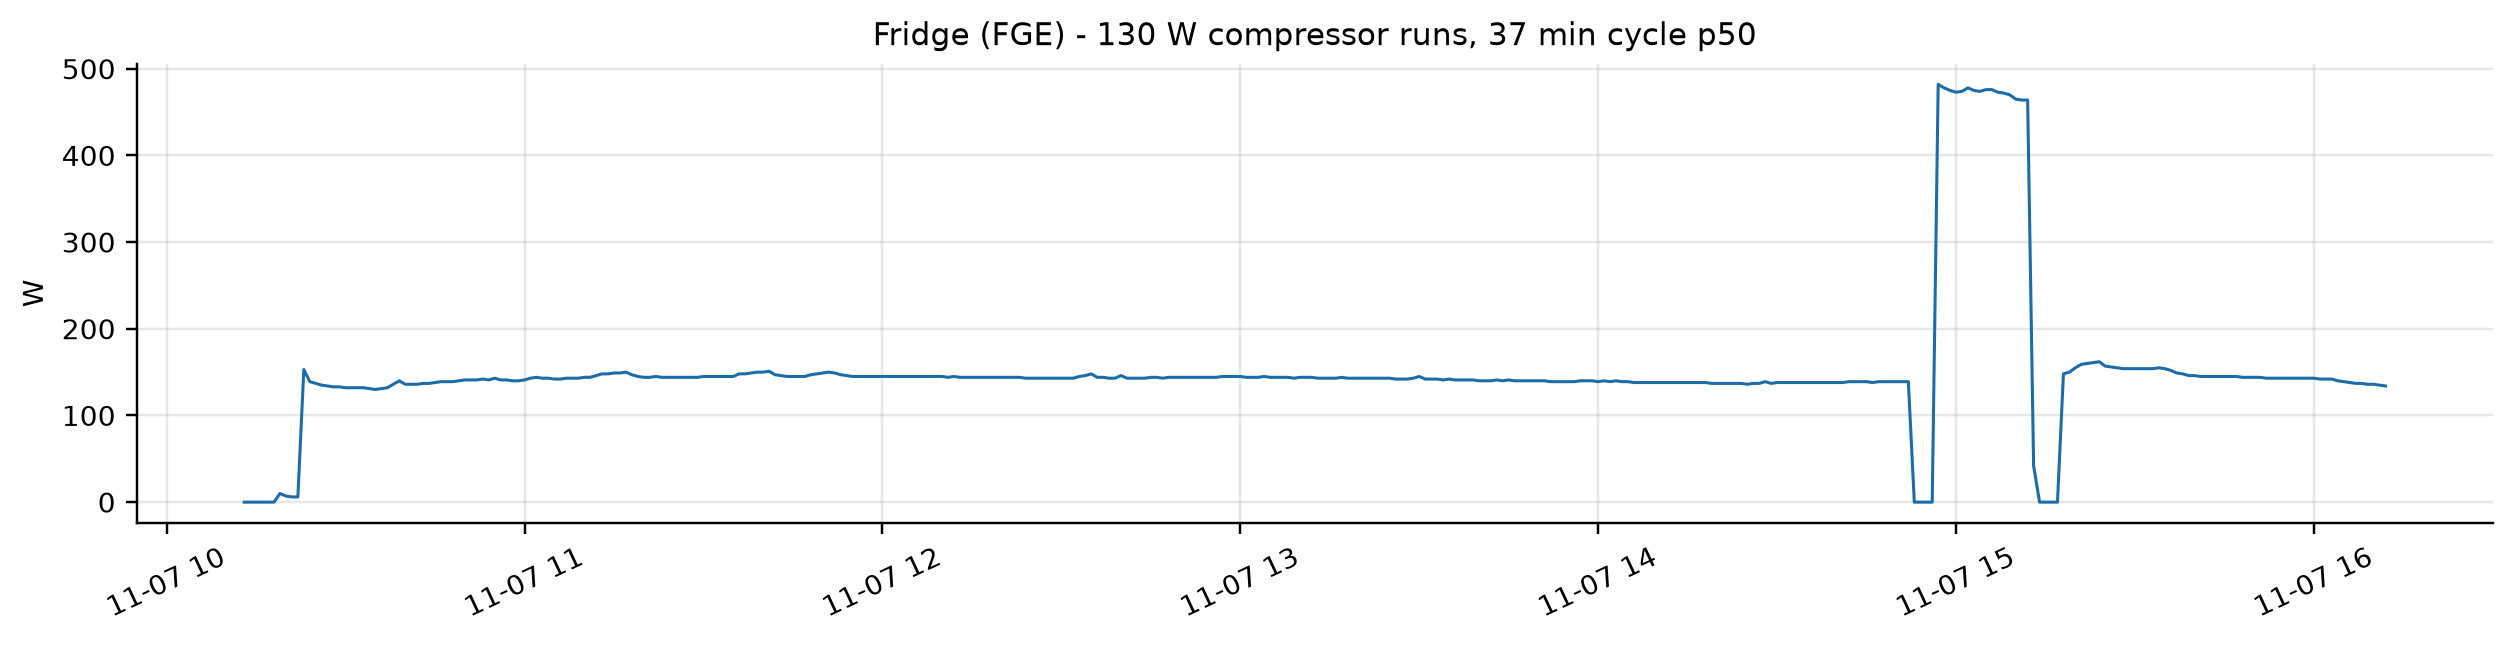
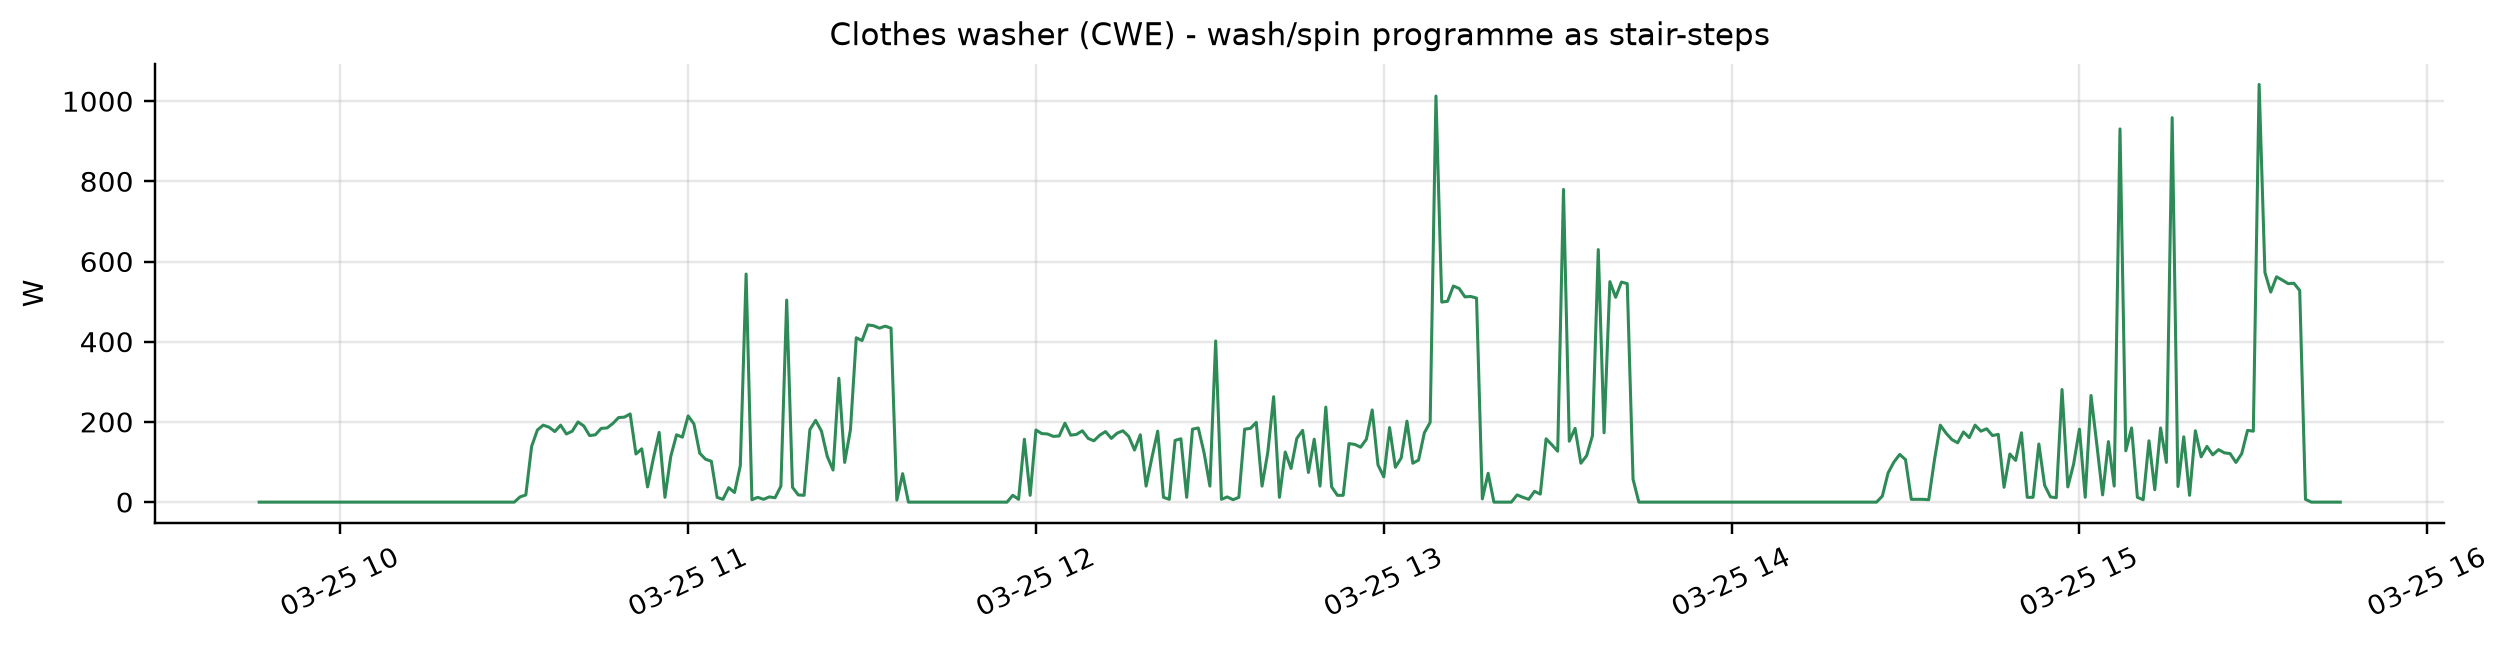
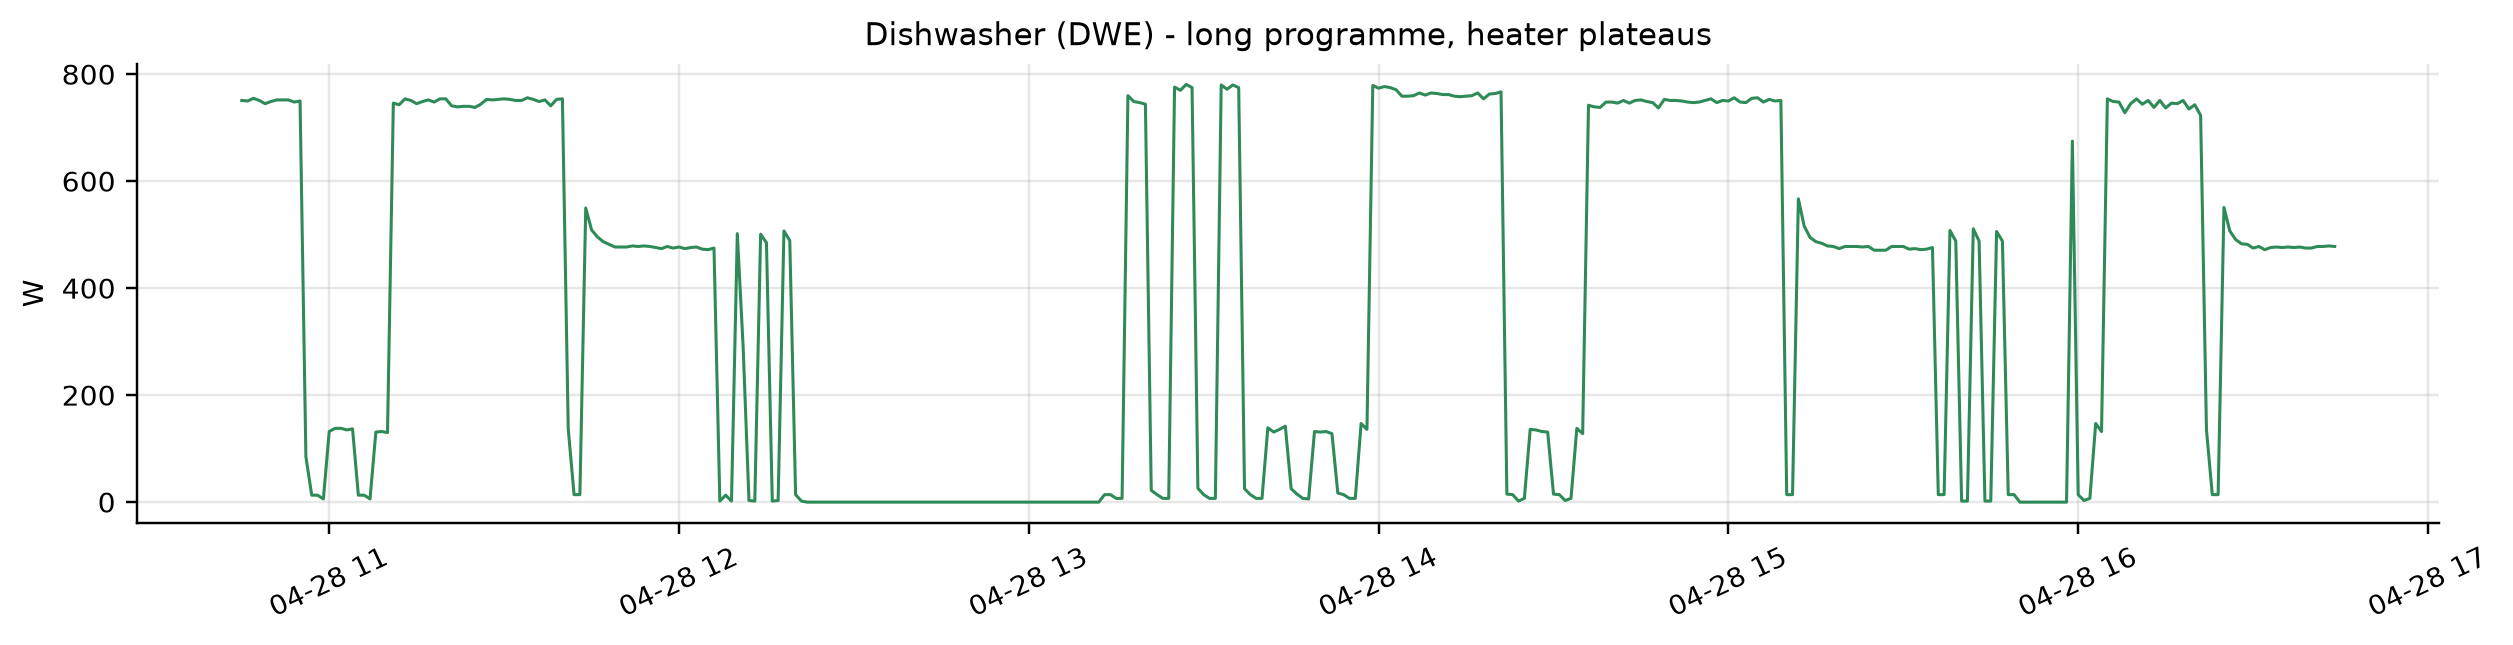
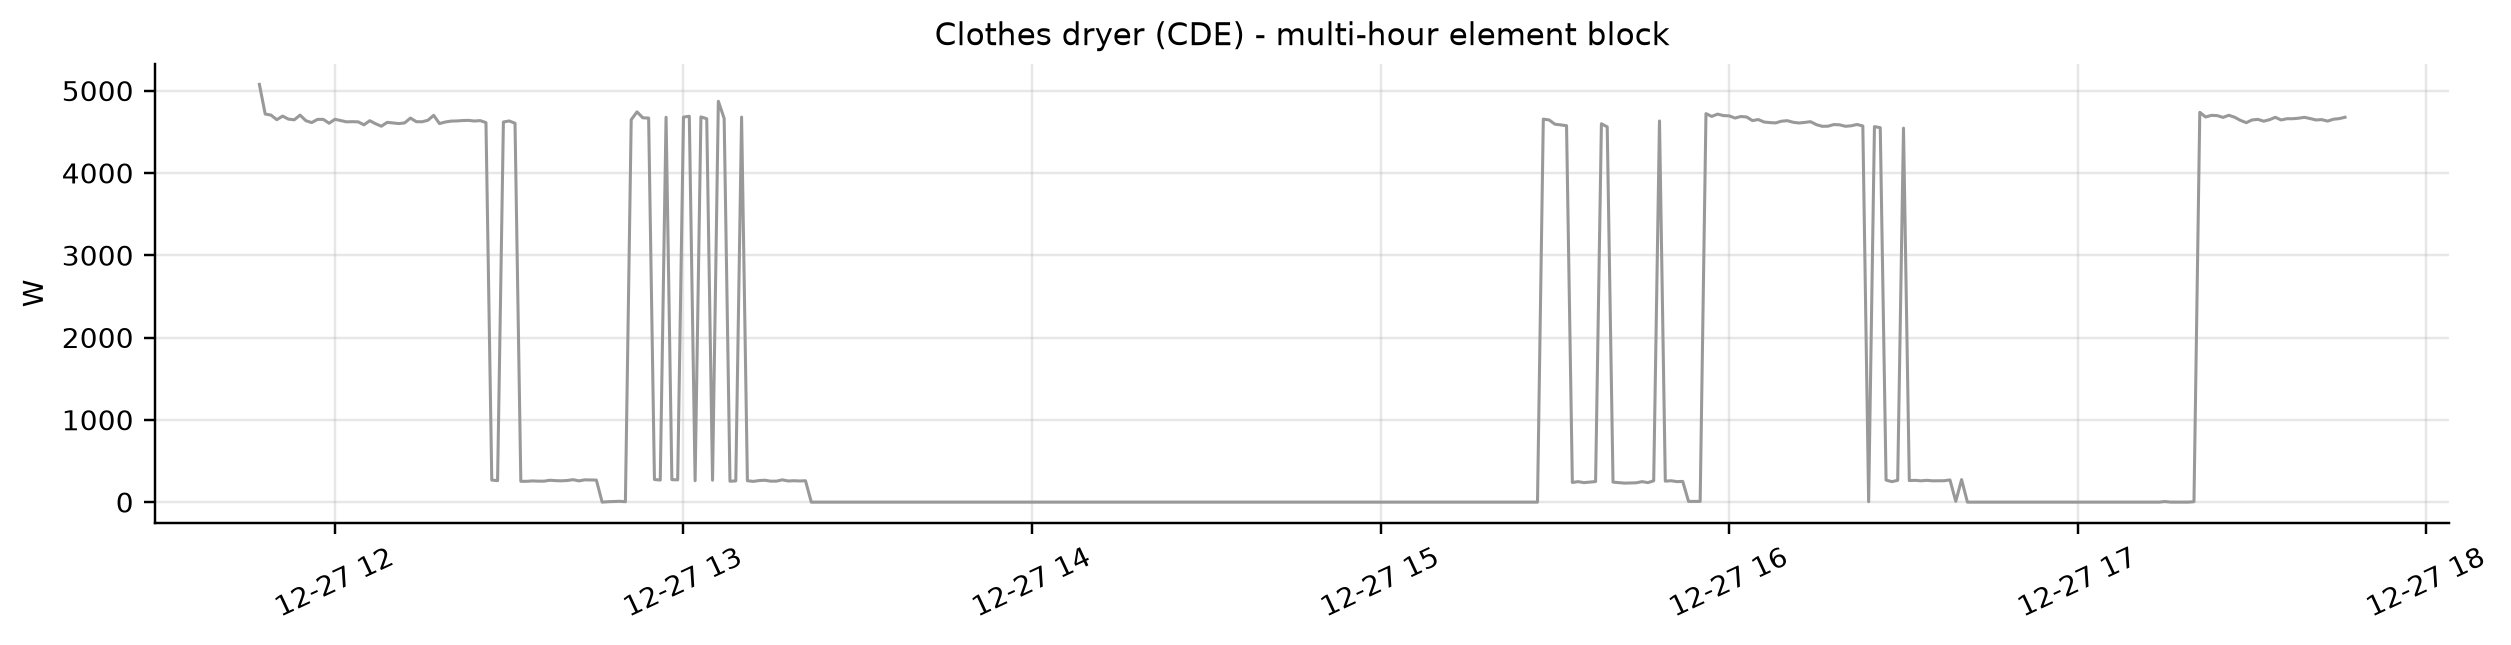
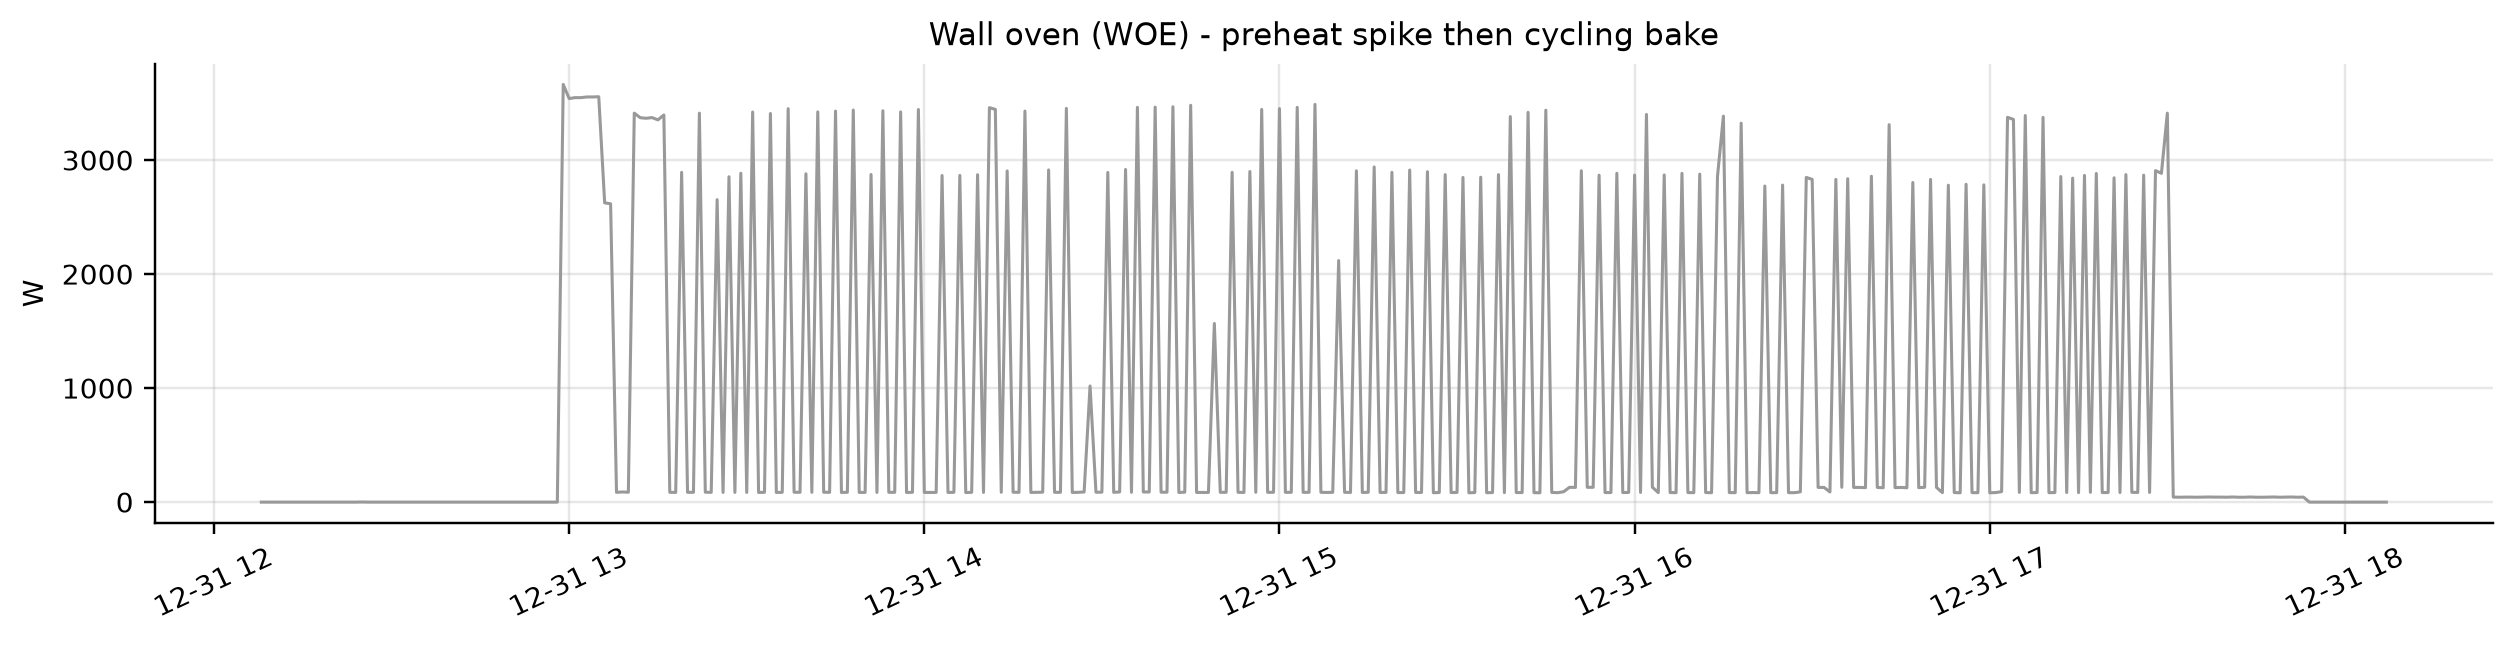
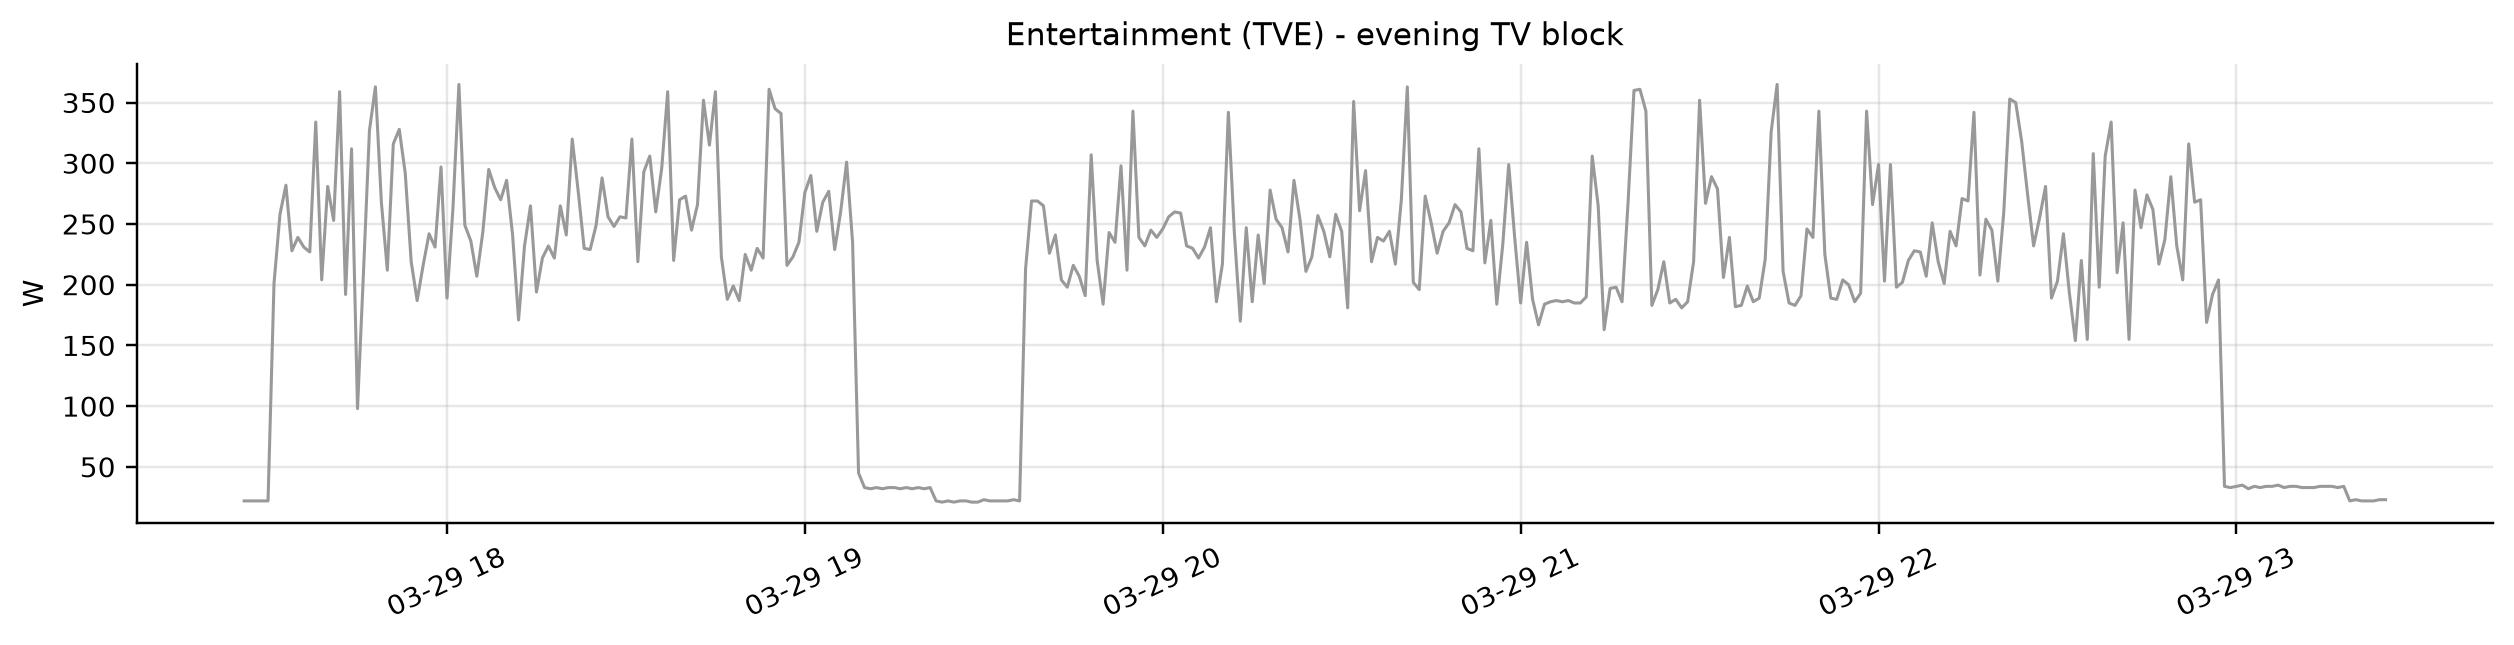

In [ ]:
def best_window(v, hours=6, thr=None, frac_on=0.05):
    w = hours * 60
    on = v > (thr if thr is not None else max(1.0, 0.02 * v.max()))
    c = np.cumsum(np.concatenate([[0], on.astype(np.int8)]))
    s = np.cumsum(np.concatenate([[0], v]))
    sums = (s[w:] - s[:-w])
    ons = (c[w:] - c[:-w])
    cand = np.argsort(-sums)[:300]
    for k in cand:
        k = int(k)
        if (ons[k] / w) <= (1 - frac_on):
            return k
    return int(cand[0])

def gallery(v, hours=6, color='#1b6ca8', title='', ylabel='W'):
    k = best_window(v, hours=hours)
    sl = slice(k, k + hours * 60)
    fig, ax = plt.subplots(figsize=(11.5, 3.0))
    ax.plot(IDX[sl], v[sl], color=color, lw=1.0)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=25)
    fig.tight_layout()
    return fig

_figs = []
print(NAME['FGE'] + ' - the 20-55% duty sawtooth')
_figs.append(gallery(P['FGE'], color='#1b6ca8', title='Fridge (FGE) - 130 W compressor runs, 37 min cycle p50'))
print(NAME['CWE'] + ' - programme blocks')
_figs.append(gallery(P['CWE'], color='#2e8b57', title='Clothes washer (CWE) - wash/spin programme as stair-steps'))
print(NAME['DWE'] + ' - heater + motor phases')
_figs.append(gallery(P['DWE'], color='#2e8b57', title='Dishwasher (DWE) - long programme, heater plateaus'))
print(NAME['CDE'] + ' - the 240 V mega-load')
_figs.append(gallery(P['CDE'], color='#999999', title='Clothes dryer (CDE) - multi-hour element block'))
print(NAME['WOE'] + ' - resistive plateaus')
_figs.append(gallery(P['WOE'], color='#999999', title='Wall oven (WOE) - preheat spike then cycling bake'))
print(NAME['TVE'] + ' - TV/PVR/amp')
_figs.append(gallery(P['TVE'], color='#999999', title='Entertainment (TVE) - evening TV block'))
mo.vstack(_figs)  # render figure as cell output

**Reading it.** The canonical four all keep their textbook shapes at 60 s:

- **FGE** shows the compressor sawtooth - regular ~10-minute ~130 W runs with defrost spikes - the duty-cycle anchor our gold layer calibrates on.

- **CWE** resolves as a staircase of programme phases (fill, wash, drain, spin) stretched over an hour: at 1 s we saw spin bursts; at 60 s the *phases* survive even though the micro-cycles do not.

- **DWE** is a multi-hour programme with heater plateaus poking through a motor base.

- **CDE** is simply *on* - a multi-kilowatt block for the whole programme. All its sub-minute element cycling is gone; what remains is exactly what a 60 s deployment can measure: programme start, programme end, total energy.

- **WOE/TVE** are occupancy proxies: resistive oven plateaus around meal times, an evening TV block with PVR spikes - shapes the suite comparison in Q10 will echo.

One reading aid: every panel above is a max-demand window (the stated selection rule), so treat absolute levels as ceilings - the typical day is flatter, as Q10's mean-day profiles show; the shapes are the takeaway.

Heat pump (HPE) - the 3.0x seasonal load
Furnace fan (FRE)
Basement plugs (BME)
Outside plugs (OUE)
Utility plug (UTE)
Security/network (EQE)



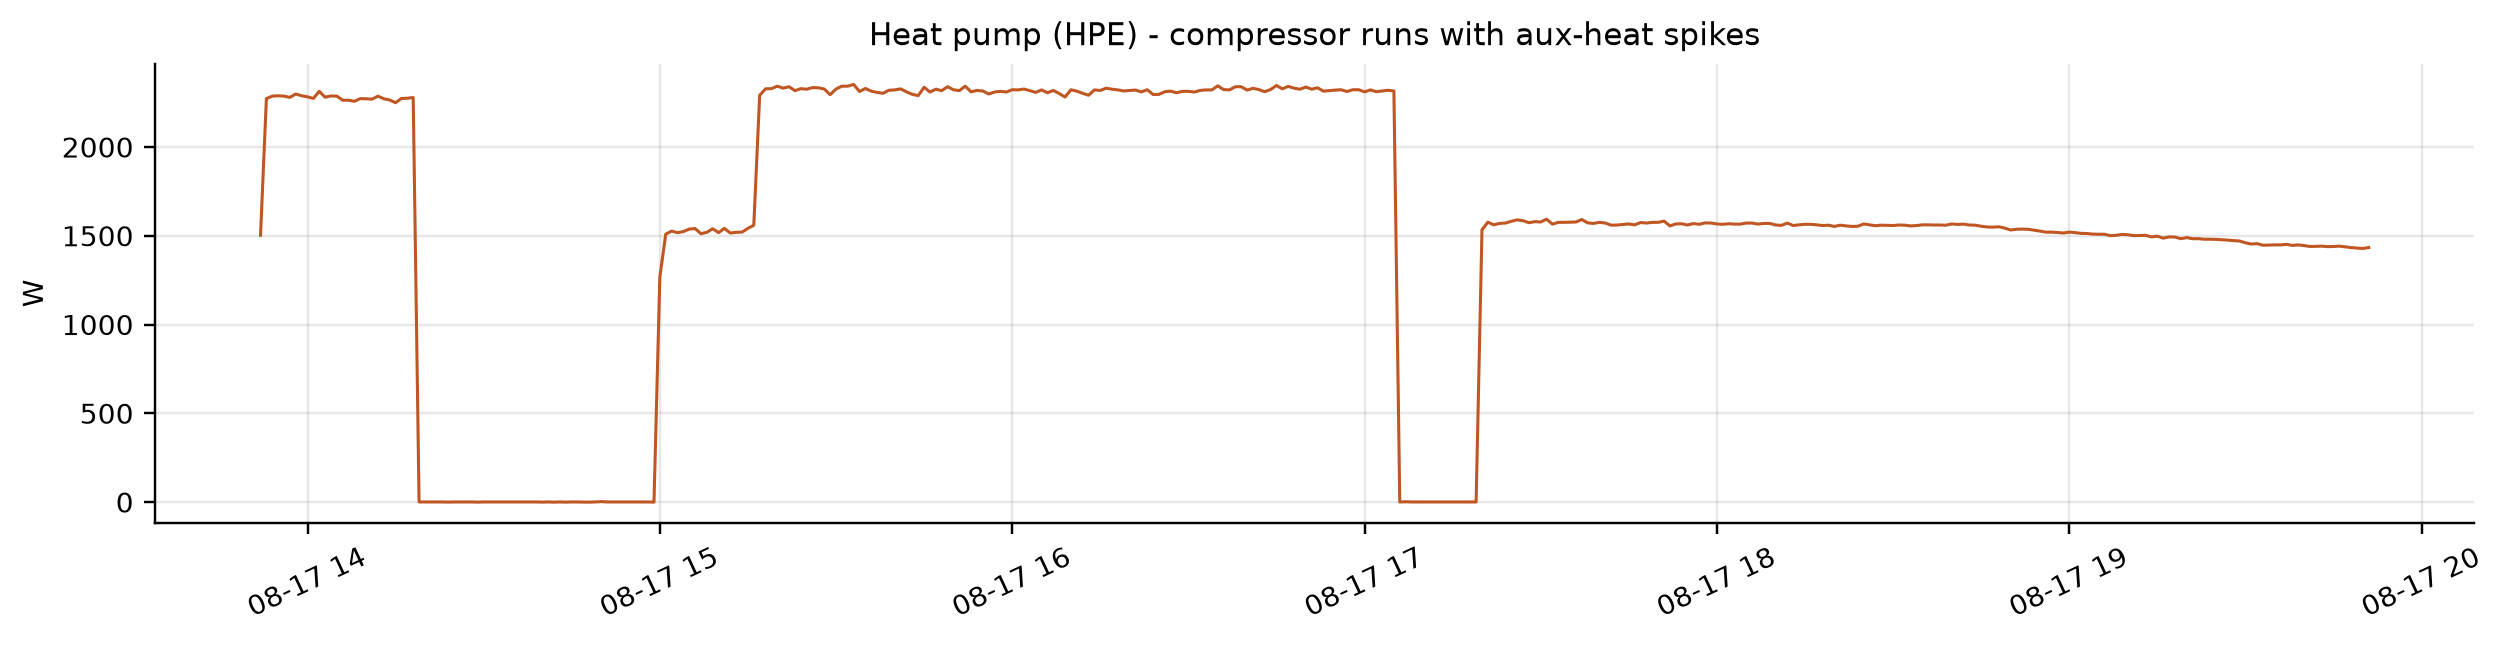
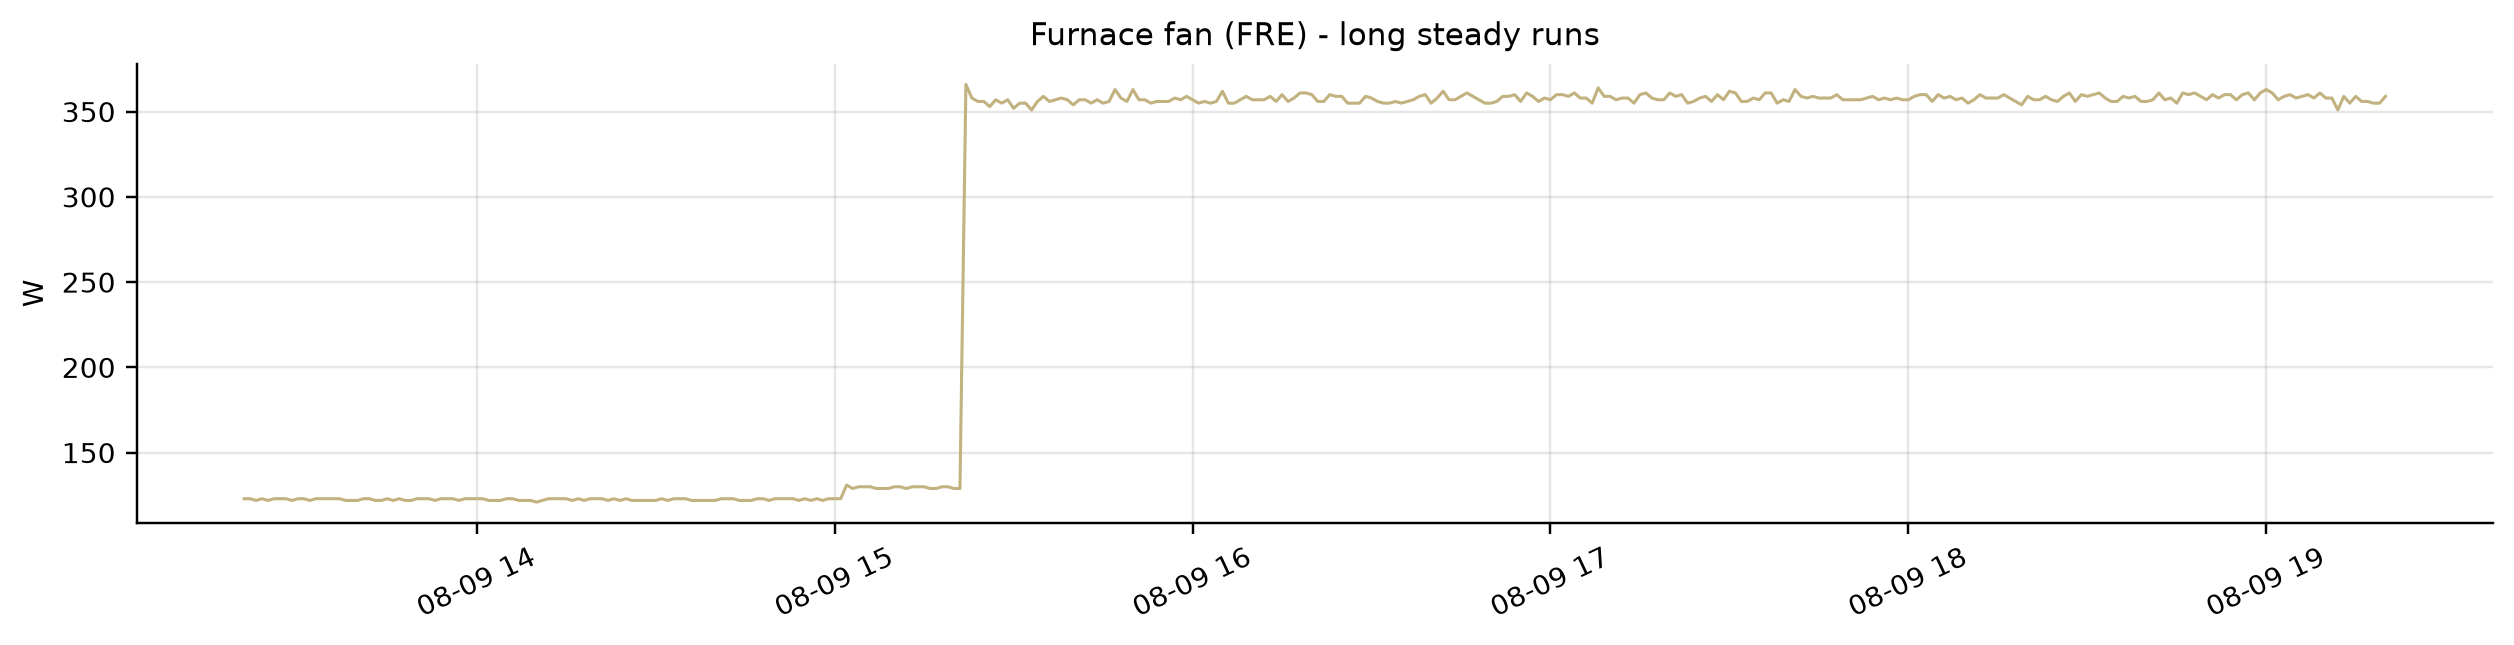
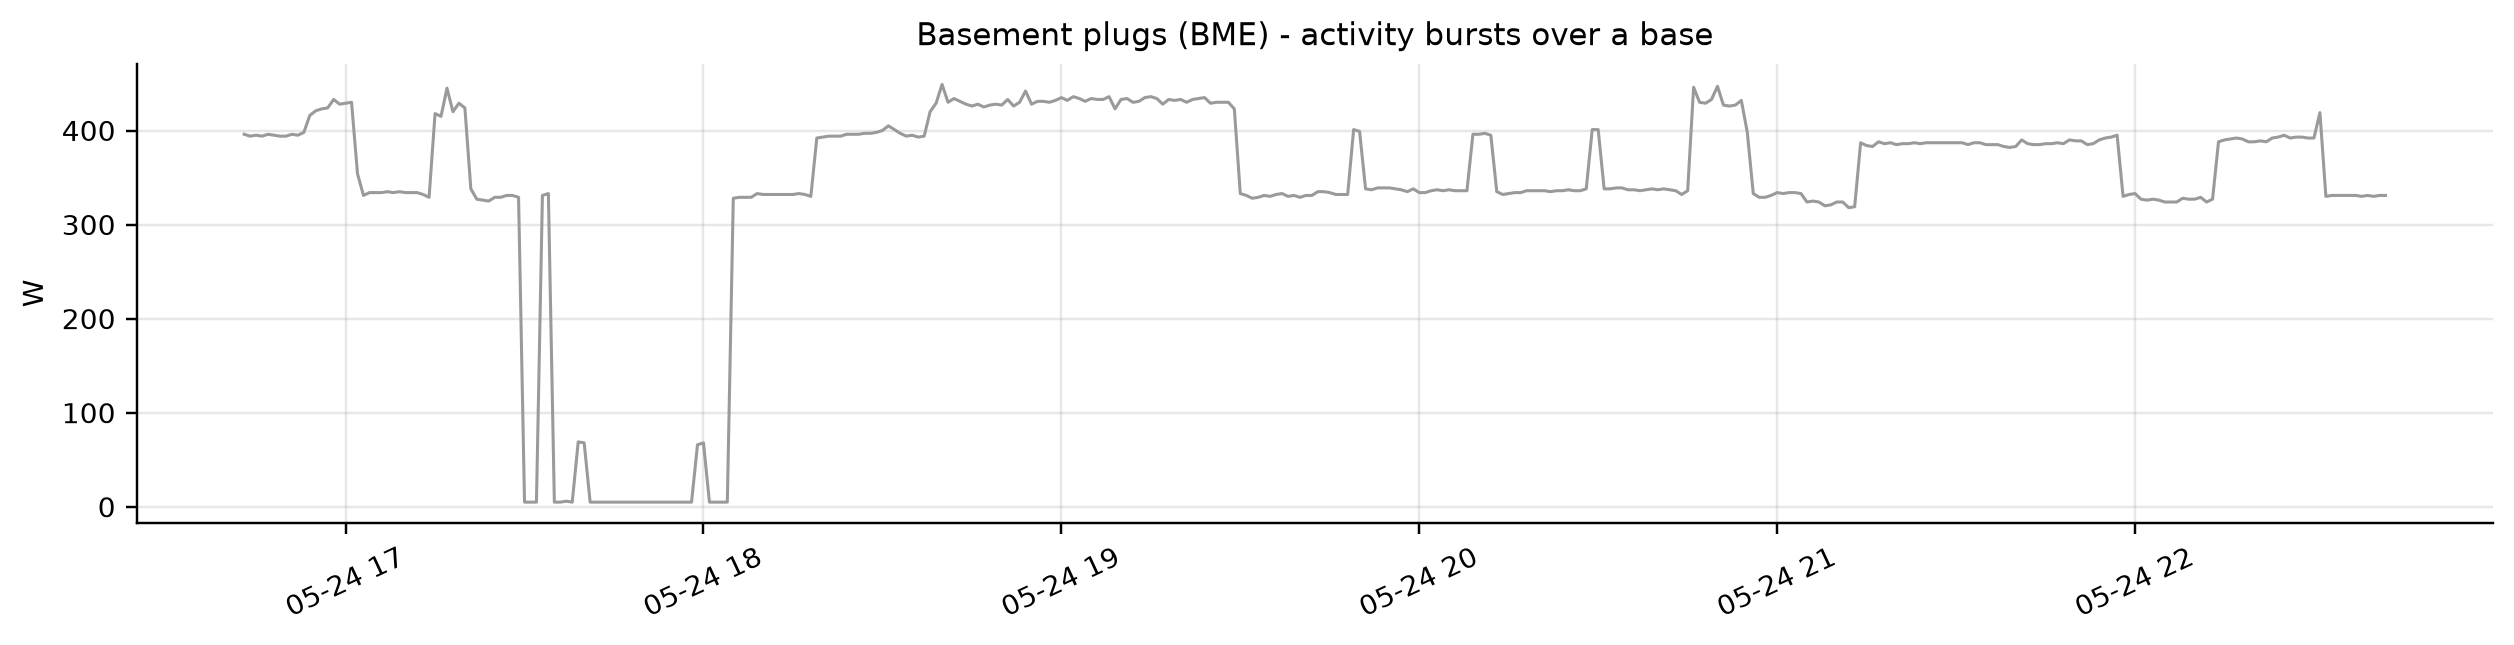
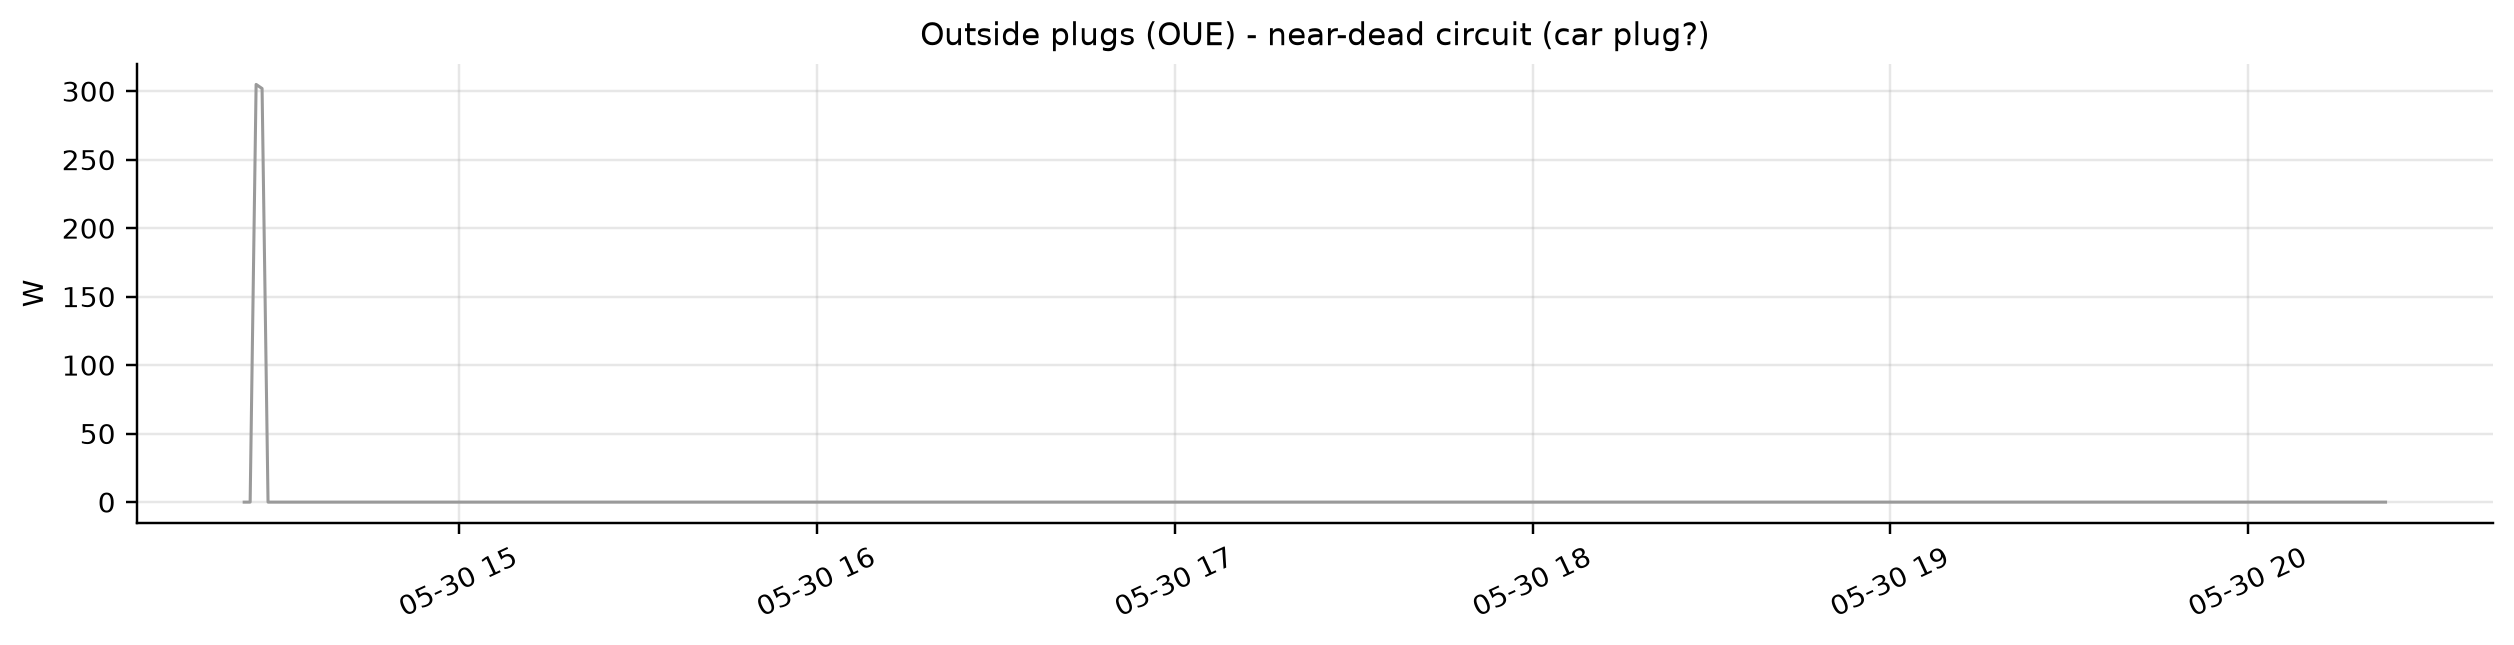
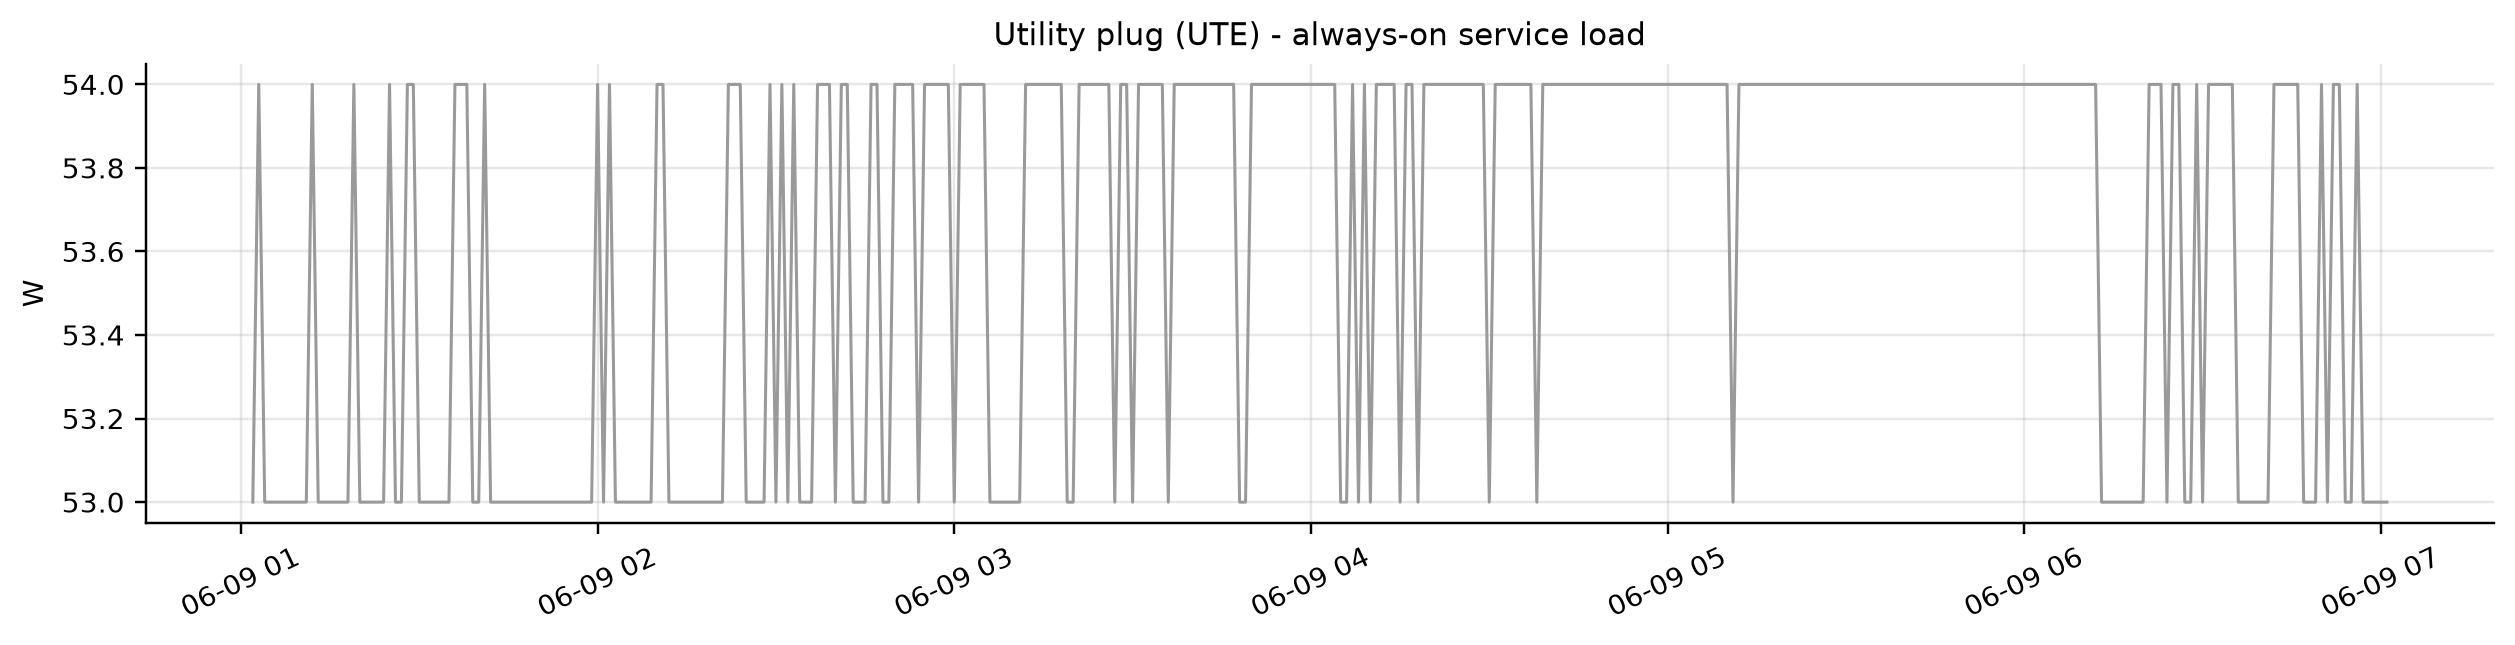
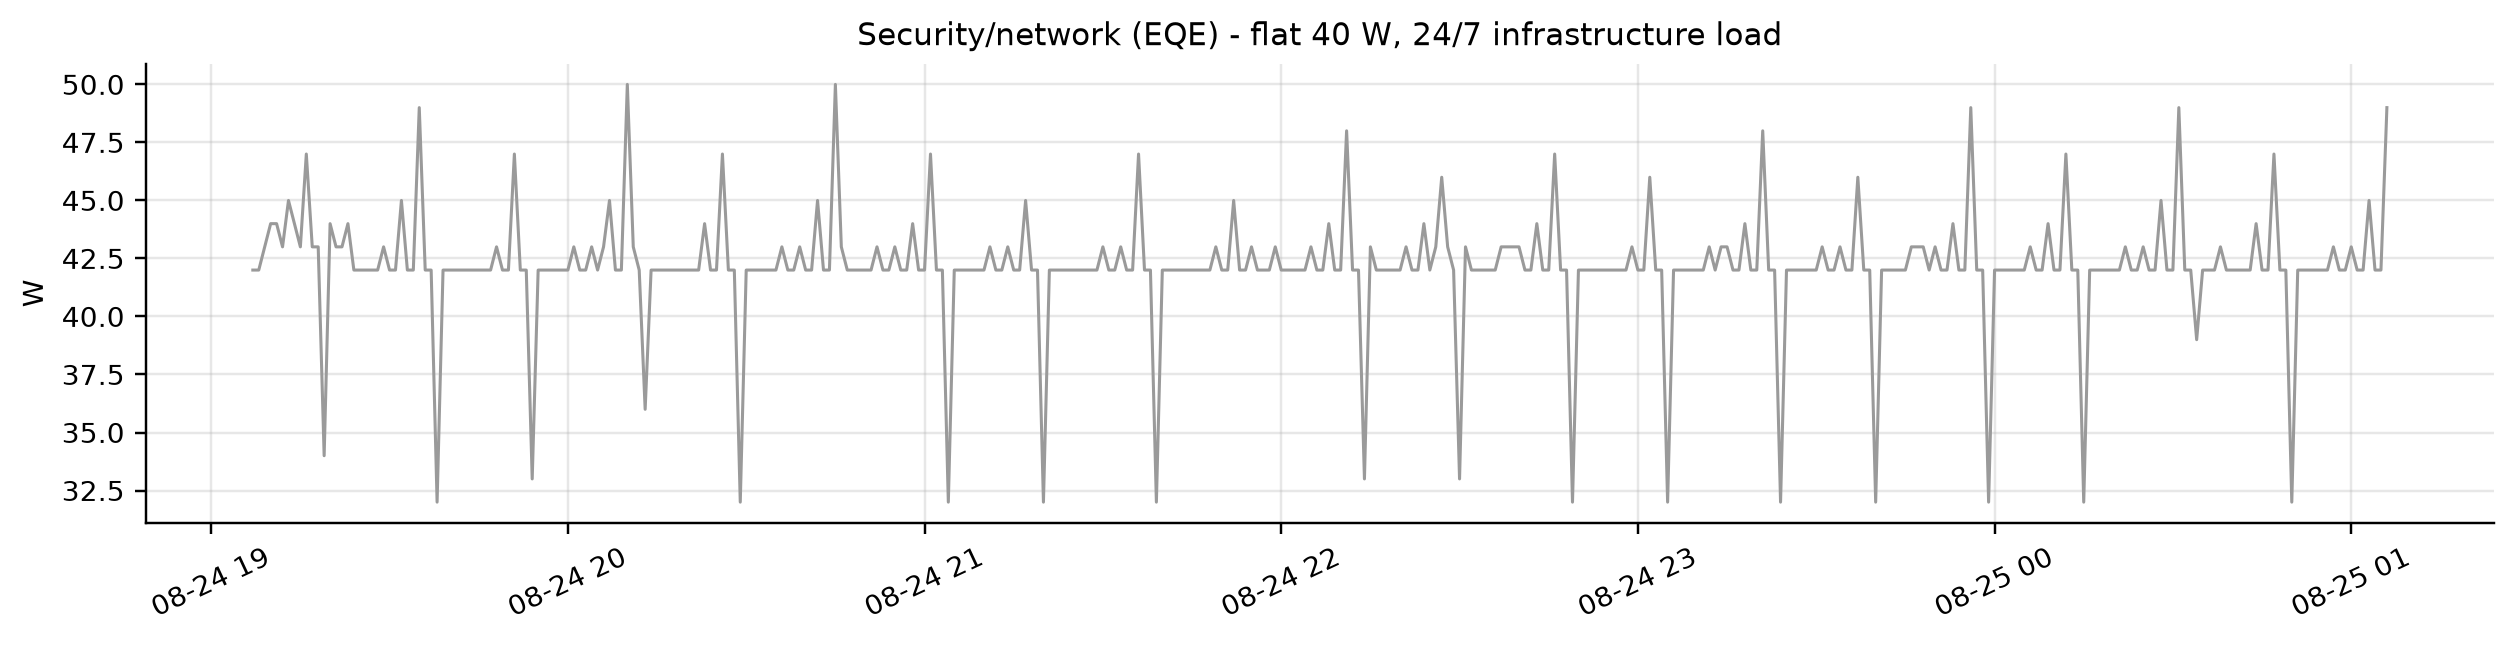

In [ ]:
_figs = []
print(NAME['HPE'] + ' - the 3.0x seasonal load')
_figs.append(gallery(P['HPE'], color='#c05621', title='Heat pump (HPE) - compressor runs with aux-heat spikes'))
print(NAME['FRE'])
_figs.append(gallery(P['FRE'], color='#c2b280', title='Furnace fan (FRE) - long steady runs'))
print(NAME['BME'])
_figs.append(gallery(P['BME'], color='#9a9a9a', title='Basement plugs (BME) - activity bursts over a base'))
print(NAME['OUE'])
_figs.append(gallery(P['OUE'], color='#9a9a9a', title='Outside plugs (OUE) - near-dead circuit (car plug?)'))
print(NAME['UTE'])
_figs.append(gallery(P['UTE'], color='#9a9a9a', title='Utility plug (UTE) - always-on service load'))
print(NAME['EQE'])
_figs.append(gallery(P['EQE'], color='#9a9a9a', title='Security/network (EQE) - flat 40 W, 24/7 infrastructure load'))
mo.vstack(_figs)

**Reading it.** The house-scale loads fill in the taxonomy:

- **HPE** (3.0x winter swing) runs as hour-plus compressor blocks with occasional higher aux-heat spikes - at 60 s the run *structure* is intact, which is what matters for heating-vs-appliance separation.

- **FRE** is a duty-cycle load like the fridge but at 110 W and human-scheduled: long steady runs whenever the gas furnace calls for heat.

- **BME/UTE/OUE** are plug circuits: activity bursts over small bases. OUE is essentially a dead port (0 kWh) - worth flagging for the gold layer as "wire present, nothing to model".

- **EQE** is the always-on infrastructure floor: 40 W flat, 24/7, ~700 kWh over the two years. In our deployment this is the class of loads (routers, security, servers) that will sit under every home's trace - and AMPds2 attributes it, where REFIT's residual hid it.

Rental suite (RSE) - the second household (Q10 preview)
Unmetered (UNE) - bursts and base (Q6 deep-dive)
Instant hot water unit (HTE) - the mislabelled instant hot water unit



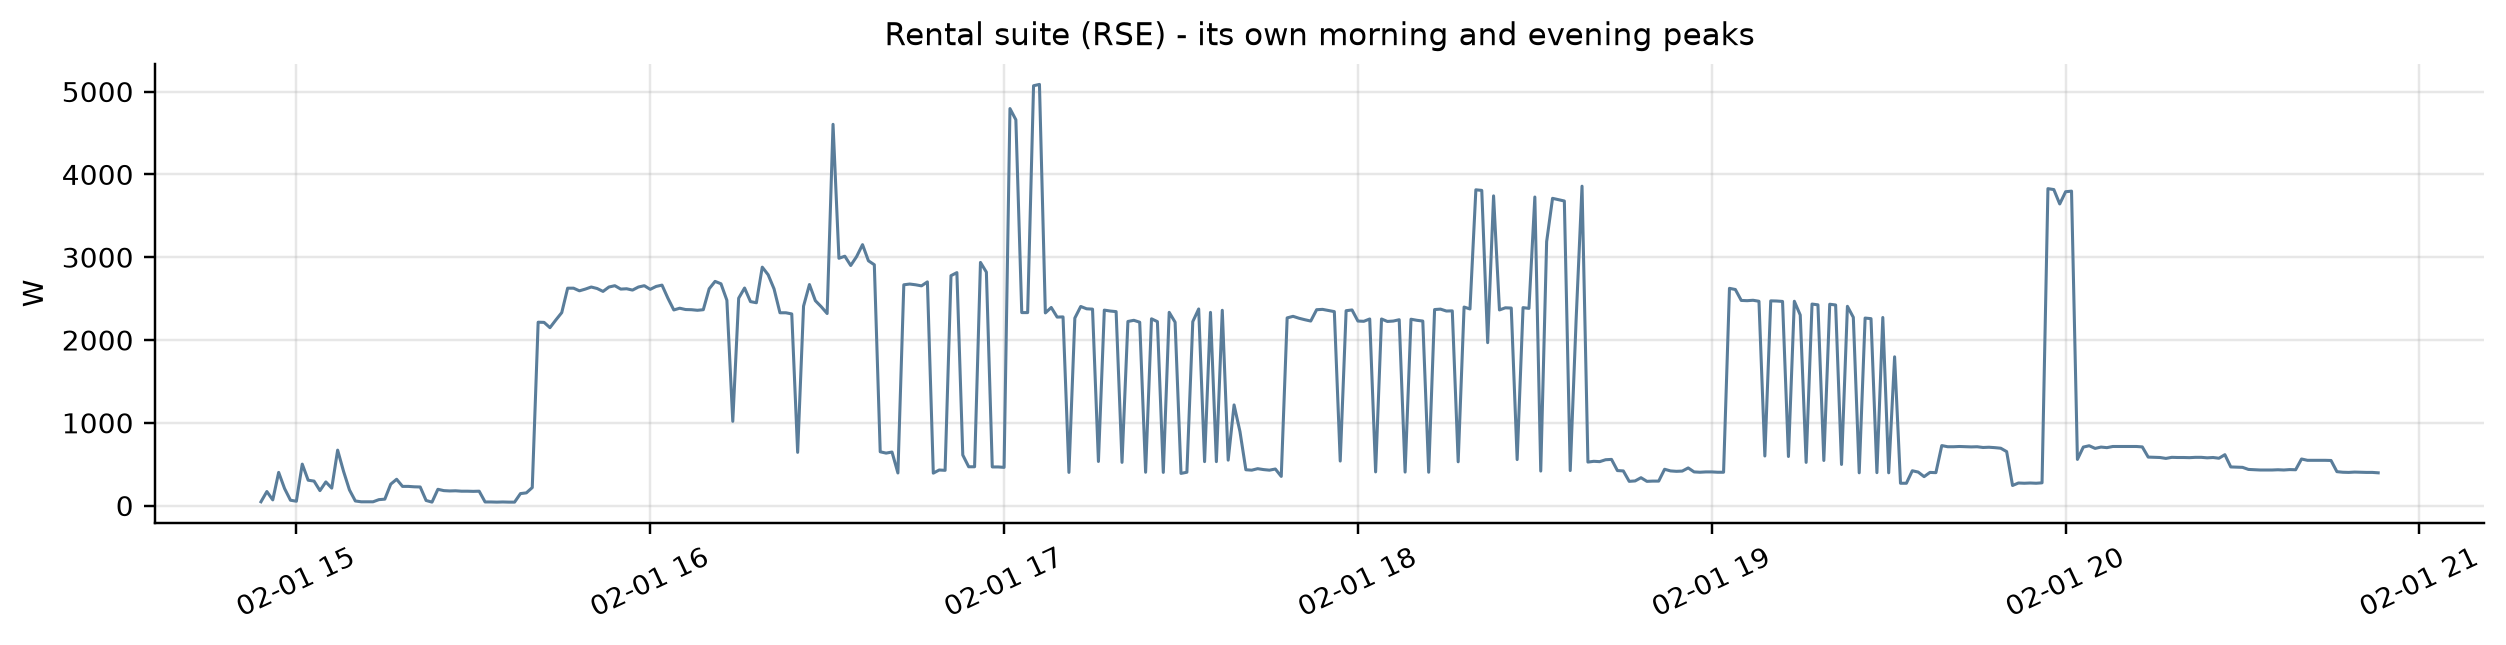
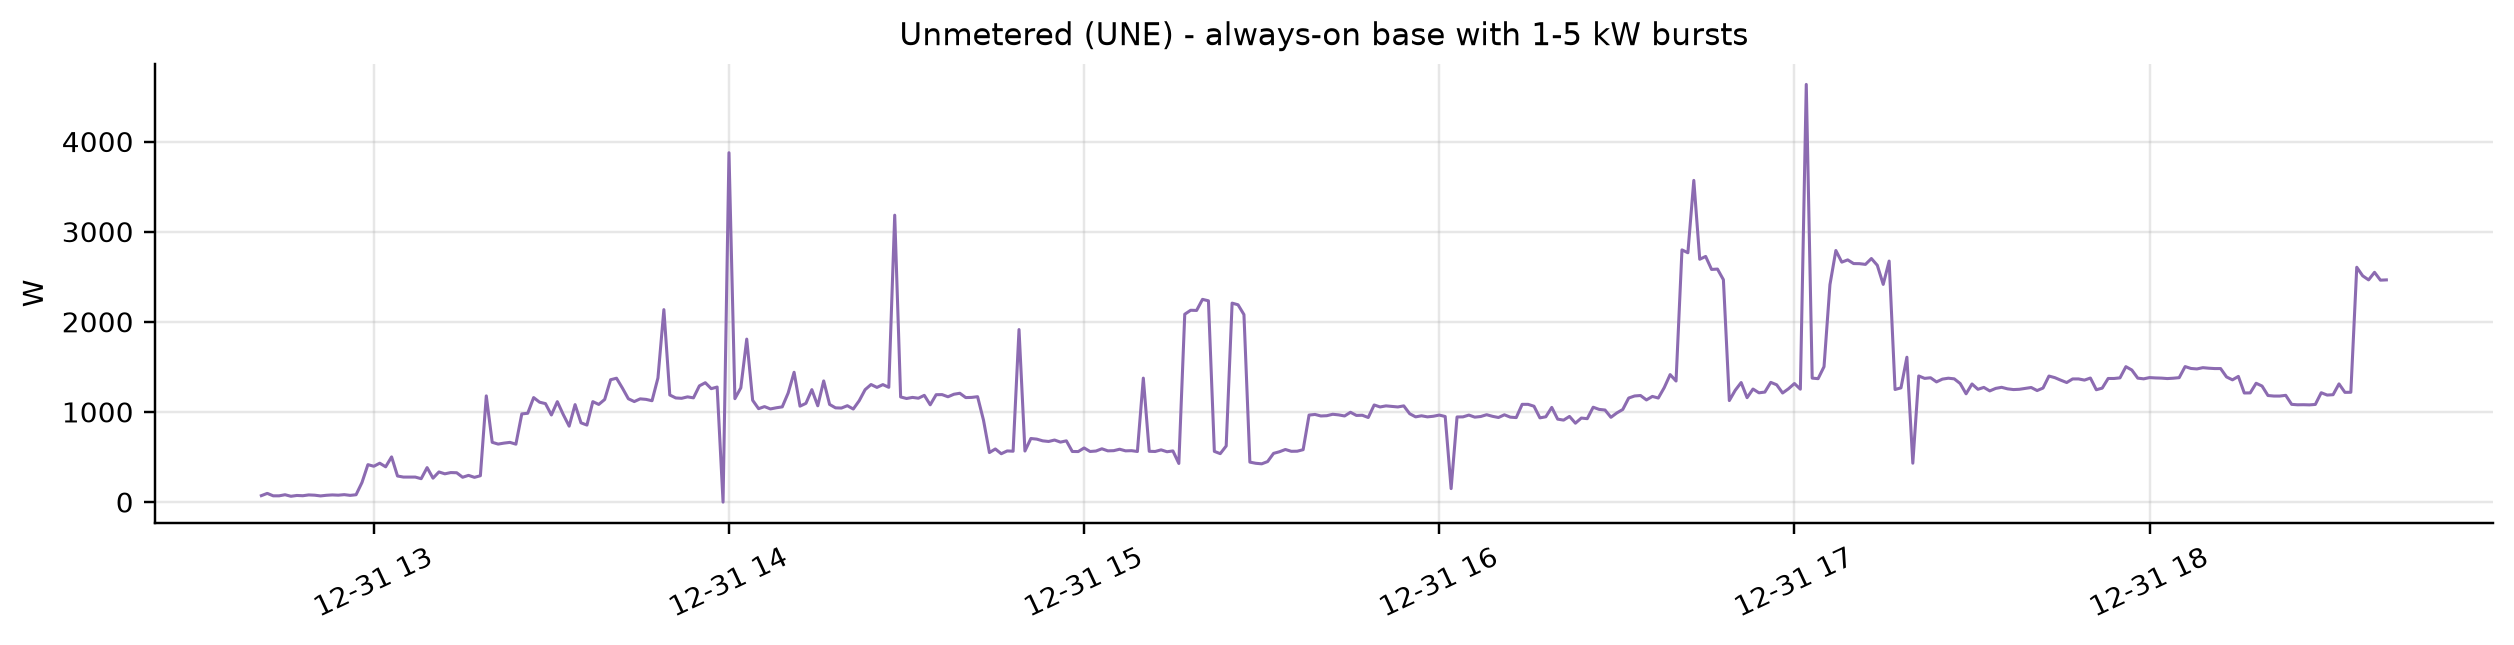
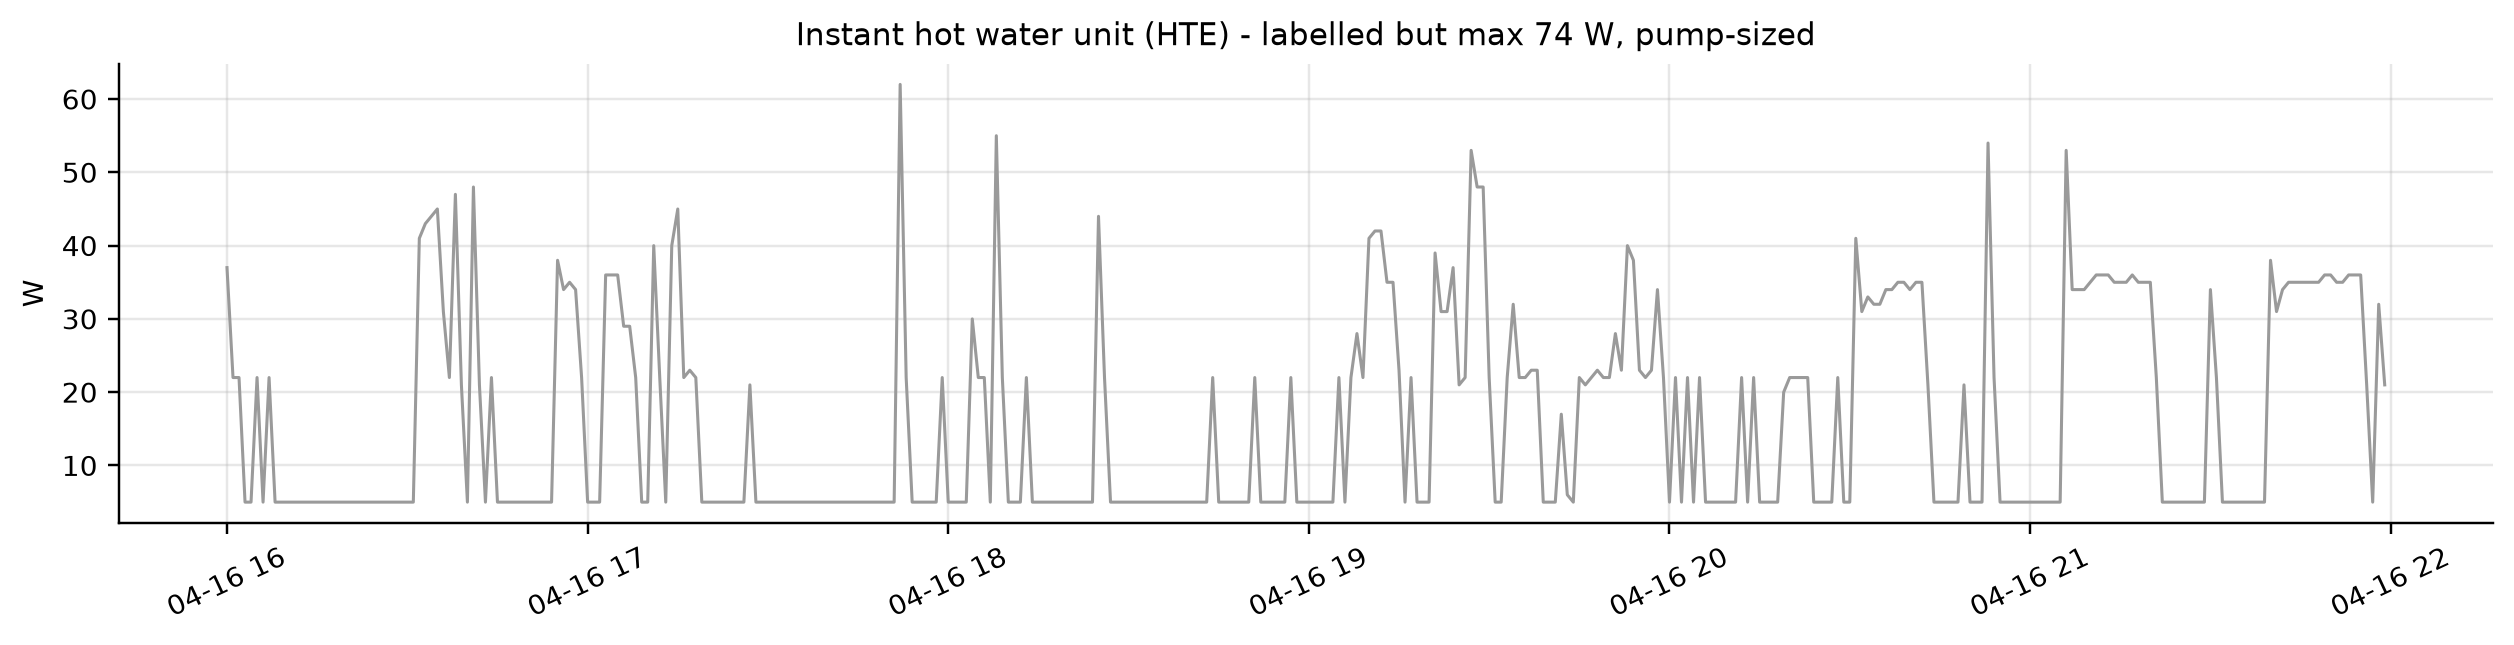

In [ ]:
_figs = []
print(NAME['RSE'] + ' - the second household (Q10 preview)')
_figs.append(gallery(P['RSE'], hours=6, color='#5a7d9a', title='Rental suite (RSE) - its own morning and evening peaks'))
print(NAME['UNE'] + ' - bursts and base (Q6 deep-dive)')
_figs.append(gallery(P['UNE'], hours=6, color='#8c6bb1', title='Unmetered (UNE) - always-on base with 1-5 kW bursts'))
print(NAME['HTE'] + ' - the mislabelled instant hot water unit')
_figs.append(gallery(P['HTE'], hours=6, color='#9a9a9a', title='Instant hot water unit (HTE) - labelled but max 74 W, pump-sized'))
mo.vstack(_figs)

**Reading it.** The gallery closes on the three circuits with stories: **RSE** has the shape of a complete household (dual peaks, overnight base); **UNE** shows its water-heater profile (base + bursts); **HTE** is flat and tiny - the visual proof that its label cannot be right. Three circuits, three different lessons about labels: unlabelled but attributable (UNE), labelled but wrong (HTE), labelled and honest (RSE).

## Q10 - Two households, one service

RSE is 22.5% of the whole service - and it is not a room, it is a *second home* with its own occupants. The release documents a rental suite on a sub-panel. The question: does it behave like the main house (one family's rhythm scaled down) or like an independent household?

suite peak hour 18:00 (524 W) | main-house peak hour 22:00 (1246 W)
hourly-profile corr: 0.79
suite overnight (00-06) base 133 W | share of WHE: 22.5%


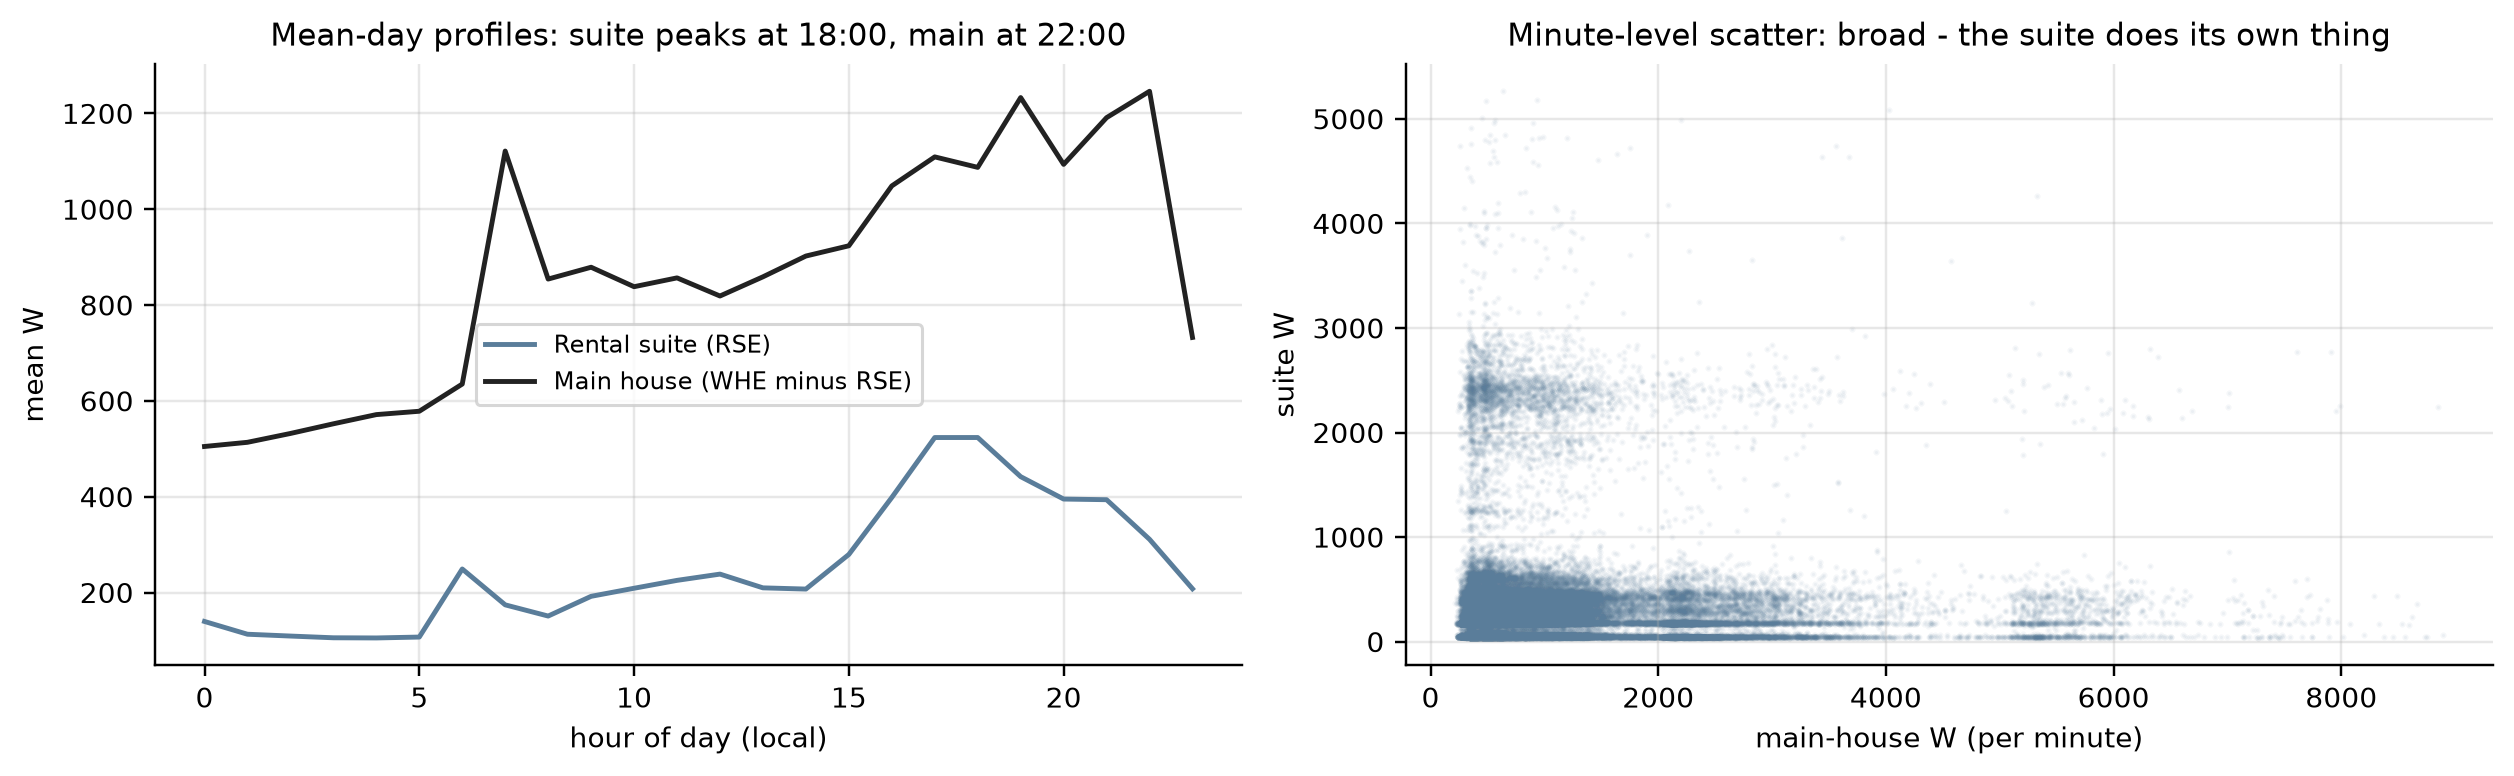

In [ ]:
main = P['WHE'] - P['RSE']
rh = pd.Series(P['RSE'], index=IDX).groupby(HOD).mean()
mh2 = pd.Series(main, index=IDX).groupby(HOD).mean()
print('suite peak hour %02d:00 (%.0f W) | main-house peak hour %02d:00 (%.0f W)' % (int(np.argmax(rh.values)), rh.max(), int(np.argmax(mh2.values)), mh2.max()))
print('hourly-profile corr: %.2f' % float(np.corrcoef(rh.values, mh2.values)[0, 1]))
print('suite overnight (00-06) base %.0f W | share of WHE: %.1f%%' % (P['RSE'][HOD < 7].mean(), 100 * PASS['kwh']['RSE'] / PASS['total']))
_fig, _axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
_ax = _axes[0]
_ax.plot(rh.index, rh.values, color='#5a7d9a', lw=1.6, label='Rental suite (RSE)')
_ax.plot(mh2.index, mh2.values, color='#222222', lw=1.6, label='Main house (WHE minus RSE)')
_ax.set_xlabel('hour of day (local)')
_ax.set_ylabel('mean W')
_ax.set_title('Mean-day profiles: suite peaks at %02d:00, main at %02d:00' % (int(np.argmax(rh.values)), int(np.argmax(mh2.values))))
_ax.legend(fontsize=8)
_ax = _axes[1]
_ax.scatter(main[::10], P['RSE'][::10], s=1, alpha=0.06, color='#5a7d9a')
_ax.set_xlabel('main-house W (per minute)')
_ax.set_ylabel('suite W')
_ax.set_title('Minute-level scatter: broad - the suite does its own thing')
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** The suite is a real household: its mean-day profile peaks at 18:00 - hours *before* the main house's late-evening peak at 22:00 - with its own overnight base (133 W), and the two hourly profiles correlate only loosely (0.79). The minute-level scatter is broad: high main-house draw does not imply a busy suite, and vice versa.

For our gold layer this is a warning shot: **a whole-home meter can be metering two economies.** Our deployment instructions assume one household per service - the US rental-suite configuration (basement or attached unit on its own sub-panel, sometimes submetered, sometimes not) means the "home" we disaggregate may contain a second family whose schedule decorrelates from the first. If a CT lands on a shared service, suite-class loads will appear as unexplained residual unless we ask. [collectable]

## Q11 - The paper trail: bills, monthly tables, weather annotations, climate normals

AMPds2 ships more than meter channels: utility invoices (electricity, gas, water), monthly roll-ups, an Environment Canada hourly weather table with per-element flag strings and sky-condition text, and the climate normals for the station. The hardened extractor now keeps every non-numeric column verbatim - nullable strings, recorded per file in the manifest as non_numeric_cols - so the paper trail can play its three roles: ground truth to audit the meters, confidence metadata to gate readings, and provenance strings that pin down what the numbers mean. Each role has its own trap. Four audits follow: the electricity bills (Q11a), the release's monthly roll-up against meter and weather (Q11b), the gas and water trails (Q11c), and the weather annotations with the climate normals (Q11d).

### Q11a - The electricity bills: 14 invoices vs the meter integral

The bills are the release's own ground truth for the electricity meter - and the closest thing a real deployment gets to a free audit. Each invoice names a From/To service period and the kWh billed against it; the meter integral over that window is the comparison. (The ts_us column anchors the *invoice* date, not the period - two periods share one anchor.)

In [ ]:
# Q11a: the electricity bill vs the meter. From/To are naive local date
# strings; ts_us anchors the INVOICE date at UTC midnight in MILLISECONDS
# and is not a key (two periods share one anchor). The meter integral is
# sliced to each invoice's From + Billing Days window.
ebill = pq.read_table(eda.fnd_file('ampds2', 'Electricity_Billing.parquet')).to_pandas()
kwhmin = pd.Series(P['WHE'] / 60.0, index=IDX)  # Wh carried by each minute-row
perrows = []
for _i, _r in ebill.iterrows():
    _f = pd.Timestamp(str(_r['From Date']) + ' 00:00')
    _n = int(_r['Billing Days'])
    _m = float(kwhmin[(IDX >= _f) & (IDX < _f + pd.Timedelta(days=_n))].sum()) / 1000.0
    _b = float(_r['kWh Usage'])
    perrows.append((str(_r['From Date'])[:10] + ' -> ' + str(_r['To Date'])[:10], _n, round(_b), round(_m, 1), round(100.0 * (_b - _m) / _b, 2)))
bsum = float(ebill['kWh Usage'].sum())
msum = round(sum(r[3] for r in perrows), 1)
fulldiffs = [r[4] for r in perrows if r[1] >= 59]
etec = float((ebill['Basic Charge'] + ebill['Usage Charge Step 1'] + ebill['Usage Charge Step 2'] + ebill['Rate Rider'] - ebill['Total Energy Charge']).abs().max())
etot = float((ebill['Total Energy Charge'] + ebill['Regional Transit Levy'] + ebill['Tax'] - ebill['Bill Total']).abs().max())
ndup = int(ebill['ts_us'].duplicated().sum())
invdates = pd.to_datetime(ebill['ts_us'], unit='ms', utc=True)
chgrow = int(ebill.index[ebill['Step 1 per kWh Charge'].diff().fillna(0).ne(0)][0])
lastbill = ebill.iloc[-1]
spanlast = (pd.Timestamp(str(lastbill['To Date'])) - pd.Timestamp(str(lastbill['From Date']))).days + 1
truelast = pd.Timestamp(str(lastbill['From Date'])) + pd.Timedelta(days=int(lastbill['Billing Days']) - 1)
thrday = ebill['Step 1 kWh Threshold'] / ebill['Billing Days']
print('electricity billing: %d invoices, sum(Billing Days) = %d = the meter grid; periods are contiguous (From_i = To_(i-1) + 1 day, 13 of 13)' % (len(ebill), int(ebill['Billing Days'].sum())))
print('ts_us anchors the INVOICE date (first CSV column) at UTC midnight, in MILLISECONDS - %d duplicated anchor(s): the 39-day catch-up period (2013-02-21 -> 03-31) and the 19-day April stub were both invoiced 2013-04-23' % ndup)
print('last invoice: To Date %s but Billing Days %d - a %d-day internal inconsistency; %s is what the days imply (the meter\'s last day), and billed on that window it lands %+.2f%% vs the meter' % (lastbill['To Date'], int(lastbill['Billing Days']), int(lastbill['Billing Days']) - spanlast, truelast.date(), perrows[-1][4]))
print('billed vs metered per invoice (meter = WHE integral over each window): totals %s billed vs %s metered kWh (%+.2f%%)' % ('{:,.0f}'.format(bsum), '{:,.1f}'.format(msum), 100.0 * (bsum - msum) / bsum))
print('  10 full periods (>=59 d): median %+.2f%%, range %+.2f%%..%+.2f%% | 39-day periods: %+.2f%% / %+.2f%% | 19-day April stubs: %+.2f%% (2012) / %+.2f%% (2013) - no read-type column records why the stubs run high' % (float(np.median(fulldiffs)), min(fulldiffs), max(fulldiffs), perrows[6][4], perrows[-1][4], perrows[0][4], perrows[7][4]))
print('bill arithmetic closes: Basic + Step1 + Step2 + Rate Rider = Total Energy Charge (max err %.4f); + Transit Levy + Tax = Bill Total (max err %.4f, cent rounding)' % (etec, etot))
print('the BC Hydro two-tier residential tariff is in the table: Step 1 threshold %.1f-%.1f kWh/day of the period (418-1398 kWh), Step 1 6.80-6.90 c/kWh, Step 2 10.19-10.34 c/kWh - the 6.90/10.34 vintage starts with invoice #%d (%s)' % (float(thrday.min()), float(thrday.max()), chgrow + 1, invdates.iloc[chgrow].date()))
PASS['bill_billed_kwh'] = round(bsum)
PASS['bill_metered_kwh'] = round(msum)
PASS['bill_diff_pct'] = round(100.0 * (bsum - msum) / bsum, 2)
PASS['bill_full_median_pct'] = round(float(np.median(fulldiffs)), 2)
PASS['bill_arith_max'] = round(max(etec, etot), 4)
mo.md(eda.md_table(['invoice period (From -> To)', 'days', 'billed kWh', 'metered kWh', 'billed - metered %'], perrows))

electricity billing: 14 invoices, sum(Billing Days) = 730 = the meter grid; periods are contiguous (From_i = To_(i-1) + 1 day, 13 of 13)
ts_us anchors the INVOICE date (first CSV column) at UTC midnight, in MILLISECONDS - 1 duplicated anchor(s): the 39-day catch-up period (2013-02-21 -> 03-31) and the 19-day April stub were both invoiced 2013-04-23
last invoice: To Date 2014-03-21 but Billing Days 39 - a 10-day internal inconsistency; 2014-03-31 is what the days imply (the meter's last day), and billed on that window it lands +0.72% vs the meter
billed vs metered per invoice (meter = WHE integral over each window): totals 19,789 billed vs 19,488.0 metered kWh (+1.52%)
  10 full periods (>=59 d): median +0.72%, range +0.27%..+1.69% | 39-day periods: -1.74% / +0.72% | 19-day April stubs: +20.65% (2012) / +5.95% (2013) - no read-type column records why the stubs run high
bill arithmetic closes: Basic + Step1 + Step2 + Rate Rider = Total Energy Charge (max err 0.0000); + Transit Levy + Tax

| invoice period (From -> To) | days | billed kWh | metered kWh | billed - metered % |
| --- | --- | --- | --- | --- |
| 2012-04-01 -> 2012-04-19 | 19 | 688 | 545.9 | 20.65 |
| 2012-04-20 -> 2012-06-18 | 60 | 1398 | 1386.5 | 0.82 |
| 2012-06-19 -> 2012-08-17 | 60 | 1361 | 1357.3 | 0.27 |
| 2012-08-18 -> 2012-10-18 | 62 | 1423 | 1408.1 | 1.04 |
| 2012-10-19 -> 2012-12-19 | 62 | 2067 | 2032.1 | 1.69 |
| 2012-12-20 -> 2013-02-20 | 63 | 1972 | 1954.9 | 0.87 |
| 2013-02-21 -> 2013-03-31 | 39 | 1209 | 1230.0 | -1.74 |
| 2013-04-01 -> 2013-04-19 | 19 | 590 | 554.9 | 5.95 |
| 2013-04-20 -> 2013-06-19 | 61 | 1470 | 1460.8 | 0.63 |
| 2013-06-20 -> 2013-08-20 | 62 | 1454 | 1444.1 | 0.68 |
| 2013-08-21 -> 2013-10-21 | 62 | 1530 | 1519.3 | 0.7 |
| 2013-10-22 -> 2013-12-19 | 59 | 1676 | 1665.0 | 0.66 |
| 2013-12-20 -> 2014-02-20 | 63 | 1843 | 1829.1 | 0.75 |
| 2014-02-21 -> 2014-03-21 | 39 | 1108 | 1100.0 | 0.72 |

**Reading it.** The bills re-derive the meter: totals +1.5% billed vs metered, 12 of 14 invoices within 2% (median +0.7% over the 10 full periods), and the bill arithmetic closes to the cent on both utilities (Basic + Step 1 + Step 2 + Rider = Total Energy Charge; + Regional Transit Levy + Tax = Bill Total). The two-tier BC Hydro tariff is visible in the table itself - the Step 1 per-kWh charge changes mid-record. The failures are as instructive as the checks: the two 19-day April stubs run +21%/+6% with no read-type column to explain them, and the last invoice's To Date contradicts its own Billing Days by 10 days - the days column is what the meter agrees with. The left panel of the figure below charts these residuals.

### Q11b - The release's monthly roll-up: half-empty, and off by 7.6% in its worst month

Electricity_Monthly is the release's own aggregate layer - and the weakest one. The figure pairs Q11a's per-invoice residuals (left) with the monthly table against the meter integral and the weather file's monthly temperatures (right).

Electricity_Monthly: 16 of 24 months filled (Apr-Nov 2012 blank) | vs the meter integral: median +0.02%, worst -7.62% (2013-08)
its Avg Outside Temp column matches the weather-file monthly mean within 0.38 C (mean abs 0.08 C) - two independent temperature paths agree


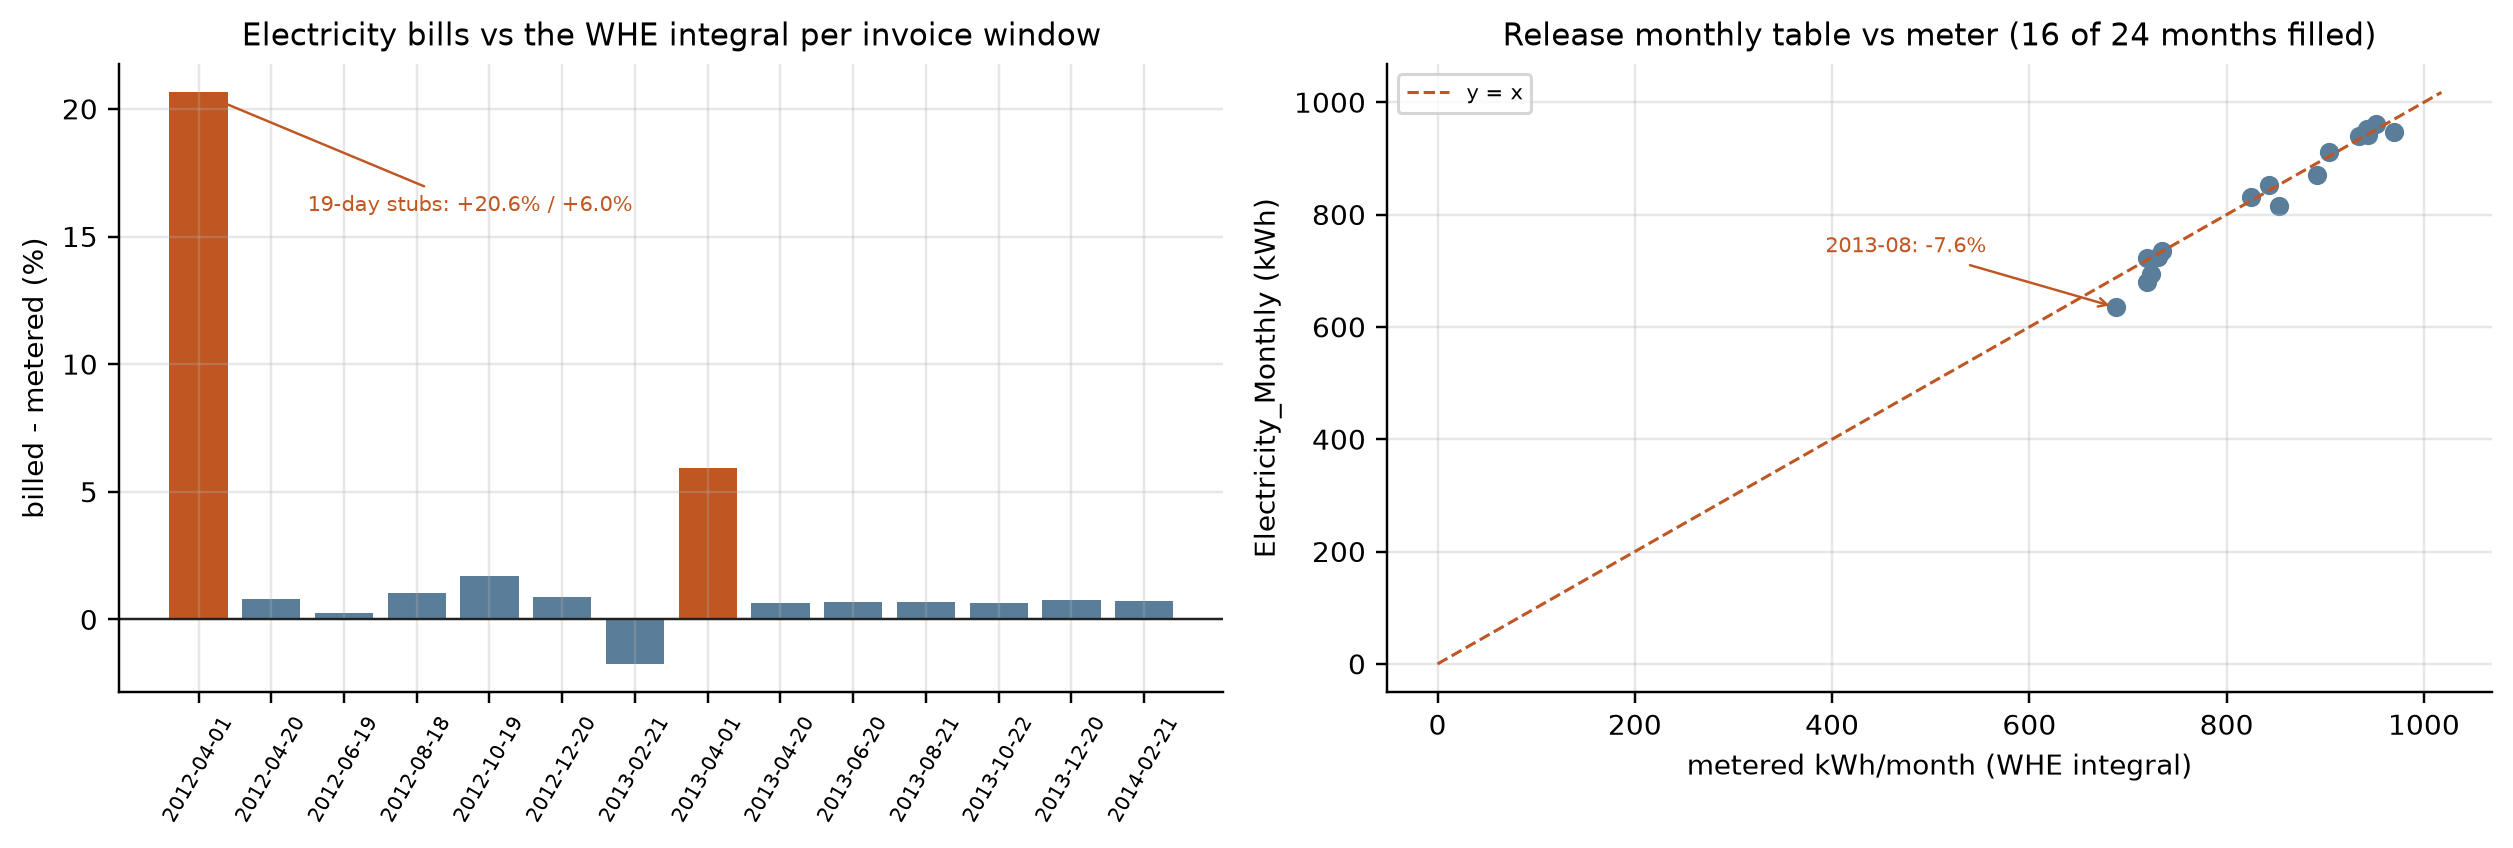

In [ ]:
# Q11b: the release's own monthly roll-up vs the meter, and its monthly
# temperature vs the weather file. Both sides bucketed by UTC calendar
# month (the monthly table's ts_us sits at UTC midnights, in ms).
emon = pq.read_table(eda.fnd_file('ampds2', 'Electricity_Monthly.parquet')).to_pandas()
emon = emon.set_index(pd.to_datetime(emon['ts_us'], unit='ms', utc=True).dt.tz_localize(None).dt.to_period('M'))
monok = emon['Net Consumption (kWh)'].notna()
midx = pd.to_datetime(ts_us, unit='us', utc=True)
monmet = pd.Series(P['WHE'] / 60.0, index=midx).resample('MS').sum() / 1000.0
monmet.index = monmet.index.tz_localize(None).to_period('M')
moncomp = pd.DataFrame({'release': emon.loc[monok, 'Net Consumption (kWh)'], 'metered': monmet}).dropna()
moncomp['diff_pct'] = 100.0 * (moncomp['release'] - moncomp['metered']) / moncomp['metered']
worstmon = moncomp['diff_pct'].abs().idxmax()
tcol = [c for c in emon.columns if 'Temp' in c][0]
wxsub = pq.read_table(eda.fnd_file('ampds2', 'Climate_HourlyWeather.parquet'), columns=['ts_us', 'Temp (C)'])
wutc = pd.to_datetime(wxsub['ts_us'].to_numpy().astype(np.int64), unit='ms', utc=True)
wmean = pd.Series(wxsub['Temp (C)'].to_numpy().astype(float), index=wutc).resample('MS').mean()
wmean.index = wmean.index.tz_localize(None).to_period('M')
tcomp = pd.DataFrame({'release': emon.loc[monok, tcol].astype(float), 'weather': wmean}).dropna()
tdiff = float((tcomp['release'] - tcomp['weather']).abs().max())
print('Electricity_Monthly: %d of %d months filled (Apr-Nov 2012 blank) | vs the meter integral: median %+.2f%%, worst %+.2f%% (%s)' % (int(monok.sum()), len(emon), float(moncomp['diff_pct'].median()), float(moncomp.loc[worstmon, 'diff_pct']), worstmon))
print('its Avg Outside Temp column matches the weather-file monthly mean within %.2f C (mean abs %.2f C) - two independent temperature paths agree' % (tdiff, float((tcomp['release'] - tcomp['weather']).abs().mean())))
PASS['mon_cover_months'] = int(monok.sum())
PASS['mon_max_diff_pct'] = round(float(moncomp['diff_pct'].abs().max()), 2)
PASS['mon_temp_max_diff_c'] = round(tdiff, 2)
_fig, _axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
_ax = _axes[0]
_cols = ['#c05621' if r[1] < 30 else '#5a7d9a' for r in perrows]
_ax.bar(range(len(perrows)), [r[4] for r in perrows], color=_cols)
_ax.axhline(0.0, color='#222222', lw=0.8)
_ax.set_xticks(range(len(perrows)))
_ax.set_xticklabels([r[0][:10] for r in perrows], rotation=60, fontsize=6.5)
_ax.set_ylabel('billed - metered (%)')
_ax.set_title('Electricity bills vs the WHE integral per invoice window')
_ax.annotate('19-day stubs: %+.1f%% / %+.1f%%' % (perrows[0][4], perrows[7][4]), xy=(0, perrows[0][4]), xytext=(1.5, 16.0), fontsize=7, color='#c05621', arrowprops=dict(arrowstyle='->', color='#c05621', lw=0.8))
_ax = _axes[1]
_ax.scatter(moncomp['metered'], moncomp['release'], s=28, color='#5a7d9a')
_lim = [0.0, float(max(moncomp['metered'].max(), moncomp['release'].max())) * 1.05]
_ax.plot(_lim, _lim, color='#c05621', lw=1.0, ls='--', label='y = x')
_ax.annotate('%s: %+.1f%%' % (str(worstmon), float(moncomp.loc[worstmon, 'diff_pct'])), xy=(float(moncomp.loc[worstmon, 'metered']), float(moncomp.loc[worstmon, 'release'])), xytext=(-95, 18), textcoords='offset points', fontsize=7, color='#c05621', arrowprops=dict(arrowstyle='->', color='#c05621', lw=0.8))
_ax.set_xlabel('metered kWh/month (WHE integral)')
_ax.set_ylabel('Electricity_Monthly (kWh)')
_ax.set_title('Release monthly table vs meter (%d of 24 months filled)' % int(monok.sum()))
_ax.legend(fontsize=7, loc='upper left')
_fig.tight_layout()
_fig  # render figure as cell output

**Reading it.** Electricity_Monthly is half-empty: 16 of 24 months filled, and its worst month sits -7.6% from the meter integral. Its Avg Outside Temp column, though, matches the hourly weather file's monthly means within 0.38 C - two independent temperature paths agreeing. The rule this buys: derive monthly aggregates from the minute grid; keep the release's table as a cross-check, not a source. [collectable]

### Q11c - Gas and water: overhanging windows, a heat-values key, and a garbage anchor

The gas trail (furnace + water-heater counters, billed in GJ) and the water trail (annual fee table) close the paper audit. Gas bills overhang the electricity meter window at both ends, so the billed GJ must be prorated before comparison.

In [ ]:
# Q11c: the gas and water paper trails. Gas bills overhang the electricity
# meter window at both ends, so the billed GJ are prorated to overlap.
gbill = pq.read_table(eda.fnd_file('ampds2', 'NaturalGas_Billing.parquet')).to_pandas()
gerr = float((gbill['Basic charge'] + gbill['Delivery charges'] + gbill['Storage and transport'] + gbill['Commodity charges'] + gbill['Tax'] + gbill['Clean energy levy'] + gbill['Carbon tax'] - gbill['Amount']).abs().max())
gjtot = float(gbill['Billed GJ'].sum())
t0 = pd.Timestamp('2012-04-01')
t1 = pd.Timestamp('2014-04-01')
gjov = 0.0
for _i, _r in gbill.iterrows():
    _f = pd.Timestamp(str(_r['From Date']))
    _u = pd.Timestamp(str(_r['To Date'])) + pd.Timedelta(days=1)
    _ov = (min(_u, t1) - max(_f, t0)).days
    if _ov > 0:
        gjov += float(_r['Billed GJ']) * _ov / (_u - _f).days
gmonth = pq.read_table(eda.fnd_file('ampds2', 'NaturalGas_Monthly.parquet')).to_pandas()
gjmon = float(gmonth['Net Consumption (GJ)'].sum())
hval = pq.read_table(eda.fnd_file('ampds2', 'NaturalGas_HeatValues.parquet')).to_pandas()
hvv = hval[hval.columns[2:]].to_numpy().astype(float)
wbill = pq.read_table(eda.fnd_file('ampds2', 'Water_Billing.parquet')).to_pandas()
print('gas billing: %d invoices, %s -> %s (sum Billing Days = %d) - the gas trail overhangs the electricity meter window at both ends (%d days before 2012-04-01, %d days past 2014-03-31)' % (len(gbill), gbill['From Date'].iloc[0], gbill['To Date'].iloc[-1], int(gbill['Billing Days'].sum()), (t0 - pd.Timestamp(str(gbill['From Date'].iloc[0]))).days, (pd.Timestamp(str(gbill['To Date'].iloc[-1])) - pd.Timestamp('2014-03-31')).days))
print('gas bill arithmetic closes to %.4f: Basic + Delivery + Storage and transport + Commodity + Tax + Clean energy levy + Carbon tax = Amount' % gerr)
print('billed energy %.1f GJ; prorated into the meter window %.1f GJ vs the release monthly table %.1f GJ (%+.1f%%)' % (gjtot, gjov, gjmon, 100.0 * (gjov - gjmon) / gjmon))
print('NaturalGas_HeatValues: %d rows (days 1-31 plus Min/Max/Avg summary rows) x 12 month columns; %.2f-%.2f MJ/m^3 (mean %.2f) - the volume-to-energy key the GJ bills rest on' % (len(hval), float(np.nanmin(hvv)), float(np.nanmax(hvv)), float(np.nanmean(hvv))))
print('water billing: %d annual rows, Total Fees %.2f -> %.2f; "Sewer Pacel" typo kept verbatim from the CSV' % (len(wbill), float(wbill['Total Fees'].iloc[0]), float(wbill['Total Fees'].iloc[-1])))
print('water ts_us = %s for every row - the integer Year (2012..2014 in the raw CSV) parsed as nanoseconds after epoch and truncated to microseconds: the anchor is garbage, the year survives only in the raw CSV' % (wbill['ts_us'].unique().tolist(),))
PASS['gas_billed_gj'] = round(gjtot, 1)
PASS['gas_prorated_gj'] = round(gjov, 1)
PASS['gas_monthly_gj'] = round(gjmon, 1)
wrows = [[str(_i + 1), float(_r['Flat Water']), float(_r['Sewer Pacel']), float(_r['Sewer Use']), float(_r['Garbage Disposal Fee']), float(_r['Total Fees'])] for _i, _r in wbill.iterrows()]
mo.md(eda.md_table(['water bill (annual rows)', 'Flat Water', 'Sewer Pacel', 'Sewer Use', 'Garbage Disposal Fee', 'Total Fees'], wrows))

gas billing: 25 invoices, 2012-03-19 -> 2014-04-16 (sum Billing Days = 758) - the gas trail overhangs the electricity meter window at both ends (13 days before 2012-04-01, 16 days past 2014-03-31)
gas bill arithmetic closes to 0.0000: Basic + Delivery + Storage and transport + Commodity + Tax + Clean energy levy + Carbon tax = Amount
billed energy 102.3 GJ; prorated into the meter window 98.4 GJ vs the release monthly table 97.5 GJ (+0.9%)
NaturalGas_HeatValues: 34 rows (days 1-31 plus Min/Max/Avg summary rows) x 12 month columns; 38.16-39.39 MJ/m^3 (mean 38.64) - the volume-to-energy key the GJ bills rest on
water billing: 3 annual rows, Total Fees 995.52 -> 1188.29; "Sewer Pacel" typo kept verbatim from the CSV
water ts_us = [2] for every row - the integer Year (2012..2014 in the raw CSV) parsed as nanoseconds after epoch and truncated to microseconds: the anchor is garbage, the year survives only in the raw CSV


| water bill (annual rows) | Flat Water | Sewer Pacel | Sewer Use | Garbage Disposal Fee | Total Fees |
| --- | --- | --- | --- | --- | --- |
| 1 | 512.88 | 482.64 | 0.0 | 0.0 | 995.52 |
| 2 | 543.65 | 511.6 | 0.0 | 75.0 | 1130.25 |
| 3 | 573.55 | 539.74 | 0.0 | 75.0 | 1188.29 |

**Reading it.** Prorated into the meter window, the gas bills land 0.9% from the release's own monthly table, and the bill arithmetic closes to the cent; the HeatValues table (MJ per cubic metre) is the volume-to-energy key the GJ figures rest on. Water is the cautionary tale: a clean-looking fee table whose extracted anchor has degenerated to ts_us = 2 - the integer Year column parsed as nanoseconds after epoch. The fees survive; the timestamp does not - keep the raw CSV columns when an anchor is this weak. And the 'Sewer Pacel' typo is kept verbatim, as any provenance string should be.

### Q11d - Weather annotations and climate normals: what the kept strings decode

The hourly weather table and the climate normals are the confidence-metadata layer: per-element M-flag strings, a Data Quality marker, sky-condition text, and the station's 30-year normals. Every non-numeric column here exists only because the extractor stopped coercing text to NaN.

In [ ]:
# Q11d: the weather file's text columns and the climate normals.
wxa = pq.read_table(eda.fnd_file('ampds2', 'Climate_HourlyWeather.parquet')).to_pandas()
wwall = pd.to_datetime(wxa['ts_us'], unit='ms', utc=True).dt.tz_localize(None)  # ts read as naive UTC = the CSV's Date/Time wall clock
starm = wxa['Data Quality'].fillna('').eq('**').to_numpy(dtype=bool)
starpct = 100.0 * starm.mean()
edges = np.flatnonzero(np.diff(starm.astype(np.int8)) != 0) + 1
bounds = np.concatenate([[0], edges, [len(starm)]])
runlens = np.diff(bounds)
runvals = starm[bounds[:-1]]
starruns = sorted(int(x) for x in runlens[runvals])
firststar = wwall.iloc[int(np.flatnonzero(starm)[0])]
n2014 = int(starm[(wwall.dt.year == 2014).to_numpy()].sum())
y2014 = int((wwall.dt.year == 2014).to_numpy().sum())
tflag = wxa.loc[starm, 'Temp (C)'].astype(float)
flagrows = []
for _v, _fl in [('Temp (C)', 'Temp Flag'), ('Dew Point Temp (C)', 'Dew Point Temp Flag'), ('Rel Hum (%)', 'Rel Hum Flag'), ('Wind Dir (10s deg)', 'Wind Dir Flag'), ('Wind Spd (km/h)', 'Wind Spd Flag'), ('Stn Press (kPa)', 'Stn Press Flag')]:
    _nan = wxa[_v].isna()
    _m = wxa[_fl].fillna('').eq('M')
    flagrows.append((_v.split(' (')[0], int(_nan.sum()), int(_m.sum()), int((_m & _nan).sum())))
wdd = [r for r in flagrows if r[0] == 'Wind Dir'][0]
calmov = int((wxa['Wind Dir (10s deg)'].isna() & (wxa['Wind Spd (km/h)'].astype(float) == 0)).sum())
tstr = pd.to_datetime(wxa['Time'], format='%H:%M').dt.hour
npst = int((tstr == wwall.dt.hour).sum())
nvdt = int((tstr == pd.to_datetime(wxa['ts_us'], unit='ms', utc=True).dt.tz_convert('America/Vancouver').dt.hour).sum())
wvc = wxa['Weather'].value_counts()
snowh = int(wxa['Weather'].fillna('').eq('Snow').sum())
wcm = float(wxa.loc[wxa['Wind Chill'].notna(), 'Temp (C)'].astype(float).max())
print('weather text columns: Time (%s clock strings), Data Quality (blank %s / "**" %s = %.1f%%), 6 per-element flag columns, Weather (%s filled = %.1f%%), plus conditional Hmdx (%d hours) and Wind Chill (%d hours)' % ('{:,}'.format(int(wxa['Time'].notna().sum())), '{:,}'.format(int(wxa['Data Quality'].isna().sum())), '{:,}'.format(int(starm.sum())), starpct, '{:,}'.format(int(wxa['Weather'].notna().sum())), 100.0 * wxa['Weather'].notna().mean(), int(wxa['Hmdx'].notna().sum()), int(wxa['Wind Chill'].notna().sum())))
print('"**" is NOT missingness: %d contiguous blocks (%d-%d h = %.0f-%.0f days), first %s (wall clock); all %d of 2014\'s %d hours are flagged; temps on flagged rows still span %.1f..%.1f C' % (len(starruns), starruns[0], starruns[-1], starruns[0] / 24.0, starruns[-1] / 24.0, firststar, n2014, y2014, float(tflag.min()), float(tflag.max())))
_tprof = wxa.assign(_h=wwall.dt.hour).groupby('_h')['Temp (C)'].mean()
print('the kept Time string decodes the timestamps: it matches ts_us read as UTC in %s of %s rows but an America/Vancouver conversion in %s - the extractor stamped the CSV\'s Date/Time wall clock (Environment Canada LST = PST year-round: mean temperature peaks at %.0f:00) with UTC epochs; hour-level joins must read ts_us as the naive wall clock and localize at Etc/GMT+8 to reach true UTC, never tz_convert' % ('{:,}'.format(npst), '{:,}'.format(len(wxa)), '{:,}'.format(nvdt), float(_tprof.idxmax())))
print('the M-flags mark the real missing readings: every M-flagged row is NaN for its element - but NaNs outrun flags (Wind Dir: %d NaN vs %d M-flags; %d of the NaNs are calm hours, Wind Spd = 0, where direction is undefined)' % (wdd[1], wdd[2], calmov))
print('Wind Chill exists only on cold hours (max temp among its rows %.1f C); Hmdx only on hot-humid ones - conditional columns, not meters' % wcm)
print('%d distinct sky conditions; Snow appears in %d hours, all in Dec/Feb/Mar (both Januaries stayed too warm)' % (int(wxa['Weather'].nunique()), snowh))
hnrm = pq.read_table(eda.fnd_file('ampds2', 'Climate_HistoricalNormals.parquet')).to_pandas()

def _isnum(x):
    try:
        float(x)
        return True
    except (TypeError, ValueError):
        return False

nstr = sum(1 for _c in list(hnrm.columns[3:15]) for _v in hnrm[_c] if not _isnum(_v))
jandates = hnrm.loc[hnrm['Item Detail'] == 'Date (yyyy/dd)', 'Jan'].tolist()
print('climate normals: %d rows x 12 months, precipitation-only climatology; the Year column = annual totals: %s; ts_us is null' % (len(hnrm), ', '.join('%s %s' % (hnrm['Item Detail'].iloc[i], hnrm['Year'].iloc[i]) for i in range(3))))
print('%d string cells = the 4 "Date (yyyy/dd)" rows x 12 months: record extremes as "year/day" strings (Jan: %s) - provenance, not numbers; they force the month columns to string dtype' % (nstr, jandates))
PASS['wx_star_pct'] = round(starpct, 1)
PASS['wx_conditions_n'] = int(wxa['Weather'].nunique())
PASS['normals_str_cells'] = int(nstr)
wtop = [[k, int(v), round(100.0 * v / len(wxa), 1)] for k, v in wvc.head(8).items()]
mo.md(eda.md_table(['element', 'NaN hours', 'M-flag hours', 'M-flag and NaN'], flagrows) + '\n\n' + eda.md_table(['top sky conditions', 'hours', '% of hours'], wtop))

weather text columns: Time (17,520 clock strings), Data Quality (blank 10,535 / "**" 6,985 = 39.9%), 6 per-element flag columns, Weather (13,853 filled = 79.1%), plus conditional Hmdx (663 hours) and Wind Chill (548 hours)
"**" is NOT missingness: 4 contiguous blocks (331-2853 h = 14-119 days), first 2013-06-13 11:00:00 (wall clock); all 2160 of 2014's 2160 hours are flagged; temps on flagged rows still span -9.7..27.2 C
the kept Time string decodes the timestamps: it matches ts_us read as UTC in 17,520 of 17,520 rows but an America/Vancouver conversion in 0 - the extractor stamped the CSV's Date/Time wall clock (Environment Canada LST = PST year-round: mean temperature peaks at 15:00) with UTC epochs; hour-level joins must read ts_us as the naive wall clock and localize at Etc/GMT+8 to reach true UTC, never tz_convert
the M-flags mark the real missing readings: every M-flagged row is NaN for its element - but NaNs outrun flags (Wind Dir: 857 NaN vs 15 M-flags; 826 of the NaNs are calm

| element | NaN hours | M-flag hours | M-flag and NaN |
| --- | --- | --- | --- |
| Temp | 22 | 7 | 7 |
| Dew Point Temp | 36 | 21 | 21 |
| Rel Hum | 38 | 23 | 23 |
| Wind Dir | 857 | 15 | 15 |
| Wind Spd | 31 | 16 | 16 |
| Stn Press | 35 | 20 | 20 |

| top sky conditions | hours | % of hours |
| --- | --- | --- |
| Mainly Clear | 3200 | 18.3 |
| Mostly Cloudy | 2992 | 17.1 |
| Cloudy | 2951 | 16.8 |
| Rain | 1392 | 7.9 |
| Clear | 1113 | 6.4 |
| Fog | 713 | 4.1 |
| Rain Showers | 663 | 3.8 |
| Rain - Fog | 277 | 1.6 |

**Reading it.** The weather text columns are confidence metadata, and they decode the timestamps: the kept Time string decodes the weather timestamps - the extractor stamped the CSV's Date/Time wall clock with UTC epochs (17,520/17,520 rows match ts_us read as naive UTC, 0 match an America/Vancouver conversion) - so hour-level weather joins must read ts_us as the naive wall clock and localize it at Etc/GMT+8 (Environment Canada's LST convention) to reach true UTC, never tz_convert. The '**' Data Quality flag is a station marker in 4 contiguous blocks (39.9% of hours), not missingness - the M-flags mark the true NaN readings; the normals' "1968/18" cells are the provenance of the station's record extremes; and Water_Billing's ts_us = 2 is the cautionary tale for trusting an extracted anchor over its string source. All of this exists only because the extractor stopped coercing text columns to NaN.

The paper trail is the release's own audit kit, and it audits well. The electricity bills re-derive the WHE integral to ~1.5%; the gas bills prorated into the meter window land 0.9% from the release's own monthly table; the monthly summary's temperature matches the weather file within 0.38 C - and its failures (half-empty months, a garbage water anchor, an internally inconsistent last invoice) are as instructive as its checks. The rule this buys: **derive from the minute data, cross-check against the paper trail, never the reverse.** [collectable] A bill-vs-aggregate comparison is the one free ground truth a deployment gets - and even here, with a near-perfect meter, the bill sits ~1% away (period boundaries, riders, rounding), so a 2-3% tolerance is the right gate.

## Q12 - What the gold layer should do with AMPds2

Consolidating everything into the policy table for our data pipeline; the quirks digest and the verdict follow as their own sections.

In [ ]:
pol = [
    ('role', 'calibration + cadence-limit reference (the "60 s deployment" dataset)'),
    ('mains', 'WHE whole-house (240 V service, split-phase)'),
    ('submeters', '21 real meters: 20 labelled house circuits + RSE suite sub-panel (MHE/UNE are computed columns)'),
    ('coverage', 'closure BY CONSTRUCTION: WHE == RSE + sum(20) exactly because UNE (the remainder) is published - tiling unit test yes, but a named residual is not submeter coverage'),
    ('cadence', '60 s per-minute AVERAGES: energy exact, timing +/-60 s, no sub-minute shapes'),
    ('registers', 'Pt/Qt/St BROKEN: one-minute wipe + 39-min meltdown; naive positive-diff = 3.1x truth; the 6 all-zero minutes sit at these two incidents. NEVER use'),
    ('labels', 'UNE = published Unmetered remainder (17.9%, water-heating shaped, hour-matched 1.4-1.5x); HTE label false (max 74 W)'),
    ('dead circuits', 'OUE 0 kWh, DNE/B1E/GRE trace - exclude from appliance models'),
    ('always-on floor', 'EQE 40 + UTE 51 + OFE 27 + FRE 110 + UNE 108 + HTE 5 W (p50s) - ~340 W floor (UNE attributed arithmetically only)'),
    ('seasonality', '2 winters: elec 1.28x summer, HPE 3.0x, gas 3.9x, corr(WHE, temp) -0.65'),
    ('power quality', 'per-circuit V/f/PF; V*I = ~2x S on 240 V channels (I is two-leg) - audit derived PF on 240 V before trusting; motors 0.69-0.70 vs resistors 0.99-1.00'),
    ('suite', 'RSE = 22.5%, own rhythm - treat as separate household in any model'),
    ('residual class', 'UNE is what an incompletely-submetered panel yields live: 17.9%, bursty, water-heating-shaped - model it, never zero it'),
    ('extras', 'gas (furnace+WHG counters), 3 overlapping water series (2 meters + annotations), hourly weather - all [insight only]'),
    ('paper trail', 'bills re-derive the meter: 12/14 electricity invoices within 2% (median +0.7%), totals +1.5%; gas prorated into the meter window within 0.9%; both bill arithmetics close to the cent - cross-check, never source (Q11)'),
]

mo.md(eda.md_table(['policy', 'decision'], pol))

| policy | decision |
| --- | --- |
| role | calibration + cadence-limit reference (the "60 s deployment" dataset) |
| mains | WHE whole-house (240 V service, split-phase) |
| submeters | 21 real meters: 20 labelled house circuits + RSE suite sub-panel (MHE/UNE are computed columns) |
| coverage | closure BY CONSTRUCTION: WHE == RSE + sum(20) exactly because UNE (the remainder) is published - tiling unit test yes, but a named residual is not submeter coverage |
| cadence | 60 s per-minute AVERAGES: energy exact, timing +/-60 s, no sub-minute shapes |
| registers | Pt/Qt/St BROKEN: one-minute wipe + 39-min meltdown; naive positive-diff = 3.1x truth; the 6 all-zero minutes sit at these two incidents. NEVER use |
| labels | UNE = published Unmetered remainder (17.9%, water-heating shaped, hour-matched 1.4-1.5x); HTE label false (max 74 W) |
| dead circuits | OUE 0 kWh, DNE/B1E/GRE trace - exclude from appliance models |
| always-on floor | EQE 40 + UTE 51 + OFE 27 + FRE 110 + UNE 108 + HTE 5 W (p50s) - ~340 W floor (UNE attributed arithmetically only) |
| seasonality | 2 winters: elec 1.28x summer, HPE 3.0x, gas 3.9x, corr(WHE, temp) -0.65 |
| power quality | per-circuit V/f/PF; V*I = ~2x S on 240 V channels (I is two-leg) - audit derived PF on 240 V before trusting; motors 0.69-0.70 vs resistors 0.99-1.00 |
| suite | RSE = 22.5%, own rhythm - treat as separate household in any model |
| residual class | UNE is what an incompletely-submetered panel yields live: 17.9%, bursty, water-heating-shaped - model it, never zero it |
| extras | gas (furnace+WHG counters), 3 overlapping water series (2 meters + annotations), hourly weather - all [insight only] |
| paper trail | bills re-derive the meter: 12/14 electricity invoices within 2% (median +0.7%), totals +1.5%; gas prorated into the meter window within 0.9%; both bill arithmetics close to the cent - cross-check, never source (Q11) |

## Quirks & gotchas

- **MHE is derived (WHE - RSE - GRE), not metered** - never treat it as a channel.
- **UNE + MHE exist only in the 4 wide files** - no per-circuit CSV/HDF5 meter.
- **Weather file ts_us stores MILLISECONDS** (x1000 to align with the electricity files' microseconds).
- **Weather ts_us is the CSV Date/Time wall clock** (ECCC LST = PST year-round) stamped as UTC: the kept Time string matches naive-UTC hours 17,520/17,520, America/Vancouver 0/17,520 - read as naive wall clock, localize at Etc/GMT+8 for true UTC, never tz_convert (Q11d).
- **Weather Data Quality is blank or "\*\*" only** - "\*\*" is 4 contiguous blocks over 39.9% of hours and NOT missingness; the M-flags mark the true NaN readings (Q11d).
- **Billing ts_us anchors the invoice date (ms), not the service period** - two periods share 2013-04-23; Water_Billing's anchor degenerated to ts_us = 2 (Year parsed as ns) (Q11a/c).
- **Electricity_Billing's last row is internally inconsistent** - To Date 2014-03-21 vs Billing Days 39 (= 2014-03-31); trust the days column (Q11a).
- **Electricity_Monthly is half-empty (16/24 months) and -7.6% off in its worst month** - derive monthly aggregates from the minute grid; keep the table as a cross-check (Q11b).
- **V/f/PF columns are zero when a circuit idles** - valid only during draw (Q8).
- **The 6 all-zero minutes are exactly the two register incidents** (wipe 2012-05-04, meltdown 2013-06-17) - suspect zeros near register breaks (Q7).
- **APF/DPF/f look derived or default-filled where circuits idle** - provenance-unknown, use with care (Q8).
- **V x I double-counts apparent power on ~240 V circuits** (the release's current column sums both legs) - audit derived PF on 240 V channels before trusting it (Q8).
- **"Sewer Pacel" is the release's own typo** - kept verbatim, as any provenance string should be (Q11c).
- **The release ships appliance manuals + utility bills as PDFs** - provenance, not data.

## Verdict - what is this dataset good for?

AMPds2 is the **integrity benchmark and the cadence-limit study** of our suite. Use it to test that the gold layer handles: perfect grids (it should find zero problems - that is the test), register corruption (drop, never diff), label lies (audit HTE/UNE), two-household services (RSE), and the 60 s floor where episode *durations* stop being trustworthy but energy and duty remain solid. It is the only release here that records per-circuit V and I on a split-phase 240 V panel (REDD has the topology, mains-only at 1 s) - the exact topology our Shelly EM will see in North American homes - making it the bridge dataset between the UK fleet data and our own deployment. And its best export is the one we will live with: **a knowable residual** - in our deployment the unaccounted channel will be a live estimate, and this dataset shows exactly what such a channel contains.

Where it cannot help us: sub-minute signatures (no 1 s needle data) and anything water/gas (no sensors planned). Per-circuit PF it *can* help with - we derive it from V x I like everyone else, and this dataset is where we learned to audit that derivation on 240 V circuits first.

In [ ]:
mo.md(eda.md_summary({'dataset': 'AMPds2', 'rows_wide': int(len(ts_us)), 'circuits': len(COLS), 'span_days': round((ts_us[-1] - ts_us[0]) / 86400000000, 1), 'timestep_s': round(float(dts[0]), 1), 'nonfinite': int(nn), 'reboot_allzero_minutes': int(allzero.sum()), 'longest_identical_run_min': int(lens.max()), 'episodes_gt1kW': int(len(durs)), 'episode_p50_min': float(np.percentile(durs, 50)), 'short_episode_pct': round(100 * short.mean(), 1), 'short_episode_energy_pct': round(100 * ener[short].sum() / ener.sum(), 1), 'fge_duty_pct': round(100 * fon.mean(), 1), 'fge_cycles_per_day': round(len(fst) / (len(ts_us) / 1440), 1), 'corr_P_registerdiff_masked': round(float(np.corrcoef(Pw[1:][np.abs(d) < 100000], d[np.abs(d) < 100000])[0, 1]), 4), 'register_neg_diffs': int(len(neg)), 'register_meltdown_diffs': int(len(drops)), 'naive_pos_diff_kwh': round(naive_pos), 'true_span_kwh': round(span), 'whe_kwh': round(PASS['kwh']['WHE']), 'rse_share_pct': round(100 * PASS['kwh']['RSE'] / PASS['total'], 1), 'une_share_pct': round(100 * PASS['kwh']['UNE'] / PASS['total'], 1), 'une_bursts_per_day': round(len(rst) / (len(ts_us) / 1440), 1), 'une_flow_enrichment': round(PASS['une_flow_enr'], 1), 'une_gas_cofiring': round(PASS['une_whg_enr'], 1), 'une_small_hours_w': round(float(une[HOD < 7].mean())), 'une_workday_w': round(float(une[(HOD >= 9) & (HOD < 17)].mean())), 'rse_base_w': round(float(P['RSE'][HOD < 7].mean())), 'v_spread_v': round(float(np.percentile(V, 99) - np.percentile(V, 20)), 1), 'hte_max_w': float(P['HTE'].max()), 'winter_summer_ratio': round(float(me[winter].mean() / me[summer].mean()), 2), 'corr_monthly_whe_temp': round(float(np.corrcoef(me.values, mt)[0, 1]), 2), 'rse_peak_hour': int(np.argmax(rh.values)), 'main_peak_hour': int(np.argmax(mh2.values)), 'rse_hourly_corr_main': round(float(np.corrcoef(rh.values, mh2.values)[0, 1]), 2), 'named18_share_pct': PASS.get('named18_share_pct'), 'une_s_lt_p_pct': PASS.get('une_s_lt_p_pct'), 'une_p_kwh': PASS.get('une_p_kwh'), 'tile_resid_w': PASS.get('tile_resid_w'), 'une_s_kwh': PASS.get('une_s_kwh'), 'une_htw_matched': PASS.get('une_htw_matched'), 'une_whw_matched': PASS.get('une_whw_matched'), 'une_whg_matched': PASS.get('une_whg_matched'), 'vi_ratio_240_median': PASS.get('vi_ratio_240'), 'vi_ratio_120_median': PASS.get('vi_ratio_120'), 'f_zero_rows': PASS.get('f_zero_rows'), 'freq_mean_hz': round(float(fq.mean()), 3), 'dryer_v_sag_worst': round(float(-dvs[o_1[0]]), 1), 'bill_metered_diff_pct': PASS.get('bill_diff_pct'), 'bill_full_median_pct': PASS.get('bill_full_median_pct'), 'mon_filled_months': PASS.get('mon_cover_months'), 'mon_max_diff_pct': PASS.get('mon_max_diff_pct'), 'mon_temp_max_diff_c': PASS.get('mon_temp_max_diff_c'), 'gas_prorated_gj': PASS.get('gas_prorated_gj'), 'wx_flagged_pct': PASS.get('wx_star_pct'), 'wx_conditions_n': PASS.get('wx_conditions_n'), 'normals_string_cells': PASS.get('normals_str_cells')}))

**Summary**

| metric | value |
| --- | --- |
| dataset | AMPds2 |
| rows | - |
| span | 730.0 days |
| cadence | - |
| power W (mean / p50 / p95) | - |
| energy | - |

<details><summary>raw JSON (machine-readable)</summary>

```json
{
  "dataset": "AMPds2",
  "rows_wide": 1051200,
  "circuits": 23,
  "span_days": 730.0,
  "timestep_s": 60.0,
  "nonfinite": 0,
  "reboot_allzero_minutes": 6,
  "longest_identical_run_min": 11,
  "episodes_gt1kW": 24159,
  "episode_p50_min": 4.0,
  "short_episode_pct": 47.5,
  "short_episode_energy_pct": 3.6,
  "fge_duty_pct": 36.6,
  "fge_cycles_per_day": 39.3,
  "corr_P_registerdiff_masked": 0.9609,
  "register_neg_diffs": 10,
  "register_meltdown_diffs": 9,
  "naive_pos_diff_kwh": 60032,
  "true_span_kwh": 19480,
  "whe_kwh": 19488,
  "rse_share_pct": 22.5,
  "une_share_pct": 17.9,
  "une_bursts_per_day": 6.9,
  "une_flow_enrichment": 2.2,
  "une_gas_cofiring": 2.0,
  "une_small_hours_w": 85,
  "une_workday_w": 170,
  "rse_base_w": 133,
  "v_spread_v": 8.5,
  "hte_max_w": 74.0,
  "winter_summer_ratio": 1.28,
  "corr_monthly_whe_temp": -0.65,
  "rse_peak_hour": 18,
  "main_peak_hour": 22,
  "rse_hourly_corr_main": 0.79,
  "named18_share_pct": 59.5,
  "une_s_lt_p_pct": 99.34,
  "une_p_kwh": 3482,
  "tile_resid_w": 0.0,
  "une_s_kwh": 1457,
  "une_htw_matched": 1.42,
  "une_whw_matched": 1.54,
  "une_whg_matched": 1.45,
  "vi_ratio_240_median": 1.99,
  "vi_ratio_120_median": 0.96,
  "f_zero_rows": 6,
  "freq_mean_hz": 60.005,
  "dryer_v_sag_worst": 4.5,
  "bill_metered_diff_pct": 1.52,
  "bill_full_median_pct": 0.72,
  "mon_filled_months": 16,
  "mon_max_diff_pct": 7.62,
  "mon_temp_max_diff_c": 0.38,
  "gas_prorated_gj": 98.4,
  "wx_flagged_pct": 39.9,
  "wx_conditions_n": 38,
  "normals_string_cells": 48
}
```

</details>

## Provenance

- **Data:** AMPds2 fnd layer, data/fnd/ampds2/ (38 parquet files), staged from the SFU release: Makonin, S., Ellert, B., Bajic, I.V., Popowich, F., "Electricity, water, and natural gas consumption of a residential house in Canada from 2012 to 2014", Scientific Data 3:160037 (2016), DOI 10.1038/sdata.2016.37. Harvard Dataverse deposit doi:10.7910/DVN/FIE0S4 (AMPds2; the record states 21 power meters - the inventory Q6's UNE finding rests on). Original HDF5 + CSVs + appliance manuals + utility bills in the release.

- **Gold label map:** data/gold/appliance_map_ampds2.json (20 submeters + site WHE; UNE/MHE unmapped).

- **Notebook:** marimo source in `src/pipelines/02_fnd_eda_notebooks/06_ampds2_eda.py`; the final code cell prints the machine-readable summary (all values computed in-kernel, none hand-typed); every figure visually inspected.

- **Companion notebooks:** 00 overview, 01 UK-DALE, 02/02b REFIT, 03 REDD, 04 ECO, 05 GREEND, 07 synthetic fixture - same question-and-answer format, one shared lib.

- **Timezone:** all local times converted to America/Vancouver from true UTC epochs.